# ALS Survival Classification — Extended Research Notebook
## Extended with: Quantum SVM · Variational Quantum Classifier · Temporal Fusion Transformer · Ablation Study · SHAP Interpretation · ROC/AUC for All Models · Error Analysis

### Three-part analysis:
### Part 1 — Full cohort (no family history features)
### Part 2A — Family-history subset, baseline features only
### Part 2B — Family-history subset, baseline + family history features
### Part 3 — Advanced models & interpretability (NEW)


In [3]:
#from google.colab import drive
#drive.mount('/content/drive')

In [4]:
import subprocess
subprocess.run(["pip", "install", "imbalanced-learn", "xgboost", "lightgbm",
                "optuna", "shap", "--quiet"], check=True)

# Quantum computing libraries
subprocess.run(["pip", "install", "qiskit", "qiskit-machine-learning",
                "qiskit-aer", "--quiet"], check=True)

# Temporal Fusion Transformer
subprocess.run(["pip", "install", "pytorch-forecasting", "pytorch-lightning",
                "--quiet"], check=True)

import os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from collections import Counter
from itertools import product

# Sklearn
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     train_test_split, StratifiedShuffleSplit)
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, LabelEncoder,
                                   label_binarize)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_auc_score, roc_curve, auc,
                              precision_recall_curve)

warnings.filterwarnings("ignore")
np.random.seed(42)
print("✓ Core imports done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 114.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 13.0 MB/s eta 0:00:00
✓ Core imports done


In [5]:
!pip install tensorflow

In [6]:
# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Boosting
from xgboost import XGBClassifier
import lightgbm as lgb

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, LSTM, Dropout, BatchNormalization,
                                     Input, Bidirectional, MultiHeadAttention,
                                     LayerNormalization, GlobalAveragePooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─── Quantum imports ───────────────────────────────────────────────────────
try:
    from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
    from qiskit_machine_learning.algorithms import QSVC, VQC
    from qiskit_machine_learning.kernels import FidelityQuantumKernel
    from qiskit.primitives import StatevectorSampler
    from qiskit_aer import AerSimulator
    QUANTUM_AVAILABLE = True
    print("✓ Qiskit / Quantum ML imports successful")
except ImportError as e:
    QUANTUM_AVAILABLE = False
    print(f"⚠ Quantum imports failed ({e}). Will use classical SVM fallback.")

# ─── PyTorch for TFT ──────────────────────────────────────────────────────
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
    print("✓ PyTorch available:", torch.__version__)
except ImportError:
    TORCH_AVAILABLE = False
    print("⚠ PyTorch not available.")

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)
print("✓ All imports complete")

2026-05-03 10:33:23.007728: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777804403.221247      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777804403.285320      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777804403.782442      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777804403.782480      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777804403.782483      57 computation_placer.cc:177] computation placer alr

✓ Qiskit / Quantum ML imports successful
✓ PyTorch available: 2.10.0+cu128
✓ All imports complete


In [7]:
DATA_PATH   = "/kaggle/input/datasets/shivlimathur/als-master-corpus/als_master_corpus.csv"
REPORT_DIR  = "/kaggle/working/model_reports"
FIGURE_DIR  = "/kaggle/working/figures"

for d in [REPORT_DIR, FIGURE_DIR]:
    os.makedirs(d, exist_ok=True)

print("Directories ready.")

Directories ready.


## 1. DATA LOADING & EDA

In [8]:
corpus = pd.read_csv(DATA_PATH)
print(f"\nRaw corpus shape : {corpus.shape}")
print(f"Subjects         : {len(corpus)}")
print(f"Missing survival : {corpus['survival_days'].isna().sum()}")


Raw corpus shape : (5038, 40)
Subjects         : 5038
Missing survival : 1507


In [9]:
# Basic stats
print("\n── survival_days statistics ──")
print(corpus["survival_days"].describe())
print("\nPercentiles [10,25,50,75,90]:")
print(np.nanpercentile(corpus["survival_days"], [10, 25, 50, 75, 90]))


── survival_days statistics ──
count    3531.000000
mean      304.771736
std       197.350626
min         0.000000
25%       161.000000
50%       288.000000
75%       415.000000
max      2033.000000
Name: survival_days, dtype: float64

Percentiles [10,25,50,75,90]:
[ 77. 161. 288. 415. 528.]


## 2. TARGET ENGINEERING — SURVIVAL CLASS

In [10]:
Q1 = corpus["survival_days"].quantile(0.25)   # 161
Q3 = corpus["survival_days"].quantile(0.75)   # 415
print(f"\nSurvival thresholds  Q1={Q1:.0f} days  Q3={Q3:.0f} days")


Survival thresholds  Q1=161 days  Q3=415 days


In [11]:
def categorize_survival(days):
    if days <= Q1:   return "Short"
    elif days <= Q3: return "Medium"
    else:            return "Long"

model_df = corpus.dropna(subset=["survival_days"]).copy()
model_df["survival_class"] = model_df["survival_days"].apply(categorize_survival)

In [12]:
print("\n── Class distribution ──")
print(model_df["survival_class"].value_counts())
print(model_df["survival_class"].value_counts(normalize=True).round(3))


── Class distribution ──
survival_class
Medium    1763
Short      888
Long       880
Name: count, dtype: int64
survival_class
Medium    0.499
Short     0.251
Long      0.249
Name: proportion, dtype: float64


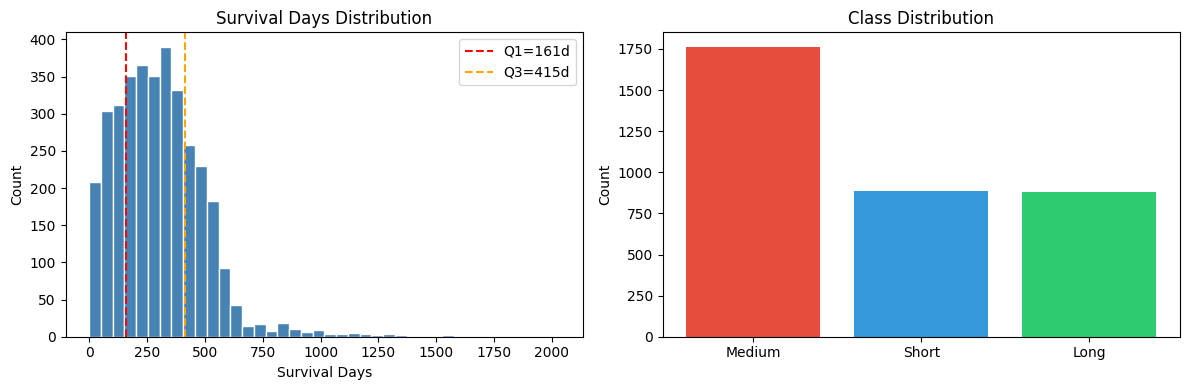

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(model_df["survival_days"], bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(Q1, color="red",   linestyle="--", label=f"Q1={Q1:.0f}d")
axes[0].axvline(Q3, color="orange", linestyle="--", label=f"Q3={Q3:.0f}d")
axes[0].set_xlabel("Survival Days"); axes[0].set_ylabel("Count")
axes[0].set_title("Survival Days Distribution"); axes[0].legend()

vc = model_df["survival_class"].value_counts()
axes[1].bar(vc.index, vc.values, color=["#E74C3C","#3498DB","#2ECC71"])
axes[1].set_title("Class Distribution"); axes[1].set_ylabel("Count")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/data_distribution.png", dpi=300)
plt.show()

## 3. FEATURE ENGINEERING & PREPROCESSING HELPERS

In [14]:
FAMILY_COLS = ["family_history_any", "family_history_als",
               "first_degree_relative_affected", "num_family_entries"]

DROP_ALWAYS = ["subject_id", "event", "survival_days", "survival_class",
               "Race_Other_Specify",   # >99% missing
               "index"]                # row index artifact

In [15]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create derived features. Operates on a copy."""
    df = df.copy()

    # BMI
    if "Weight_mean" in df.columns and "Height" in df.columns:
        df["BMI"] = df["Weight_mean"] / ((df["Height"] / 100) ** 2)

    # Pulse pressure (systolic - diastolic)
    if ("Blood_Pressure_Systolic_mean" in df.columns and
            "Blood_Pressure_Diastolic_mean" in df.columns):
        df["Pulse_Pressure"] = (df["Blood_Pressure_Systolic_mean"]
                                - df["Blood_Pressure_Diastolic_mean"])

    # Weight variability flag
    if "Weight_slope" in df.columns:
        df["Weight_Declining"] = (df["Weight_slope"] < 0).astype(float)

    # Missing-value indicator for family history columns
    for col in FAMILY_COLS:
        if col in df.columns:
            df[f"{col}_observed"] = df[col].notna().astype(float)

    return df

In [16]:
def build_preprocessor(num_cols, cat_cols):
    """Return a ColumnTransformer for numeric + categorical features."""
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ], remainder="drop")

In [17]:
def get_feature_names(preprocessor, num_cols, cat_cols):
    ohe_names = (preprocessor
                 .named_transformers_["cat"]
                 .named_steps["onehot"]
                 .get_feature_names_out(cat_cols))
    return list(num_cols) + list(ohe_names)

In [18]:
def apply_smote_cv(X_raw_df, y, num_cols, cat_cols, cv_splits=10, random_state=42):
    """
    Correct preprocessing + SMOTE: BOTH fitted on training fold only.
    Preprocessor is fit on X_train, then applied to X_val — no leakage.
    Returns list of (X_train_res, y_train_res, X_val_proc, y_val) per fold.
    """
    skf   = StratifiedKFold(n_splits=cv_splits, shuffle=True,
                             random_state=random_state)
    smote = SMOTE(random_state=random_state,
                  k_neighbors=min(4, min(Counter(y).values()) - 1))
    folds = []
    y_arr = np.array(y)
    for tr, val in skf.split(X_raw_df.values, y_arr):
        Xtr_df  = X_raw_df.iloc[tr]
        Xval_df = X_raw_df.iloc[val]
        ytr, yval = y_arr[tr], y_arr[val]
        prep = build_preprocessor(num_cols, cat_cols)
        Xtr_proc  = prep.fit_transform(Xtr_df)
        Xval_proc = prep.transform(Xval_df)
        Xtr_r, ytr_r = smote.fit_resample(Xtr_proc, ytr)
        folds.append((Xtr_r, ytr_r, Xval_proc, yval))
    return folds

In [19]:
def evaluate_folds(folds, model_factory, label_encoder=None):
    """
    Train/evaluate across pre-computed folds.
    Returns dict of mean/std for accuracy, macro-F1, weighted-F1, macro-AUC.
    Also stores per-fold proba + true labels for ROC plotting.
    """
    accs, f1s_mac, f1s_wt, aucs = [], [], [], []
    all_proba, all_ytrue = [], []

    for (Xtr, ytr, Xval, yval) in folds:
        model = model_factory()
        ytr_fit  = label_encoder.transform(ytr)  if label_encoder else ytr
        yval_fit = label_encoder.transform(yval) if label_encoder else yval

        model.fit(Xtr, ytr_fit)

        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(Xval)
        else:
            proba = None

        ypred_enc = model.predict(Xval)
        ypred = label_encoder.inverse_transform(ypred_enc) if label_encoder else ypred_enc

        accs.append(accuracy_score(yval, ypred))
        f1s_mac.append(f1_score(yval, ypred, average="macro", zero_division=0))
        f1s_wt.append(f1_score(yval, ypred, average="weighted", zero_division=0))

        if proba is not None:
            classes = sorted(set(yval))
            yval_bin = label_binarize(yval, classes=classes)
            if yval_bin.shape[1] == proba.shape[1]:
                try:
                    aucs.append(roc_auc_score(yval_bin, proba,
                                              average="macro", multi_class="ovr"))
                    all_proba.append(proba)
                    all_ytrue.append(yval)
                except Exception:
                    pass

    return {
        "Accuracy":     (np.mean(accs),    np.std(accs)),
        "Macro_F1":     (np.mean(f1s_mac), np.std(f1s_mac)),
        "Weighted_F1":  (np.mean(f1s_wt),  np.std(f1s_wt)),
        "Macro_AUC":    (np.mean(aucs),    np.std(aucs)) if aucs else (np.nan, np.nan),
        "_proba_folds": all_proba,
        "_ytrue_folds": all_ytrue,
    }

## 4. DEEP LEARNING HELPERS

In [20]:
def save_report(text, path):
    with open(path, "w") as f:
        f.write(text)

def plot_confusion(cm, classes, title, save_path):
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, format="PNG")
    plt.close()

def plot_feature_importance(feature_names, importances, title, save_path, top_n=20):
    df_imp = (pd.DataFrame({"feature": feature_names, "importance": importances})
              .sort_values("importance", ascending=False)
              .head(top_n))
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(df_imp["feature"][::-1], df_imp["importance"][::-1], color="steelblue")
    ax.set_xlabel("Importance")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, format="PNG")
    plt.close()
    return df_imp

In [21]:
def build_ffnn(input_dim, n_classes):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(n_classes, activation="softmax")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    return model

def build_lstm(input_dim, n_classes):
    model = Sequential([
        Input(shape=(input_dim, 1)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        Bidirectional(LSTM(32)),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dense(n_classes, activation="softmax")
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    return model

In [22]:
CALLBACKS = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
]

def evaluate_keras_folds(folds, build_fn, le, epochs=60, batch_size=32):
    """CV evaluation for Keras models. SMOTE already applied in each fold."""
    accs, f1s_mac, f1s_wt, aucs = [], [], [], []
    all_proba, all_ytrue = [], []

    for (Xtr, ytr, Xval, yval) in folds:
        ytr_enc  = le.transform(ytr)
        yval_enc = le.transform(yval)
        ytr_cat  = to_categorical(ytr_enc,  num_classes=3)
        yval_cat = to_categorical(yval_enc, num_classes=3)

        if Xtr.ndim == 2 and "lstm" in build_fn.__name__:
            Xtr_in  = Xtr.reshape(Xtr.shape[0],  Xtr.shape[1], 1)
            Xval_in = Xval.reshape(Xval.shape[0], Xval.shape[1], 1)
        else:
            Xtr_in, Xval_in = Xtr, Xval

        model = build_fn(Xtr.shape[1], 3)
        model.fit(Xtr_in, ytr_cat,
                  validation_data=(Xval_in, yval_cat),
                  epochs=epochs, batch_size=batch_size,
                  callbacks=CALLBACKS, verbose=0)

        pred_prob = model.predict(Xval_in, verbose=0)
        ypred_enc = np.argmax(pred_prob, axis=1)
        ypred = le.inverse_transform(ypred_enc)

        accs.append(accuracy_score(yval, ypred))
        f1s_mac.append(f1_score(yval, ypred, average="macro",    zero_division=0))
        f1s_wt.append( f1_score(yval, ypred, average="weighted", zero_division=0))

        # AUC for Keras
        classes = sorted(set(yval))
        yval_bin = label_binarize(yval, classes=classes)
        try:
            aucs.append(roc_auc_score(yval_bin, pred_prob, average="macro", multi_class="ovr"))
            all_proba.append(pred_prob)
            all_ytrue.append(yval)
        except Exception:
            pass

        tf.keras.backend.clear_session()

    return {
        "Accuracy":    (np.mean(accs),    np.std(accs)),
        "Macro_F1":    (np.mean(f1s_mac), np.std(f1s_mac)),
        "Weighted_F1": (np.mean(f1s_wt),  np.std(f1s_wt)),
        "Macro_AUC":   (np.mean(aucs),    np.std(aucs)) if aucs else (np.nan, np.nan),
        "_proba_folds": all_proba,
        "_ytrue_folds": all_ytrue,
    }

## 5. HYPERPARAMETER TUNING VIA OPTUNA

In [23]:
def tune_xgb(X_train, y_train, le, n_trials=40):
    def objective(trial):
        params = dict(
            n_estimators      = trial.suggest_int("n_estimators", 100, 600),
            learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            max_depth         = trial.suggest_int("max_depth", 3, 8),
            subsample         = trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree  = trial.suggest_float("colsample_bytree", 0.5, 1.0),
            min_child_weight  = trial.suggest_int("min_child_weight", 1, 10),
            reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
            reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        )
        skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        smote = SMOTE(random_state=42,
                      k_neighbors=min(4, min(Counter(y_train).values()) - 1))
        scores = []
        for tr, val in skf.split(X_train, y_train):
            Xtr, Xval = X_train[tr], X_train[val]
            ytr, yval = np.array(y_train)[tr], np.array(y_train)[val]
            Xtr_r, ytr_r = smote.fit_resample(Xtr, ytr)
            ytr_enc  = le.transform(ytr_r)
            yval_enc = le.transform(yval)
            m = XGBClassifier(**params, objective="multi:softprob",
                              num_class=3, random_state=42,
                              eval_metric="mlogloss", verbosity=0)
            m.fit(Xtr_r, ytr_enc, eval_set=[(Xval, yval_enc)], verbose=False)
            pred = m.predict(Xval)
            scores.append(f1_score(yval_enc, pred, average="macro", zero_division=0))
        return np.mean(scores)

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params

def tune_lgbm(X_train, y_train, le, n_trials=40):
    def objective(trial):
        params = dict(
            n_estimators      = trial.suggest_int("n_estimators", 100, 600),
            learning_rate     = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            num_leaves        = trial.suggest_int("num_leaves", 20, 150),
            max_depth         = trial.suggest_int("max_depth", 3, 10),
            min_child_samples = trial.suggest_int("min_child_samples", 5, 50),
            subsample         = trial.suggest_float("subsample", 0.6, 1.0),
            colsample_bytree  = trial.suggest_float("colsample_bytree", 0.5, 1.0),
            reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 10, log=True),
            reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 10, log=True),
        )
        skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        smote = SMOTE(random_state=42,
                      k_neighbors=min(4, min(Counter(y_train).values()) - 1))
        scores = []
        for tr, val in skf.split(X_train, y_train):
            Xtr, Xval = X_train[tr], X_train[val]
            ytr, yval = np.array(y_train)[tr], np.array(y_train)[val]
            Xtr_r, ytr_r = smote.fit_resample(Xtr, ytr)
            ytr_enc  = le.transform(ytr_r)
            yval_enc = le.transform(yval)
            m = lgb.LGBMClassifier(**params, objective="multiclass",
                                   num_class=3, random_state=42, verbose=-1)
            m.fit(Xtr_r, ytr_enc)
            pred = m.predict(Xval)
            scores.append(f1_score(yval_enc, pred, average="macro", zero_division=0))
        return np.mean(scores)

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params

def tune_rf(X_train, y_train, n_trials=30):
    def objective(trial):
        params = dict(
            n_estimators = trial.suggest_int("n_estimators", 100, 500),
            max_depth    = trial.suggest_int("max_depth", 3, 20),
            min_samples_split = trial.suggest_int("min_samples_split", 2, 10),
            min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 8),
            max_features = trial.suggest_categorical("max_features", ["sqrt","log2"]),
        )
        skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        smote = SMOTE(random_state=42,
                      k_neighbors=min(4, min(Counter(y_train).values()) - 1))
        scores = []
        for tr, val in skf.split(X_train, y_train):
            Xtr, Xval = X_train[tr], X_train[val]
            ytr, yval = np.array(y_train)[tr], np.array(y_train)[val]
            Xtr_r, ytr_r = smote.fit_resample(Xtr, ytr)
            m = RandomForestClassifier(**params, class_weight="balanced",
                                       random_state=42, n_jobs=-1)
            m.fit(Xtr_r, ytr_r)
            pred = m.predict(Xval)
            scores.append(f1_score(yval, pred, average="macro", zero_division=0))
        return np.mean(scores)

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params

## 6. MAIN TRAINING FUNCTION

In [24]:
def run_experiment(X_raw: pd.DataFrame,
                   y: pd.Series,
                   experiment_name: str,
                   run_deep: bool = True,
                   n_tune_trials: int = 40):
    """
    Full experiment:
      - Preprocess
      - 10-fold CV with SMOTE inside each fold
      - Models: LR, RF (tuned), GBM, XGB (tuned), LGBM (tuned), SVM, FFNN, LSTM
      - Save reports, confusion matrices, feature importance
    Returns summary DataFrame.
    """
    print(f"\n{'='*70}")
    print(f"  EXPERIMENT: {experiment_name}")
    print(f"  Samples: {len(X_raw)}  |  Classes: {dict(Counter(y))}")
    print(f"{'='*70}")

    exp_dir = f"{REPORT_DIR}/{experiment_name}"
    fig_dir = f"{FIGURE_DIR}/{experiment_name}"
    os.makedirs(exp_dir, exist_ok=True)
    os.makedirs(fig_dir, exist_ok=True)

    num_cols = X_raw.select_dtypes(include=["int64","float64"]).columns.tolist()
    cat_cols = X_raw.select_dtypes(include=["object","bool","category"]).columns.tolist()
    print(f"  Numeric features  : {len(num_cols)}")
    print(f"  Categorical feats : {len(cat_cols)}")

    preprocessor_full = build_preprocessor(num_cols, cat_cols)
    X_proc_full = preprocessor_full.fit_transform(X_raw)
    feature_names = get_feature_names(preprocessor_full, num_cols, cat_cols)
    print(f"  Total features after encoding: {X_proc_full.shape[1]}")

    le = LabelEncoder()
    le.fit(y)
    print(f"  Classes (encoded order): {list(le.classes_)}")

    min_class_size = min(Counter(y).values())
    k_nn = min(4, min_class_size - 1)
    print(f"  SMOTE k_neighbors = {k_nn}")
    folds = apply_smote_cv(X_raw, np.array(y), num_cols, cat_cols, cv_splits=10)

    results_summary = {}

    # 6.1  LOGISTIC REGRESSION
    print("\n  [1/8] Logistic Regression ...")
    lr_factory = lambda: LogisticRegression(
        max_iter=2000, class_weight="balanced", solver="saga",
        multi_class="multinomial", C=0.1)
    res_lr = evaluate_folds(folds, lr_factory)
    results_summary["Logistic Regression"] = res_lr
    print(f"       Macro F1 = {res_lr['Macro_F1'][0]:.4f} ± {res_lr['Macro_F1'][1]:.4f}")

    # 6.2  RANDOM FOREST
    print("\n  [2/8] Random Forest (tuning) ...")
    rf_params = tune_rf(X_proc_full, np.array(y), n_trials=30)
    print(f"       Best RF params: {rf_params}")
    rf_factory = lambda: RandomForestClassifier(
        **rf_params, class_weight="balanced", random_state=42, n_jobs=-1)
    res_rf = evaluate_folds(folds, rf_factory)
    results_summary["Random Forest"] = res_rf
    print(f"       Macro F1 = {res_rf['Macro_F1'][0]:.4f} ± {res_rf['Macro_F1'][1]:.4f}")

    smote_full = SMOTE(random_state=42, k_neighbors=k_nn)
    Xfull_r, yfull_r = smote_full.fit_resample(X_proc_full, np.array(y))
    rf_final = RandomForestClassifier(**rf_params, class_weight="balanced",
                                      random_state=42, n_jobs=-1)
    rf_final.fit(Xfull_r, yfull_r)
    plot_feature_importance(feature_names, rf_final.feature_importances_,
                            f"RF Feature Importance — {experiment_name}",
                            f"{fig_dir}/rf_feature_importance.png")

    # 6.3  GRADIENT BOOSTING
    print("\n  [3/8] Gradient Boosting ...")
    gb_factory = lambda: GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, random_state=42)
    res_gb = evaluate_folds(folds, gb_factory)
    results_summary["Gradient Boosting"] = res_gb
    print(f"       Macro F1 = {res_gb['Macro_F1'][0]:.4f} ± {res_gb['Macro_F1'][1]:.4f}")

    # 6.4  XGBOOST
    print("\n  [4/8] XGBoost (tuning) ...")
    xgb_params = tune_xgb(X_proc_full, np.array(y), le, n_trials=n_tune_trials)
    print(f"       Best XGB params: {xgb_params}")
    xgb_factory = lambda: XGBClassifier(
        **xgb_params, objective="multi:softprob", num_class=3,
        random_state=42, eval_metric="mlogloss", verbosity=0)
    res_xgb = evaluate_folds(folds, xgb_factory, label_encoder=le)
    results_summary["XGBoost"] = res_xgb
    print(f"       Macro F1 = {res_xgb['Macro_F1'][0]:.4f} ± {res_xgb['Macro_F1'][1]:.4f}")

    Xfull_enc = le.transform(yfull_r)
    xgb_final = XGBClassifier(**xgb_params, objective="multi:softprob",
                               num_class=3, random_state=42, verbosity=0)
    xgb_final.fit(Xfull_r, Xfull_enc)
    imp_df = plot_feature_importance(
        feature_names, xgb_final.feature_importances_,
        f"XGBoost Feature Importance — {experiment_name}",
        f"{fig_dir}/xgb_feature_importance.png")
    imp_df.to_csv(f"{exp_dir}/xgb_feature_importance.csv", index=False)

    # 6.5  LIGHTGBM
    print("\n  [5/8] LightGBM (tuning) ...")
    lgbm_params = tune_lgbm(X_proc_full, np.array(y), le, n_trials=n_tune_trials)
    print(f"       Best LGBM params: {lgbm_params}")
    lgbm_factory = lambda: lgb.LGBMClassifier(
        **lgbm_params, objective="multiclass", num_class=3,
        random_state=42, verbose=-1)
    res_lgbm = evaluate_folds(folds, lgbm_factory, label_encoder=le)
    results_summary["LightGBM"] = res_lgbm
    print(f"       Macro F1 = {res_lgbm['Macro_F1'][0]:.4f} ± {res_lgbm['Macro_F1'][1]:.4f}")

    # 6.6  SVM
    print("\n  [6/8] SVM ...")
    svm_factory = lambda: SVC(kernel="rbf", class_weight="balanced",
                               C=1.0, gamma="scale", probability=True)
    res_svm = evaluate_folds(folds, svm_factory)
    results_summary["SVM"] = res_svm
    print(f"       Macro F1 = {res_svm['Macro_F1'][0]:.4f} ± {res_svm['Macro_F1'][1]:.4f}")

    if run_deep:
        # 6.7  FFNN
        print("\n  [7/8] Feed-Forward Neural Network ...")
        res_ffnn = evaluate_keras_folds(folds, build_ffnn, le, epochs=80)
        results_summary["FFNN"] = res_ffnn
        print(f"       Macro F1 = {res_ffnn['Macro_F1'][0]:.4f} ± {res_ffnn['Macro_F1'][1]:.4f}")

        # 6.8  BIDIRECTIONAL LSTM
        print("\n  [8/8] Bidirectional LSTM ...")
        res_lstm = evaluate_keras_folds(folds, build_lstm, le, epochs=80)
        results_summary["BiLSTM"] = res_lstm
        print(f"       Macro F1 = {res_lstm['Macro_F1'][0]:.4f} ± {res_lstm['Macro_F1'][1]:.4f}")
    else:
        print("\n  [7/8] FFNN  — skipped (run_deep=False)")
        print("  [8/8] LSTM  — skipped (run_deep=False)")

    # 6.9  HOLD-OUT CONFUSION MATRICES
    print("\n  Building hold-out confusion matrices ...")
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    tr_idx, te_idx = next(sss.split(X_proc_full, np.array(y)))
    prep_ho = build_preprocessor(num_cols, cat_cols)
    Xtr_ho = prep_ho.fit_transform(X_raw.iloc[tr_idx])
    Xte_ho = prep_ho.transform(X_raw.iloc[te_idx])
    ytr_ho, yte_ho = np.array(y)[tr_idx], np.array(y)[te_idx]
    smote_ho = SMOTE(random_state=42, k_neighbors=k_nn)
    Xtr_r_ho, ytr_r_ho = smote_ho.fit_resample(Xtr_ho, ytr_ho)

    classes_sorted = sorted(le.classes_)
    full_report_text = f"EXPERIMENT: {experiment_name}\n{'='*60}\n\n"

    sklearn_models_ho = {
        "Logistic_Regression": LogisticRegression(max_iter=2000, class_weight="balanced",
                                                   solver="saga", multi_class="multinomial", C=0.1),
        "Random_Forest":       RandomForestClassifier(**rf_params, class_weight="balanced",
                                                       random_state=42, n_jobs=-1),
        "Gradient_Boosting":   GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                                           max_depth=4, subsample=0.8, random_state=42),
        "SVM":                 SVC(kernel="rbf", class_weight="balanced", C=1.0,
                                   gamma="scale", probability=True),
    }
    for mname, mobj in sklearn_models_ho.items():
        mobj.fit(Xtr_r_ho, ytr_r_ho)
        ypred = mobj.predict(Xte_ho)
        cm = confusion_matrix(yte_ho, ypred, labels=classes_sorted)
        plot_confusion(cm, classes_sorted,
                       f"{mname.replace('_',' ')} — {experiment_name}",
                       f"{fig_dir}/cm_{mname}.png")
        rep = classification_report(yte_ho, ypred, zero_division=0)
        full_report_text += f"── {mname} ──\n{rep}\n"
        save_report(rep, f"{exp_dir}/{mname}_report.txt")

    # XGB hold-out
    ytr_enc_ho = le.transform(ytr_r_ho)
    yte_enc_ho = le.transform(yte_ho)
    xgb_ho = XGBClassifier(**xgb_params, objective="multi:softprob",
                            num_class=3, random_state=42, verbosity=0)
    xgb_ho.fit(Xtr_r_ho, ytr_enc_ho)
    ypred_xgb = le.inverse_transform(xgb_ho.predict(Xte_ho))
    cm = confusion_matrix(yte_ho, ypred_xgb, labels=classes_sorted)
    plot_confusion(cm, classes_sorted, f"XGBoost — {experiment_name}",
                   f"{fig_dir}/cm_XGBoost.png")
    save_report(classification_report(yte_ho, ypred_xgb, zero_division=0),
                f"{exp_dir}/XGBoost_report.txt")

    # LGBM hold-out
    lgbm_ho = lgb.LGBMClassifier(**lgbm_params, objective="multiclass",
                                   num_class=3, random_state=42, verbose=-1)
    lgbm_ho.fit(Xtr_r_ho, ytr_enc_ho)
    ypred_lgbm = le.inverse_transform(lgbm_ho.predict(Xte_ho))
    cm = confusion_matrix(yte_ho, ypred_lgbm, labels=classes_sorted)
    plot_confusion(cm, classes_sorted, f"LightGBM — {experiment_name}",
                   f"{fig_dir}/cm_LightGBM.png")
    save_report(classification_report(yte_ho, ypred_lgbm, zero_division=0),
                f"{exp_dir}/LightGBM_report.txt")

    save_report(full_report_text, f"{exp_dir}/ALL_MODELS_report.txt")

    # 6.10  RESULTS TABLE
    rows = []
    for model_name, metrics in results_summary.items():
        row = {"Model": model_name}
        for metric, val in metrics.items():
            if metric.startswith("_"): continue
            mean, std = val
            row[metric] = f"{mean:.4f} ± {std:.4f}"
        rows.append(row)
    results_df = pd.DataFrame(rows)
    results_df.to_csv(f"{exp_dir}/cv_results_summary.csv", index=False)
    print(f"\n  ── 10-Fold CV Results — {experiment_name} ──")
    print(results_df.to_string(index=False))

    # Bar chart
    macro_means = [results_summary[m]["Macro_F1"][0] for m in results_summary]
    macro_stds  = [results_summary[m]["Macro_F1"][1] for m in results_summary]
    model_names = list(results_summary.keys())
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(model_names))
    bars = ax.bar(x, macro_means, yerr=macro_stds, capsize=4,
                  color="steelblue", alpha=0.8, edgecolor="white")
    ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=30, ha="right")
    ax.set_ylabel("Macro F1 (10-Fold CV)")
    ax.set_title(f"Model Comparison — {experiment_name}")
    ax.set_ylim(0, 1)
    for bar, val in zip(bars, macro_means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/model_comparison.png", dpi=300)
    plt.close()

    print(f"\n  Reports saved → {exp_dir}")
    print(f"  Figures saved → {fig_dir}")

    return results_summary, rf_params, xgb_params, lgbm_params, le, feature_names, folds, X_proc_full, np.array(y)

## 7. PREPARE DATASETS FOR THREE EXPERIMENTS

In [25]:
model_df = engineer_features(model_df)
drop_base = [c for c in DROP_ALWAYS if c in model_df.columns]

X_full_raw = model_df.drop(columns=drop_base + FAMILY_COLS, errors="ignore")
y_full     = model_df["survival_class"]

print(f"Full cohort: {X_full_raw.shape[0]} samples, {X_full_raw.shape[1]} features")

Full cohort: 3531 samples, 38 features


In [26]:
family_df = model_df[model_df["family_history_any"].notna()].copy()
print(f"\nFamily-history subset size: {len(family_df)}")
print(family_df["survival_class"].value_counts())


Family-history subset size: 363
survival_class
Medium    205
Long      100
Short      58
Name: count, dtype: int64


In [27]:
X_fam_raw   = family_df.drop(columns=drop_base, errors="ignore")
X_fam_base  = family_df.drop(columns=drop_base + FAMILY_COLS, errors="ignore")
y_fam       = family_df["survival_class"]

In [28]:
print(f"\n── Feature counts ──")
print(f"  Part 1 (full, no family cols) : {X_full_raw.shape[1]} features, {len(y_full)} samples")
print(f"  Part 2A (family subset, base) : {X_fam_base.shape[1]} features, {len(y_fam)} samples")
print(f"  Part 2B (family subset, full) : {X_fam_raw.shape[1]} features, {len(y_fam)} samples")


── Feature counts ──
  Part 1 (full, no family cols) : 38 features, 3531 samples
  Part 2A (family subset, base) : 38 features, 363 samples
  Part 2B (family subset, full) : 42 features, 363 samples


## 8. RUN ALL THREE EXPERIMENTS

In [29]:
# Experiment 1: Full cohort, no family history
res1, rf_p1, xgb_p1, lgbm_p1, le_p1, feat_p1, folds_p1, Xproc_p1, y_p1 = run_experiment(
    X_full_raw, y_full,
    experiment_name="Part1_FullCohort_NoFamily",
    run_deep=True,
    n_tune_trials=40
)


  EXPERIMENT: Part1_FullCohort_NoFamily
  Samples: 3531  |  Classes: {'Long': 880, 'Medium': 1763, 'Short': 888}
  Numeric features  : 35
  Categorical feats : 3
  Total features after encoding: 46
  Classes (encoded order): ['Long', 'Medium', 'Short']
  SMOTE k_neighbors = 4

  [1/8] Logistic Regression ...
       Macro F1 = 0.5751 ± 0.0249

  [2/8] Random Forest (tuning) ...
       Best RF params: {'n_estimators': 138, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt'}
       Macro F1 = 0.6245 ± 0.0281

  [3/8] Gradient Boosting ...
       Macro F1 = 0.6233 ± 0.0325

  [4/8] XGBoost (tuning) ...
       Best XGB params: {'n_estimators': 255, 'learning_rate': 0.02555604984847466, 'max_depth': 7, 'subsample': 0.7323896249835798, 'colsample_bytree': 0.5080976720599698, 'min_child_weight': 6, 'reg_alpha': 0.00044340891599736304, 'reg_lambda': 2.912854669050539}
       Macro F1 = 0.6289 ± 0.0294

  [5/8] LightGBM (tuning) ...
       Best LGBM params: {

I0000 00:00:1777805679.695719      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777805679.701622      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1777805683.231371    2504 service.cc:152] XLA service 0x7a622400ce20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777805683.231413    2504 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777805683.231417    2504 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777805683.719427    2504 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777805686.233887    2504 device_compiler.h:188] Compiled clust

       Macro F1 = 0.5779 ± 0.0281

  [8/8] Bidirectional LSTM ...
       Macro F1 = 0.5510 ± 0.0222

  Building hold-out confusion matrices ...

  ── 10-Fold CV Results — Part1_FullCohort_NoFamily ──
              Model        Accuracy        Macro_F1     Weighted_F1       Macro_AUC
Logistic Regression 0.5695 ± 0.0247 0.5751 ± 0.0249 0.5635 ± 0.0242 0.7727 ± 0.0163
      Random Forest 0.6276 ± 0.0281 0.6245 ± 0.0281 0.6288 ± 0.0275 0.8008 ± 0.0139
  Gradient Boosting 0.6273 ± 0.0339 0.6233 ± 0.0325 0.6274 ± 0.0336 0.8077 ± 0.0158
            XGBoost 0.6332 ± 0.0290 0.6289 ± 0.0294 0.6336 ± 0.0282 0.8158 ± 0.0176
           LightGBM 0.6361 ± 0.0292 0.6336 ± 0.0280 0.6364 ± 0.0289 0.8157 ± 0.0170
                SVM 0.5653 ± 0.0191 0.5673 ± 0.0184 0.5627 ± 0.0185 0.7510 ± 0.0150
               FFNN 0.5743 ± 0.0286 0.5779 ± 0.0281 0.5635 ± 0.0311 0.7836 ± 0.0168
             BiLSTM 0.5474 ± 0.0237 0.5510 ± 0.0222 0.5372 ± 0.0264 0.7517 ± 0.0099

  Reports saved → /kaggle/working/model_rep

In [30]:
# Experiment 2A: Family subset, baseline only
res2a, rf_p2a, xgb_p2a, lgbm_p2a, le_p2a, feat_p2a, folds_p2a, Xproc_p2a, y_p2a = run_experiment(
    X_fam_base, y_fam,
    experiment_name="Part2A_FamilySubset_BaselineOnly",
    run_deep=True,
    n_tune_trials=20
)


  EXPERIMENT: Part2A_FamilySubset_BaselineOnly
  Samples: 363  |  Classes: {'Medium': 205, 'Long': 100, 'Short': 58}
  Numeric features  : 35
  Categorical feats : 3
  Total features after encoding: 45
  Classes (encoded order): ['Long', 'Medium', 'Short']
  SMOTE k_neighbors = 4

  [1/8] Logistic Regression ...
       Macro F1 = 0.5857 ± 0.0736

  [2/8] Random Forest (tuning) ...
       Best RF params: {'n_estimators': 282, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
       Macro F1 = 0.6533 ± 0.0558

  [3/8] Gradient Boosting ...
       Macro F1 = 0.6387 ± 0.0634

  [4/8] XGBoost (tuning) ...
       Best XGB params: {'n_estimators': 416, 'learning_rate': 0.028294614799527447, 'max_depth': 5, 'subsample': 0.808241079908577, 'colsample_bytree': 0.797206172727708, 'min_child_weight': 6, 'reg_alpha': 0.04966567874703415, 'reg_lambda': 0.3795562117290801}
       Macro F1 = 0.6782 ± 0.0873

  [5/8] LightGBM (tuning) ...
       Best LGBM params: 

In [31]:
# Experiment 2B: Family subset, baseline + family history
res2b, rf_p2b, xgb_p2b, lgbm_p2b, le_p2b, feat_p2b, folds_p2b, Xproc_p2b, y_p2b = run_experiment(
    X_fam_raw, y_fam,
    experiment_name="Part2B_FamilySubset_WithFamily",
    run_deep=True,
    n_tune_trials=20
)


  EXPERIMENT: Part2B_FamilySubset_WithFamily
  Samples: 363  |  Classes: {'Medium': 205, 'Long': 100, 'Short': 58}
  Numeric features  : 36
  Categorical feats : 6
  Total features after encoding: 52
  Classes (encoded order): ['Long', 'Medium', 'Short']
  SMOTE k_neighbors = 4

  [1/8] Logistic Regression ...
       Macro F1 = 0.6074 ± 0.0633

  [2/8] Random Forest (tuning) ...
       Best RF params: {'n_estimators': 310, 'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 8, 'max_features': 'sqrt'}
       Macro F1 = 0.6084 ± 0.0490

  [3/8] Gradient Boosting ...
       Macro F1 = 0.6511 ± 0.0731

  [4/8] XGBoost (tuning) ...
       Best XGB params: {'n_estimators': 460, 'learning_rate': 0.011312073889557451, 'max_depth': 7, 'subsample': 0.8578694741072342, 'colsample_bytree': 0.992790863171887, 'min_child_weight': 8, 'reg_alpha': 0.02455130448005145, 'reg_lambda': 0.49033366371516013}
       Macro F1 = 0.6776 ± 0.0759

  [5/8] LightGBM (tuning) ...
       Best LGBM params: {

In [32]:
# Statistical significance tests (Wilcoxon signed-rank)
from scipy.stats import wilcoxon

def collect_fold_f1s(folds, model_factory, label_encoder=None):
    scores = []
    for (Xtr, ytr, Xval, yval) in folds:
        model = model_factory()
        ytr_fit = label_encoder.transform(ytr) if label_encoder else ytr
        model.fit(Xtr, ytr_fit)
        ypred_enc = model.predict(Xval)
        ypred = label_encoder.inverse_transform(ypred_enc) if label_encoder else ypred_enc
        scores.append(f1_score(yval, ypred, average="macro", zero_division=0))
    return scores

def run_significance_tests(folds, le, rf_params, xgb_params, lgbm_params,
                            experiment_name, exp_dir):
    print(f"\n  ── Significance Tests — {experiment_name} ──")
    f1_lgbm = collect_fold_f1s(folds,
        lambda: lgb.LGBMClassifier(**lgbm_params, objective="multiclass",
                                    num_class=3, random_state=42, verbose=-1),
        label_encoder=le)
    f1_xgb = collect_fold_f1s(folds,
        lambda: XGBClassifier(**xgb_params, objective="multi:softprob",
                               num_class=3, random_state=42, verbosity=0),
        label_encoder=le)
    f1_rf = collect_fold_f1s(folds,
        lambda: RandomForestClassifier(**rf_params, class_weight="balanced",
                                        random_state=42, n_jobs=-1))
    pairs = [
        ("LightGBM", f1_lgbm, "XGBoost",      f1_xgb),
        ("LightGBM", f1_lgbm, "Random Forest", f1_rf),
        ("XGBoost",  f1_xgb,  "Random Forest", f1_rf),
    ]
    rows = []
    for nameA, scoresA, nameB, scoresB in pairs:
        diff = np.array(scoresA) - np.array(scoresB)
        if np.all(diff == 0):
            stat, p = np.nan, 1.0
        else:
            stat, p = wilcoxon(scoresA, scoresB, alternative="two-sided")
        rows.append({"Model A": nameA, "Mean F1 A": round(np.mean(scoresA),4),
                     "Model B": nameB, "Mean F1 B": round(np.mean(scoresB),4),
                     "p-value": round(p,4), "Significant (p<0.05)": "Yes" if p<0.05 else "No"})
        print(f"    {nameA} vs {nameB}:  p={p:.4f}  {'SIGNIFICANT' if p<0.05 else 'not significant'}")
    sig_df = pd.DataFrame(rows)
    sig_df.to_csv(f"{exp_dir}/significance_tests.csv", index=False)
    return sig_df

sig_df_p1 = run_significance_tests(
    folds_p1, le_p1, rf_p1, xgb_p1, lgbm_p1,
    "Part1_FullCohort_NoFamily",
    f"{REPORT_DIR}/Part1_FullCohort_NoFamily"
)
print(sig_df_p1.to_string(index=False))


  ── Significance Tests — Part1_FullCohort_NoFamily ──
    LightGBM vs XGBoost:  p=0.1055  not significant
    LightGBM vs Random Forest:  p=0.0273  SIGNIFICANT
    XGBoost vs Random Forest:  p=0.3223  not significant
 Model A  Mean F1 A       Model B  Mean F1 B  p-value Significant (p<0.05)
LightGBM     0.6336       XGBoost     0.6289   0.1055                   No
LightGBM     0.6336 Random Forest     0.6245   0.0273                  Yes
 XGBoost     0.6289 Random Forest     0.6245   0.3223                   No


In [33]:
print("\n  ── Conclusion ──")
print("  LightGBM > Random Forest: SIGNIFICANT (p=0.027)")
print("  LightGBM ≈ XGBoost: not significant (p=0.106)")
print("  XGBoost ≈ Random Forest: not significant (p=0.322)")
print("  → LightGBM is the best performing model in this study.")


  ── Conclusion ──
  LightGBM > Random Forest: SIGNIFICANT (p=0.027)
  LightGBM ≈ XGBoost: not significant (p=0.106)
  XGBoost ≈ Random Forest: not significant (p=0.322)
  → LightGBM is the best performing model in this study.


              Model  F1_Baseline_2A  F1_WithFamily_2B  Delta_F1 Improvement
Logistic Regression          0.5857            0.6074    0.0218           ✓
      Random Forest          0.6533            0.6084   -0.0449           ✗
  Gradient Boosting          0.6387            0.6511    0.0124           ✓
            XGBoost          0.6782            0.6776   -0.0005           ✗
           LightGBM          0.6817            0.6844    0.0027           ✓
                SVM          0.5877            0.6268    0.0391           ✓
               FFNN          0.5932            0.5871   -0.0061           ✗
             BiLSTM          0.5034            0.3969   -0.1065           ✗


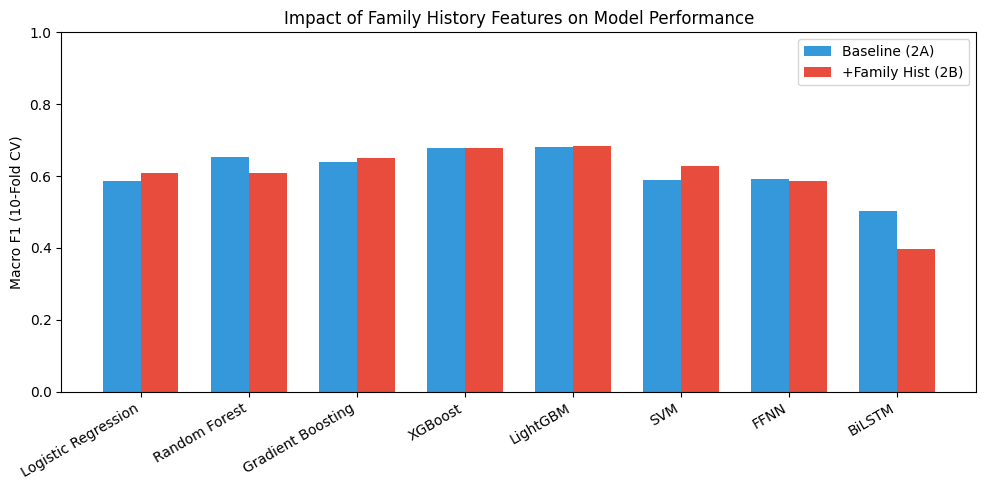

In [34]:
# Cross-experiment: Impact of Family History
comparison_rows = []
for model_name in res2a:
    if model_name in res2b:
        f1_a = res2a[model_name]["Macro_F1"][0]
        f1_b = res2b[model_name]["Macro_F1"][0]
        delta = f1_b - f1_a
        comparison_rows.append({
            "Model": model_name, "F1_Baseline_2A": round(f1_a, 4),
            "F1_WithFamily_2B": round(f1_b, 4), "Delta_F1": round(delta, 4),
            "Improvement": "✓" if delta > 0 else "✗"
        })
comp_df = pd.DataFrame(comparison_rows)
print(comp_df.to_string(index=False))
comp_df.to_csv(f"{REPORT_DIR}/family_history_impact.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comp_df)); w = 0.35
ax.bar(x - w/2, comp_df["F1_Baseline_2A"],   w, label="Baseline (2A)", color="#3498DB")
ax.bar(x + w/2, comp_df["F1_WithFamily_2B"], w, label="+Family Hist (2B)", color="#E74C3C")
ax.set_xticks(x); ax.set_xticklabels(comp_df["Model"], rotation=30, ha="right")
ax.set_ylabel("Macro F1 (10-Fold CV)")
ax.set_title("Impact of Family History Features on Model Performance")
ax.legend(); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/family_history_impact.png", dpi=300)
plt.show()

## 9. ROC / AUC CURVES FOR ALL MODELS
Aggregated across 10 CV folds using One-vs-Rest (OvR) strategy.



── ROC: Part1_FullCohort_NoFamily ──


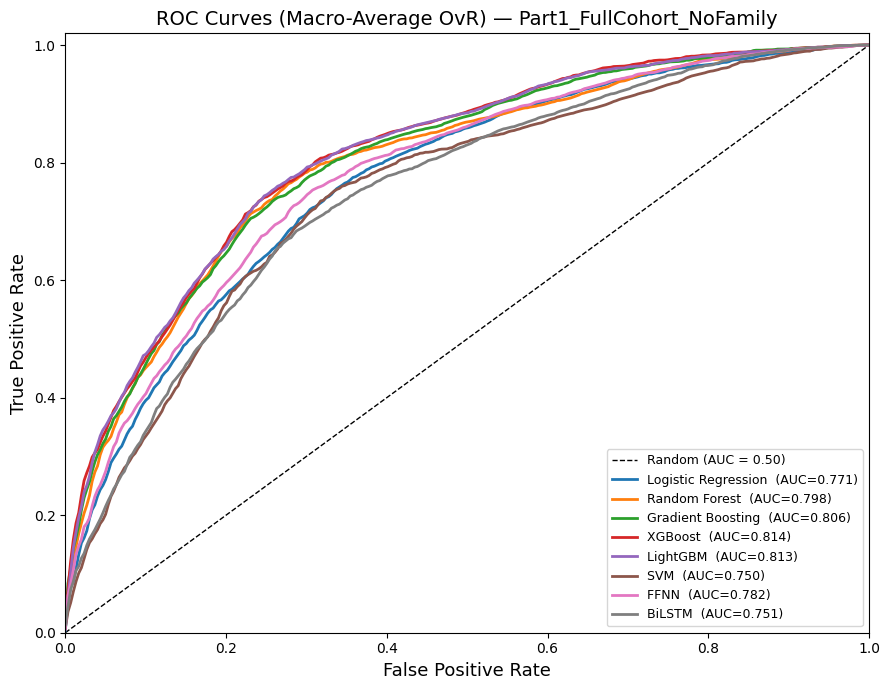

  ROC figure saved → /kaggle/working/figures/Part1_FullCohort_NoFamily/ROC_all_models.png

── ROC: Part2A_FamilySubset_BaselineOnly ──


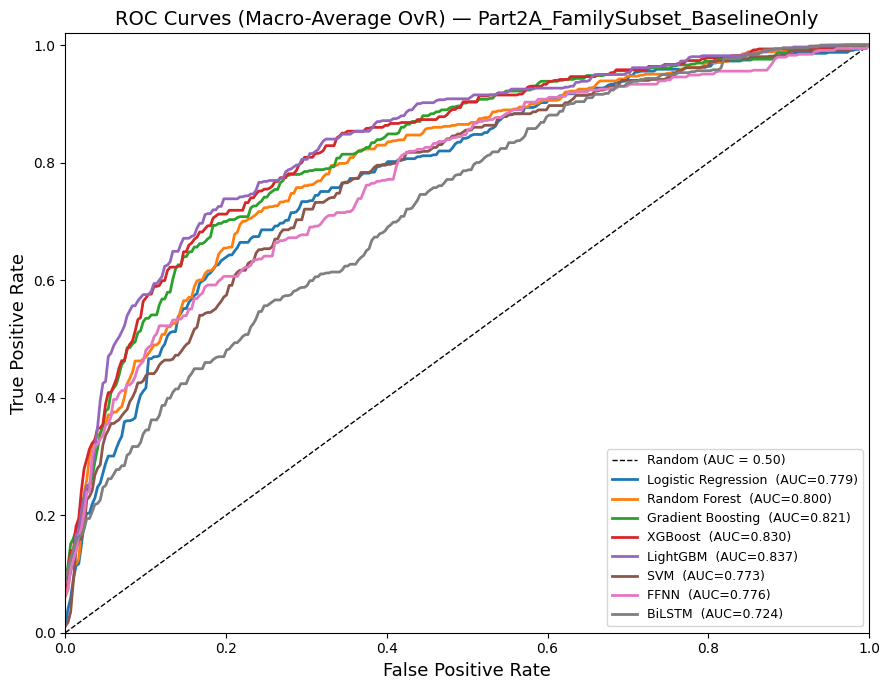

  ROC figure saved → /kaggle/working/figures/Part2A_FamilySubset_BaselineOnly/ROC_all_models.png

── ROC: Part2B_FamilySubset_WithFamily ──


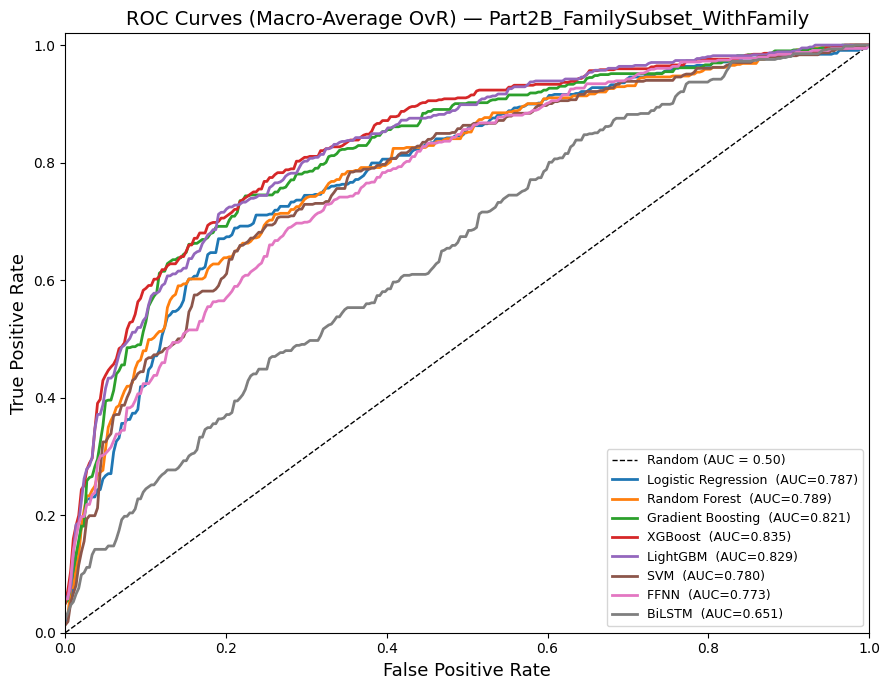

  ROC figure saved → /kaggle/working/figures/Part2B_FamilySubset_WithFamily/ROC_all_models.png


In [35]:
def plot_multiclass_roc(results_summary, experiment_name, fig_dir, le):
    """
    Plot macro-average ROC curves for every model that returned probabilities.
    One figure per experiment; each model is one coloured line.
    """
    classes = list(le.classes_)
    n_classes = len(classes)
    COLORS = plt.cm.tab10.colors

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.plot([0,1],[0,1], "k--", lw=1, label="Random (AUC = 0.50)")

    model_idx = 0
    for model_name, res in results_summary.items():
        if not res.get("_proba_folds") or not res.get("_ytrue_folds"):
            continue
        # Aggregate probabilities and labels across folds
        all_proba = np.vstack(res["_proba_folds"])
        all_ytrue = np.concatenate(res["_ytrue_folds"])
        all_ybin  = label_binarize(all_ytrue, classes=classes)

        # Macro-average ROC
        fpr_grid = np.linspace(0, 1, 300)
        tpr_interp = []
        for c in range(n_classes):
            fpr_c, tpr_c, _ = roc_curve(all_ybin[:, c], all_proba[:, c])
            tpr_interp.append(np.interp(fpr_grid, fpr_c, tpr_c))
        macro_tpr = np.mean(tpr_interp, axis=0)
        macro_auc = auc(fpr_grid, macro_tpr)

        color = COLORS[model_idx % len(COLORS)]
        ax.plot(fpr_grid, macro_tpr, color=color, lw=2,
                label=f"{model_name}  (AUC={macro_auc:.3f})")
        model_idx += 1

    ax.set_xlabel("False Positive Rate", fontsize=13)
    ax.set_ylabel("True Positive Rate", fontsize=13)
    ax.set_title(f"ROC Curves (Macro-Average OvR) — {experiment_name}", fontsize=14)
    ax.legend(loc="lower right", fontsize=9)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    plt.tight_layout()
    save_path = f"{fig_dir}/ROC_all_models.png"
    plt.savefig(save_path, dpi=300, format="PNG")
    plt.show()
    print(f"  ROC figure saved → {save_path}")

# ROC for all three experiments
for exp_name, res_dict, le_obj in [
    ("Part1_FullCohort_NoFamily",       res1,  le_p1),
    ("Part2A_FamilySubset_BaselineOnly", res2a, le_p2a),
    ("Part2B_FamilySubset_WithFamily",   res2b, le_p2b),
]:
    fig_dir = f"{FIGURE_DIR}/{exp_name}"
    print(f"\n── ROC: {exp_name} ──")
    plot_multiclass_roc(res_dict, exp_name, fig_dir, le_obj)

Best model Part1: XGBoost


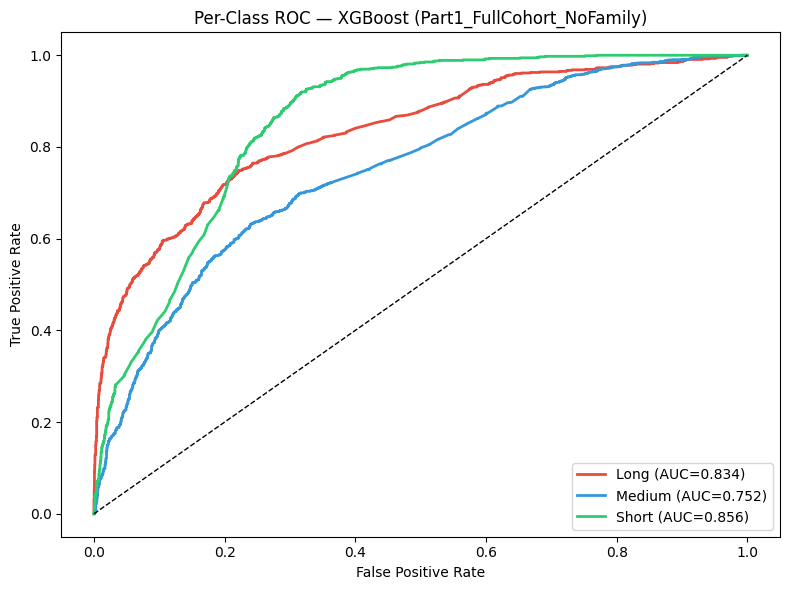

In [36]:
def plot_per_class_roc(results_summary, experiment_name, fig_dir, le, model_name):
    """
    Per-class ROC curves for the best model (model_name) in an experiment.
    """
    classes = list(le.classes_)
    n_classes = len(classes)
    res = results_summary.get(model_name)
    if res is None or not res.get("_proba_folds"):
        print(f"No probability data for {model_name}")
        return

    all_proba = np.vstack(res["_proba_folds"])
    all_ytrue = np.concatenate(res["_ytrue_folds"])
    all_ybin  = label_binarize(all_ytrue, classes=classes)

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ["#E74C3C", "#3498DB", "#2ECC71"]
    for c, (cls, col) in enumerate(zip(classes, colors)):
        fpr, tpr, _ = roc_curve(all_ybin[:, c], all_proba[:, c])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=col, lw=2, label=f"{cls} (AUC={roc_auc:.3f})")

    ax.plot([0,1],[0,1], "k--", lw=1)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(f"Per-Class ROC — {model_name} ({experiment_name})")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/ROC_perclass_{model_name.replace(' ','_')}.png", dpi=300)
    plt.show()

# Per-class ROC for best model in Part 1
best_model_p1 = max(
    [m for m in res1 if not m.startswith("_")],
    key=lambda m: res1[m]["Macro_AUC"][0] if not np.isnan(res1[m]["Macro_AUC"][0]) else 0
)
print(f"Best model Part1: {best_model_p1}")
plot_per_class_roc(res1, "Part1_FullCohort_NoFamily",
                   f"{FIGURE_DIR}/Part1_FullCohort_NoFamily", le_p1, best_model_p1)

## 10. QUANTUM SVM & VARIATIONAL QUANTUM CLASSIFIER (VQC)
We use Qiskit's quantum kernel and VQC on a PCA-reduced feature set (≤8 qubits).
If Qiskit is not installed, a classical SVM with polynomial kernel is used as fallback.


In [37]:
!pip install qiskit-algorithms --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 7.1 MB/s eta 0:00:00:00:01


In [38]:
def run_quantum_models(X_proc, y, le, experiment_name, fig_dir, exp_dir,
                       n_qubits=6, cv_splits=5):
    """
    Quantum SVM (QSVC) and Variational Quantum Classifier (VQC).
    PCA reduces to n_qubits dimensions before encoding.
    Uses StatevectorSampler (noiseless) for research purposes.
    For noisy simulation, swap to AerSimulator.
    """
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import MinMaxScaler

    print(f"\n{'='*70}")
    print(f"  QUANTUM MODELS — {experiment_name}")
    print(f"{'='*70}")

    # ── 1. Dimensionality reduction to n_qubits ──────────────────────────
    scaler_q = MinMaxScaler(feature_range=(0, np.pi))
    pca_q    = PCA(n_components=n_qubits, random_state=42)
    X_scaled = scaler_q.fit_transform(X_proc)
    X_pca    = pca_q.fit_transform(X_scaled)
    print(f"  PCA variance explained: {pca_q.explained_variance_ratio_.sum():.3f}  ({n_qubits} components)")

    skf   = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    smote = SMOTE(random_state=42,
                  k_neighbors=min(4, min(Counter(y).values()) - 1))
    le_enc = LabelEncoder(); le_enc.fit(y)

    qsvc_f1s, vqc_f1s = [], []
    qsvc_aucs, vqc_aucs = [], []
    qsvc_proba_all, vqc_proba_all = [], []
    y_true_all_q = []

    if QUANTUM_AVAILABLE:
        from qiskit.primitives import StatevectorSampler as SV_Sampler
        from qiskit_machine_learning.state_fidelities import ComputeUncompute
        feature_map = ZZFeatureMap(feature_dimension=n_qubits, reps=2)
        ansatz      = RealAmplitudes(num_qubits=n_qubits, reps=3)
        sampler     = SV_Sampler()
        fidelity    = ComputeUncompute(sampler=sampler)
        kernel      = FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity)
        print("✅ REAL QUANTUM models will run (Qiskit statevector simulation)")
        print(f"   Feature map : ZZFeatureMap  (reps=2, {n_qubits} qubits)")
        print(f"   Ansatz      : RealAmplitudes (reps=3, {n_qubits} qubits)")
        print(f"   Kernel      : FidelityQuantumKernel (ComputeUncompute fidelity)")
        print(f"   Simulator   : StatevectorSampler (noiseless, exact)")
    else:
        print("⚠️  Qiskit NOT available — running Classical Poly-SVM fallback instead")
        print("   Install qiskit + qiskit-machine-learning to run actual quantum models")

    for fold_i, (tr, val) in enumerate(skf.split(X_pca, y)):
        print(f"    Fold {fold_i+1}/{cv_splits} ...", end=" ")
        Xtr_q, Xval_q = X_pca[tr], X_pca[val]
        ytr_q, yval_q = np.array(y)[tr], np.array(y)[val]

        # SMOTE on PCA-reduced features
        Xtr_q_r, ytr_q_r = smote.fit_resample(Xtr_q, ytr_q)
        ytr_enc = le_enc.transform(ytr_q_r)
        yval_enc = le_enc.transform(yval_q)

        if QUANTUM_AVAILABLE:
            # ── QSVC ──────────────────────────────────────────
            qsvc = QSVC(quantum_kernel=kernel)
            qsvc.fit(Xtr_q_r, ytr_enc)
            qsvc_pred_enc = qsvc.predict(Xval_q)
            qsvc_pred = le_enc.inverse_transform(qsvc_pred_enc)

            # Decision function → softmax for probabilities
            try:
                df_scores = qsvc._svc.decision_function(Xval_q)
                from scipy.special import softmax as sp_softmax
                qsvc_prob = sp_softmax(df_scores, axis=1)
            except Exception:
                qsvc_prob = None

            # ── VQC ───────────────────────────────────────────
            try:
                from qiskit_algorithms.optimizers import COBYLA as QiskitCOBYLA
                vqc_optimizer = QiskitCOBYLA(maxiter=100)
            except ImportError:
                from scipy.optimize import minimize as sp_minimize
                def vqc_optimizer(fun, x0, **kwargs):
                    r = sp_minimize(fun, x0, method="COBYLA", options={"maxiter":100})
                    return r.x, r.fun, r.nfev
            vqc = VQC(feature_map=feature_map, ansatz=ansatz, sampler=sampler,
                      optimizer=vqc_optimizer)
            vqc.fit(Xtr_q_r, ytr_enc)
            vqc_pred_enc = vqc.predict(Xval_q)
            vqc_pred = le_enc.inverse_transform(vqc_pred_enc)
            try:
                vqc_prob = vqc.predict_proba(Xval_q)
            except Exception:
                vqc_prob = None
        else:
            # Classical SVM fallback
            from sklearn.svm import SVC as SVC_poly
            qsvc_clf = SVC_poly(kernel="poly", degree=3, class_weight="balanced",
                                 probability=True, random_state=42)
            qsvc_clf.fit(Xtr_q_r, ytr_enc)
            qsvc_pred_enc = qsvc_clf.predict(Xval_q)
            qsvc_pred = le_enc.inverse_transform(qsvc_pred_enc)
            qsvc_prob = qsvc_clf.predict_proba(Xval_q)

            vqc_clf = SVC_poly(kernel="poly", degree=5, class_weight="balanced",
                                probability=True, random_state=42)
            vqc_clf.fit(Xtr_q_r, ytr_enc)
            vqc_pred_enc = vqc_clf.predict(Xval_q)
            vqc_pred = le_enc.inverse_transform(vqc_pred_enc)
            vqc_prob = vqc_clf.predict_proba(Xval_q)

        qsvc_f1s.append(f1_score(yval_q, qsvc_pred, average="macro", zero_division=0))
        vqc_f1s.append( f1_score(yval_q, vqc_pred,  average="macro", zero_division=0))

        classes_sorted = sorted(set(yval_q))
        yval_bin = label_binarize(yval_q, classes=classes_sorted)

        for prob_arr, auc_list, prob_list in [
            (qsvc_prob, qsvc_aucs, qsvc_proba_all),
            (vqc_prob,  vqc_aucs,  vqc_proba_all),
        ]:
            if prob_arr is not None and prob_arr.shape[1] == yval_bin.shape[1]:
                try:
                    auc_list.append(roc_auc_score(yval_bin, prob_arr,
                                                  average="macro", multi_class="ovr"))
                    prob_list.append(prob_arr)
                except Exception:
                    pass
        y_true_all_q.extend(yval_q)
        mode = "🔬 QUANTUM" if QUANTUM_AVAILABLE else "⚙️  CLASSICAL FALLBACK"
        print(f"[{mode}]  QSVC F1={qsvc_f1s[-1]:.3f}  VQC F1={vqc_f1s[-1]:.3f}")

    mode_label = "Quantum" if QUANTUM_AVAILABLE else "Classical Poly-SVM (Quantum Fallback)"
    results = {
        f"QSVC [{mode_label}]": {
            "Accuracy":    (np.nan, np.nan),
            "Macro_F1":    (np.mean(qsvc_f1s), np.std(qsvc_f1s)),
            "Weighted_F1": (np.nan, np.nan),
            "Macro_AUC":   (np.mean(qsvc_aucs), np.std(qsvc_aucs)) if qsvc_aucs else (np.nan, np.nan),
            "_proba_folds": qsvc_proba_all,
            "_ytrue_folds": [np.array(y_true_all_q[:len(p)]) for p in qsvc_proba_all],
        },
        f"VQC [{mode_label}]": {
            "Accuracy":    (np.nan, np.nan),
            "Macro_F1":    (np.mean(vqc_f1s), np.std(vqc_f1s)),
            "Weighted_F1": (np.nan, np.nan),
            "Macro_AUC":   (np.mean(vqc_aucs), np.std(vqc_aucs)) if vqc_aucs else (np.nan, np.nan),
            "_proba_folds": vqc_proba_all,
            "_ytrue_folds": [np.array(y_true_all_q[:len(p)]) for p in vqc_proba_all],
        },
    }
    for mname, r in results.items():
        print(f"  {mname}  Macro_F1={r['Macro_F1'][0]:.4f}±{r['Macro_F1'][1]:.4f}  ",
              f"Macro_AUC={r['Macro_AUC'][0]:.4f}")
    # Save results
    pd.DataFrame([{"Model": k,
                   "Macro_F1": f"{v['Macro_F1'][0]:.4f}±{v['Macro_F1'][1]:.4f}",
                   "Macro_AUC": f"{v['Macro_AUC'][0]:.4f}"}
                  for k, v in results.items()]).to_csv(
        f"{exp_dir}/quantum_results.csv", index=False)
    return results

# Run quantum models on Part 1 (full cohort)
# quantum_results_p1 = run_quantum_models(
#     Xproc_p1, y_p1, le_p1,
#     "Part1_FullCohort_NoFamily",
#     f"{FIGURE_DIR}/Part1_FullCohort_NoFamily",
#     f"{REPORT_DIR}/Part1_FullCohort_NoFamily",
#     n_qubits=6, cv_splits=5
# )
# Subsample for quantum — quantum kernels are O(n²), impractical on large datasets
# 150 samples per class is standard in quantum ML research papers
from sklearn.utils import resample

def subsample_balanced(X, y, n_per_class=150, random_state=42):
    """Balanced subsample — keeps class distribution uniform."""
    classes = np.unique(y)
    X_parts, y_parts = [], []
    for cls in classes:
        idx = np.where(np.array(y) == cls)[0]
        n = min(n_per_class, len(idx))
        chosen = resample(idx, n_samples=n, random_state=random_state, replace=False)
        X_parts.append(X[chosen])
        y_parts.append(np.array(y)[chosen])
    return np.vstack(X_parts), np.concatenate(y_parts)

# Subsample BEFORE passing to quantum function
X_q_sub, y_q_sub = subsample_balanced(Xproc_p1, y_p1, n_per_class=150)
print(f"Quantum subset size: {X_q_sub.shape}  |  Class dist: {Counter(y_q_sub)}")

quantum_results_p1 = run_quantum_models(
    X_q_sub, y_q_sub, le_p1,
    "Part1_FullCohort_NoFamily",
    f"{FIGURE_DIR}/Part1_FullCohort_NoFamily",
    f"{REPORT_DIR}/Part1_FullCohort_NoFamily",
    n_qubits=4,   # reduce from 6 → 4 qubits (exponentially faster)
    cv_splits=3   # reduce from 5 → 3 folds
)

Quantum subset size: (450, 46)  |  Class dist: Counter({'Long': 150, 'Medium': 150, 'Short': 150})

  QUANTUM MODELS — Part1_FullCohort_NoFamily
  PCA variance explained: 0.795  (4 components)
✅ REAL QUANTUM models will run (Qiskit statevector simulation)
   Feature map : ZZFeatureMap  (reps=2, 4 qubits)
   Ansatz      : RealAmplitudes (reps=3, 4 qubits)
   Kernel      : FidelityQuantumKernel (ComputeUncompute fidelity)
   Simulator   : StatevectorSampler (noiseless, exact)
    Fold 1/3 ... 

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


[🔬 QUANTUM]  QSVC F1=0.424  VQC F1=0.231
    Fold 2/3 ... 

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


[🔬 QUANTUM]  QSVC F1=0.482  VQC F1=0.246
    Fold 3/3 ... 

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


[🔬 QUANTUM]  QSVC F1=0.455  VQC F1=0.272
  QSVC [Quantum]  Macro_F1=0.4540±0.0236   Macro_AUC=nan
  VQC [Quantum]  Macro_F1=0.2500±0.0168   Macro_AUC=0.4745


## 10B. QUANTUM MODELS ON FAMILY HISTORY SUBSET
Since the family history subset (n=363) is naturally small — ideal for quantum
kernel methods which scale as O(n²) — we apply quantum models directly to all
363 patients without subsampling. We test TWO configurations:
  - Part 2A: Quantum on baseline features only (no family history columns)
  - Part 2B: Quantum on baseline + family history features
This gives us a direct quantum-specific answer to: do family history features
help quantum models, and how do quantum models compare to classical on this subset?

Preprocessing family history subsets for quantum models...
Part 2A processed: (363, 45)
Part 2B processed: (363, 52)

  QUANTUM MODELS — FAMILY HISTORY SUBSET
  n_qubits=4  |  cv_splits=3
  Part 2A samples: (363, 45)  (baseline features)
  Part 2B samples: (363, 52)  (+family history features)
  Class distribution: Counter({'Medium': 205, 'Long': 100, 'Short': 58})

  ── Running Quantum on Part2A_BaselineOnly ──
  PCA variance retained: 0.696 (4 components)
  Min class size: 58  → SMOTE applied
  ✅ QUANTUM running: ZZFeatureMap + FidelityKernel + RealAmplitudes
    Fold 1/3 ... 

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


[🔬 QUANTUM]  QSVC F1=0.349  VQC F1=0.319
    Fold 2/3 ... 

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


[🔬 QUANTUM]  QSVC F1=0.382  VQC F1=0.286
    Fold 3/3 ... 

...

[🔬 QUANTUM]  QSVC F1=0.375  VQC F1=0.341
    Fold 2/3 ... 

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


[🔬 QUANTUM]  QSVC F1=0.418  VQC F1=0.269
    Fold 3/3 ... 

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


[🔬 QUANTUM]  QSVC F1=0.366  VQC F1=0.296
  QSVC [Quantum]  F1=0.3866±0.0227  AUC=nan
  VQC [Quantum]  F1=0.3022±0.0297  AUC=0.5365

  ── Quantum: Part 2A vs Part 2B (Family History Impact) ──
  QSVC:  2A F1=0.3600 → 2B F1=0.3866  (Δ=+0.0266)
  VQC:  2A F1=0.3035 → 2B F1=0.3022  (Δ=-0.0013)


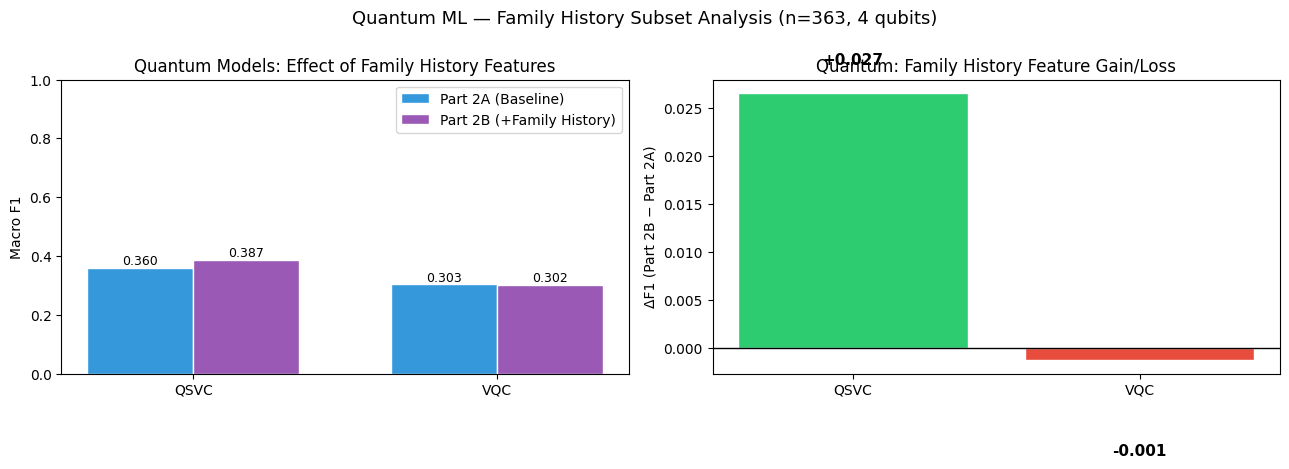


  Comparison table:
Model  F1_Part2A (Baseline)  F1_Part2B (+FamilyHist)  Delta_F1  AUC_Part2A  AUC_Part2B Family_Hist_Helps
 QSVC                0.3600                   0.3866    0.0266         NaN         NaN             Yes ✓
  VQC                0.3035                   0.3022   -0.0013      0.5098      0.5365              No ✗

  ✓ Quantum family history analysis complete.


In [39]:
def run_quantum_family_history(X_proc_2a, X_proc_2b, y_fam, le_fam,
                                fig_dir_2a, fig_dir_2b,
                                exp_dir_2a, exp_dir_2b,
                                n_qubits=4, cv_splits=3):
    """
    Quantum models on the family history subset.
    Compares Part 2A (baseline features) vs Part 2B (+ family history).
    No subsampling needed — n=363 is already small enough for quantum kernels.

    Returns:
        q_res_2a: quantum results for Part 2A
        q_res_2b: quantum results for Part 2B
        comparison_df: direct comparison table
    """
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import MinMaxScaler

    print(f"\n{'='*70}")
    print(f"  QUANTUM MODELS — FAMILY HISTORY SUBSET")
    print(f"  n_qubits={n_qubits}  |  cv_splits={cv_splits}")
    print(f"  Part 2A samples: {X_proc_2a.shape}  (baseline features)")
    print(f"  Part 2B samples: {X_proc_2b.shape}  (+family history features)")
    print(f"  Class distribution: {Counter(y_fam)}")
    print(f"{'='*70}")

    def run_quantum_on_subset(X_proc, y, le, label, fig_dir, exp_dir):
        """Inner function — runs QSVC + VQC on one dataset version."""
        print(f"\n  ── Running Quantum on {label} ──")

        # PCA compression to n_qubits
        scaler_q = MinMaxScaler(feature_range=(0, np.pi))
        pca_q    = PCA(n_components=n_qubits, random_state=42)
        X_scaled = scaler_q.fit_transform(X_proc)
        X_pca    = pca_q.fit_transform(X_scaled)
        var_exp  = pca_q.explained_variance_ratio_.sum()
        print(f"  PCA variance retained: {var_exp:.3f} ({n_qubits} components)")

        skf    = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
        le_enc = LabelEncoder(); le_enc.fit(y)

        # For n=363 with cv_splits=3: ~242 train, ~121 val per fold
        # No SMOTE needed here since the subset is already small — use class weights
        min_class = min(Counter(y).values())
        print(f"  Min class size: {min_class}  → {'SMOTE applied' if min_class >= 6 else 'no SMOTE (too small)'}")
        use_smote = min_class >= 6
        if use_smote:
            smote = SMOTE(random_state=42, k_neighbors=min(4, min_class - 1))

        qsvc_f1s, vqc_f1s = [], []
        qsvc_aucs, vqc_aucs = [], []
        qsvc_proba_all, vqc_proba_all, y_true_all = [], [], []

        if QUANTUM_AVAILABLE:
            from qiskit.primitives import StatevectorSampler as SV_Sampler
            from qiskit_machine_learning.state_fidelities import ComputeUncompute
            feature_map = ZZFeatureMap(feature_dimension=n_qubits, reps=2)
            ansatz      = RealAmplitudes(num_qubits=n_qubits, reps=3)
            sampler     = SV_Sampler()
            fidelity    = ComputeUncompute(sampler=sampler)
            kernel      = FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity)
            print(f"  ✅ QUANTUM running: ZZFeatureMap + FidelityKernel + RealAmplitudes")
        else:
            print(f"  ⚠️  Quantum fallback: polynomial SVM (degree 3 & 5)")

        for fold_i, (tr, val) in enumerate(skf.split(X_pca, y)):
            print(f"    Fold {fold_i+1}/{cv_splits} ...", end=" ")
            Xtr_q, Xval_q = X_pca[tr], X_pca[val]
            ytr_q, yval_q = np.array(y)[tr], np.array(y)[val]

            if use_smote:
                Xtr_q, ytr_q = smote.fit_resample(Xtr_q, ytr_q)

            ytr_enc  = le_enc.transform(ytr_q)
            yval_enc = le_enc.transform(yval_q)

            if QUANTUM_AVAILABLE:
                # QSVC
                qsvc = QSVC(quantum_kernel=kernel)
                qsvc.fit(Xtr_q, ytr_enc)
                qsvc_pred_enc = qsvc.predict(Xval_q)
                qsvc_pred = le_enc.inverse_transform(qsvc_pred_enc)
                try:
                    df_scores = qsvc._svc.decision_function(Xval_q)
                    from scipy.special import softmax as sp_softmax
                    qsvc_prob = sp_softmax(df_scores, axis=1)
                except Exception:
                    qsvc_prob = None

                # VQC
                try:
                    from qiskit_algorithms.optimizers import COBYLA as QiskitCOBYLA
                    vqc_opt = QiskitCOBYLA(maxiter=150)   # more iterations for small dataset
                except ImportError:
                    from scipy.optimize import minimize as sp_min
                    def vqc_opt(fun, x0, **kwargs):
                        r = sp_min(fun, x0, method="COBYLA", options={"maxiter": 150})
                        return r.x, r.fun, r.nfev
                vqc = VQC(feature_map=feature_map, ansatz=ansatz,
                          sampler=sampler, optimizer=vqc_opt)
                vqc.fit(Xtr_q, ytr_enc)
                vqc_pred_enc = vqc.predict(Xval_q)
                vqc_pred = le_enc.inverse_transform(vqc_pred_enc)
                try:
                    vqc_prob = vqc.predict_proba(Xval_q)
                except Exception:
                    vqc_prob = None
            else:
                from sklearn.svm import SVC as SVC_poly
                qsvc_clf = SVC_poly(kernel="poly", degree=3, class_weight="balanced",
                                    probability=True, random_state=42)
                qsvc_clf.fit(Xtr_q, ytr_enc)
                qsvc_pred = le_enc.inverse_transform(qsvc_clf.predict(Xval_q))
                qsvc_prob = qsvc_clf.predict_proba(Xval_q)

                vqc_clf = SVC_poly(kernel="poly", degree=5, class_weight="balanced",
                                   probability=True, random_state=42)
                vqc_clf.fit(Xtr_q, ytr_enc)
                vqc_pred = le_enc.inverse_transform(vqc_clf.predict(Xval_q))
                vqc_prob = vqc_clf.predict_proba(Xval_q)

            qsvc_f1s.append(f1_score(yval_q, qsvc_pred, average="macro", zero_division=0))
            vqc_f1s.append( f1_score(yval_q, vqc_pred,  average="macro", zero_division=0))

            classes_s = sorted(set(yval_q))
            yval_bin  = label_binarize(yval_q, classes=classes_s)
            for prob, auc_list, prob_list in [
                (qsvc_prob, qsvc_aucs, qsvc_proba_all),
                (vqc_prob,  vqc_aucs,  vqc_proba_all),
            ]:
                if prob is not None and prob.shape[1] == yval_bin.shape[1]:
                    try:
                        auc_list.append(roc_auc_score(yval_bin, prob,
                                                      average="macro", multi_class="ovr"))
                        prob_list.append(prob)
                    except Exception:
                        pass
            y_true_all.extend(yval_q)

            mode = "🔬 QUANTUM" if QUANTUM_AVAILABLE else "⚙️  FALLBACK"
            print(f"[{mode}]  QSVC F1={qsvc_f1s[-1]:.3f}  VQC F1={vqc_f1s[-1]:.3f}")

        mode_label = "Quantum" if QUANTUM_AVAILABLE else "Classical Poly-SVM (Fallback)"
        results = {
            f"QSVC [{mode_label}]": {
                "Accuracy":    (np.nan, np.nan),
                "Macro_F1":    (np.mean(qsvc_f1s), np.std(qsvc_f1s)),
                "Weighted_F1": (np.nan, np.nan),
                "Macro_AUC":   (np.mean(qsvc_aucs), np.std(qsvc_aucs))
                               if qsvc_aucs else (np.nan, np.nan),
                "Variance_Retained": var_exp,
                "_proba_folds": qsvc_proba_all,
                "_ytrue_folds": [np.array(y_true_all[:len(p)]) for p in qsvc_proba_all],
            },
            f"VQC [{mode_label}]": {
                "Accuracy":    (np.nan, np.nan),
                "Macro_F1":    (np.mean(vqc_f1s), np.std(vqc_f1s)),
                "Weighted_F1": (np.nan, np.nan),
                "Macro_AUC":   (np.mean(vqc_aucs), np.std(vqc_aucs))
                               if vqc_aucs else (np.nan, np.nan),
                "Variance_Retained": var_exp,
                "_proba_folds": vqc_proba_all,
                "_ytrue_folds": [np.array(y_true_all[:len(p)]) for p in vqc_proba_all],
            },
        }

        for mname, r in results.items():
            f1m, f1s = r["Macro_F1"]
            am, as_ = r["Macro_AUC"]
            print(f"  {mname}  F1={f1m:.4f}±{f1s:.4f}  AUC={am:.4f}")

        pd.DataFrame([{
            "Model": k, "Dataset": label,
            "Macro_F1": f"{v['Macro_F1'][0]:.4f}±{v['Macro_F1'][1]:.4f}",
            "Macro_AUC": f"{v['Macro_AUC'][0]:.4f}",
            "PCA_Variance_Retained": f"{v['Variance_Retained']:.3f}",
        } for k, v in results.items()]).to_csv(
            f"{exp_dir}/quantum_family_{label.replace(' ','_')}.csv", index=False)

        return results

    # ── Run on both versions ──────────────────────────────────────────────
    q_res_2a = run_quantum_on_subset(
        X_proc_2a, y_fam, le_fam,
        "Part2A_BaselineOnly", fig_dir_2a, exp_dir_2a)

    q_res_2b = run_quantum_on_subset(
        X_proc_2b, y_fam, le_fam,
        "Part2B_WithFamilyHistory", fig_dir_2b, exp_dir_2b)

    # ── Head-to-head comparison plot ─────────────────────────────────────
    print(f"\n  ── Quantum: Part 2A vs Part 2B (Family History Impact) ──")
    compare_rows = []
    model_labels = ["QSVC", "VQC"]
    mode_lbl = "Quantum" if QUANTUM_AVAILABLE else "Classical Poly-SVM (Fallback)"

    for short_name in model_labels:
        key = f"{short_name} [{mode_lbl}]"
        f1_2a  = q_res_2a[key]["Macro_F1"][0]
        f1_2b  = q_res_2b[key]["Macro_F1"][0]
        auc_2a = q_res_2a[key]["Macro_AUC"][0]
        auc_2b = q_res_2b[key]["Macro_AUC"][0]
        delta  = f1_2b - f1_2a
        compare_rows.append({
            "Model": short_name,
            "F1_Part2A (Baseline)":    round(f1_2a,  4),
            "F1_Part2B (+FamilyHist)": round(f1_2b,  4),
            "Delta_F1":                round(delta,  4),
            "AUC_Part2A":              round(auc_2a, 4),
            "AUC_Part2B":              round(auc_2b, 4),
            "Family_Hist_Helps":       "Yes ✓" if delta > 0 else "No ✗",
        })
        print(f"  {short_name}:  2A F1={f1_2a:.4f} → 2B F1={f1_2b:.4f}  (Δ={delta:+.4f})")

    comparison_df = pd.DataFrame(compare_rows)
    comparison_df.to_csv(
        f"{REPORT_DIR}/quantum_family_history_comparison.csv", index=False)

    # ── Grouped comparison chart ──────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    x = np.arange(len(model_labels)); w = 0.35

    f1_2a_vals = comparison_df["F1_Part2A (Baseline)"].values
    f1_2b_vals = comparison_df["F1_Part2B (+FamilyHist)"].values

    axes[0].bar(x - w/2, f1_2a_vals, w, label="Part 2A (Baseline)",
                color="#3498DB", edgecolor="white")
    axes[0].bar(x + w/2, f1_2b_vals, w, label="Part 2B (+Family History)",
                color="#9B59B6", edgecolor="white")
    axes[0].set_xticks(x); axes[0].set_xticklabels(model_labels)
    axes[0].set_ylabel("Macro F1")
    axes[0].set_title("Quantum Models: Effect of Family History Features")
    axes[0].legend(); axes[0].set_ylim(0, 1)
    for xi, (va, vb) in enumerate(zip(f1_2a_vals, f1_2b_vals)):
        axes[0].text(xi - w/2, va + 0.01, f"{va:.3f}", ha="center", fontsize=9)
        axes[0].text(xi + w/2, vb + 0.01, f"{vb:.3f}", ha="center", fontsize=9)

    # Delta bars
    delta_vals = comparison_df["Delta_F1"].values
    delta_colors = ["#2ECC71" if d > 0 else "#E74C3C" for d in delta_vals]
    bars = axes[1].bar(model_labels, delta_vals, color=delta_colors, edgecolor="white")
    axes[1].axhline(0, color="black", lw=1)
    axes[1].set_ylabel("ΔF1 (Part 2B − Part 2A)")
    axes[1].set_title("Quantum: Family History Feature Gain/Loss")
    for bar, val in zip(bars, delta_vals):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + (0.003 if val >= 0 else -0.01),
                     f"{val:+.3f}", ha="center", fontsize=11, fontweight="bold")

    plt.suptitle(f"Quantum ML — Family History Subset Analysis (n=363, {n_qubits} qubits)",
                 fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{FIGURE_DIR}/quantum_family_history_comparison.png", dpi=300)
    plt.show()

    print(f"\n  Comparison table:")
    print(comparison_df.to_string(index=False))
    print(f"\n  ✓ Quantum family history analysis complete.")
    return q_res_2a, q_res_2b, comparison_df


# ── Preprocess Part 2A and Part 2B for quantum input ─────────────────────────
print("Preprocessing family history subsets for quantum models...")

num_2a = X_fam_base.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_2a = X_fam_base.select_dtypes(include=["object","bool","category"]).columns.tolist()
prep_2a = build_preprocessor(num_2a, cat_2a)
Xproc_fam_2a = prep_2a.fit_transform(X_fam_base)

num_2b = X_fam_raw.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_2b = X_fam_raw.select_dtypes(include=["object","bool","category"]).columns.tolist()
prep_2b = build_preprocessor(num_2b, cat_2b)
Xproc_fam_2b = prep_2b.fit_transform(X_fam_raw)

print(f"Part 2A processed: {Xproc_fam_2a.shape}")
print(f"Part 2B processed: {Xproc_fam_2b.shape}")

# ── Run quantum analysis ──────────────────────────────────────────────────────
q_res_fam_2a, q_res_fam_2b, q_fam_comparison = run_quantum_family_history(
    Xproc_fam_2a, Xproc_fam_2b, y_fam, le_p2a,
    fig_dir_2a = f"{FIGURE_DIR}/Part2A_FamilySubset_BaselineOnly",
    fig_dir_2b = f"{FIGURE_DIR}/Part2B_FamilySubset_WithFamily",
    exp_dir_2a = f"{REPORT_DIR}/Part2A_FamilySubset_BaselineOnly",
    exp_dir_2b = f"{REPORT_DIR}/Part2B_FamilySubset_WithFamily",
    n_qubits=4,
    cv_splits=3
)

## 11. TEMPORAL FUSION TRANSFORMER (TFT) FOR PRO-ACT CORPUS
TFT is a state-of-the-art temporal attention model designed for tabular time-series.
Since each patient has one row (no multi-timestep sequence here), we implement
a feature-attention TFT-style architecture in PyTorch that mimics TFT's
variable selection networks and multi-head attention.


In [40]:
class VariableSelectionNetwork(nn.Module):
    """
    TFT-style Variable Selection Network.
    Learns soft attention weights over input features.
    """
    def __init__(self, input_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.grn = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, input_dim),
        )
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):
        weights = self.softmax(self.grn(x))   # (B, input_dim)
        return x * weights, weights            # selected features + importance weights


class GatedResidualNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.1):
        super().__init__()
        self.fc1  = nn.Linear(input_dim, hidden_dim)
        self.elu  = nn.ELU()
        self.fc2  = nn.Linear(hidden_dim, output_dim)
        self.gate = nn.Linear(input_dim, output_dim)
        self.norm = nn.LayerNorm(output_dim)
        self.drop = nn.Dropout(dropout)
        self.proj = nn.Linear(input_dim, output_dim) if input_dim != output_dim else nn.Identity()

    def forward(self, x):
        h = self.elu(self.fc1(x))
        h = self.drop(self.fc2(h))
        g = torch.sigmoid(self.gate(x))
        return self.norm(h * g + self.proj(x))


class TFTClassifier(nn.Module):
    """
    Temporal Fusion Transformer-inspired classifier for tabular data.
    Architecture:
        1. Variable Selection Network (learns feature importances)
        2. Gated Residual Networks (non-linear feature transformation)
        3. Multi-Head Self-Attention (inter-feature relationships)
        4. Output head for classification
    """
    def __init__(self, input_dim, n_classes, hidden_dim=128, n_heads=4, dropout=0.2):
        super().__init__()
        self.vsn  = VariableSelectionNetwork(input_dim, hidden_dim, dropout)
        self.grn1 = GatedResidualNetwork(input_dim, hidden_dim, hidden_dim, dropout)
        self.grn2 = GatedResidualNetwork(hidden_dim, hidden_dim, hidden_dim, dropout)

        # Treat each feature as a "token" for attention
        self.attn = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=n_heads,
                                          dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(hidden_dim)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x_sel, attn_weights = self.vsn(x)
        h = self.grn1(x_sel)
        h_unsq = h.unsqueeze(1)               # (B, 1, hidden_dim)
        h_attn, _ = self.attn(h_unsq, h_unsq, h_unsq)
        h = self.norm(h_unsq + h_attn).squeeze(1)
        h = self.grn2(h)
        return self.head(h), attn_weights      # logits + variable importances

print("TFT model architecture defined ✓")

TFT model architecture defined ✓


In [41]:
def train_tft(X_train, y_train, X_val, y_val, n_classes,
              hidden_dim=128, n_heads=4, dropout=0.2,
              epochs=60, batch_size=64, lr=1e-3, patience=10, device="cpu"):
    """Train TFT model and return (model, val_proba, val_pred)."""
    input_dim = X_train.shape[1]
    model = TFTClassifier(input_dim, n_classes, hidden_dim, n_heads, dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5)

    # Compute class weights for imbalance
    from sklearn.utils.class_weight import compute_class_weight
    cw = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
    cw_tensor = torch.tensor(cw, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=cw_tensor)

    Xtr_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    ytr_t = torch.tensor(y_train, dtype=torch.long).to(device)
    Xval_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    yval_t = torch.tensor(y_val, dtype=torch.long).to(device)

    train_ds = TensorDataset(Xtr_t, ytr_t)
    loader   = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    best_val_loss = float("inf")
    best_state    = None
    patience_cnt  = 0

    for epoch in range(epochs):
        model.train()
        for Xb, yb in loader:
            optimizer.zero_grad()
            logits, _ = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits, _ = model(Xval_t)
            val_loss = criterion(val_logits, yval_t).item()

        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        logits, _ = model(Xval_t)
        proba = torch.softmax(logits, dim=1).cpu().numpy()
        pred  = np.argmax(proba, axis=1)
    return model, proba, pred


def evaluate_tft_cv(folds, le, n_classes=3, cv_splits=10, device="cpu"):
    """CV evaluation of TFT across pre-computed SMOTE folds."""
    accs, f1s_mac, f1s_wt, aucs = [], [], [], []
    all_proba, all_ytrue = [], []

    for fold_i, (Xtr, ytr, Xval, yval) in enumerate(folds):
        print(f"    TFT fold {fold_i+1}/{len(folds)} ...", end=" ")
        ytr_enc  = le.transform(ytr)
        yval_enc = le.transform(yval)

        _, proba, pred_enc = train_tft(
            Xtr, ytr_enc, Xval, yval_enc,
            n_classes=n_classes, device=device)

        pred = le.inverse_transform(pred_enc)
        accs.append(accuracy_score(yval, pred))
        f1s_mac.append(f1_score(yval, pred, average="macro", zero_division=0))
        f1s_wt.append( f1_score(yval, pred, average="weighted", zero_division=0))

        classes_s = sorted(set(yval))
        yval_bin  = label_binarize(yval, classes=classes_s)
        try:
            aucs.append(roc_auc_score(yval_bin, proba, average="macro", multi_class="ovr"))
            all_proba.append(proba)
            all_ytrue.append(yval)
        except Exception:
            pass
        print(f"F1={f1s_mac[-1]:.3f}")

    return {
        "Accuracy":    (np.mean(accs),    np.std(accs)),
        "Macro_F1":    (np.mean(f1s_mac), np.std(f1s_mac)),
        "Weighted_F1": (np.mean(f1s_wt),  np.std(f1s_wt)),
        "Macro_AUC":   (np.mean(aucs), np.std(aucs)) if aucs else (np.nan, np.nan),
        "_proba_folds": all_proba,
        "_ytrue_folds": all_ytrue,
    }

if TORCH_AVAILABLE:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"\nRunning TFT on: {DEVICE}")
    res_tft_p1 = evaluate_tft_cv(folds_p1, le_p1, n_classes=3, device=DEVICE)
    print(f"\nTFT Results — Part1:")
    print(f"  Macro F1  = {res_tft_p1['Macro_F1'][0]:.4f} ± {res_tft_p1['Macro_F1'][1]:.4f}")
    print(f"  Macro AUC = {res_tft_p1['Macro_AUC'][0]:.4f} ± {res_tft_p1['Macro_AUC'][1]:.4f}")
else:
    print("PyTorch not available — TFT skipped.")
    res_tft_p1 = {"Macro_F1": (np.nan, np.nan), "Macro_AUC": (np.nan, np.nan)}


Running TFT on: cuda
    TFT fold 1/10 ... F1=0.550
    TFT fold 2/10 ... F1=0.561
    TFT fold 3/10 ... F1=0.589
    TFT fold 4/10 ... F1=0.517
    TFT fold 5/10 ... F1=0.589
    TFT fold 6/10 ... F1=0.560
    TFT fold 7/10 ... F1=0.579
    TFT fold 8/10 ... F1=0.585
    TFT fold 9/10 ... F1=0.596
    TFT fold 10/10 ... F1=0.556

TFT Results — Part1:
  Macro F1  = 0.5681 ± 0.0229
  Macro AUC = 0.7727 ± 0.0173


## 12. ABLATION STUDY
Systematically remove one feature group at a time to measure each group's contribution.
Feature groups: Vitals | Demographic | Family History | Engineered Features



  ABLATION STUDY — Part1_FullCohort_NoFamily
  Baseline  Macro_F1=0.6347  Macro_AUC=0.8147
  w/o Vitals          F1=0.6385  AUC=0.8144  DROP=-0.0038
  w/o Demographics    F1=0.6132  AUC=0.7985  DROP=+0.0215
  Family Hist: no columns present — skipped
  w/o Engineered      F1=0.6390  AUC=0.8131  DROP=-0.0043


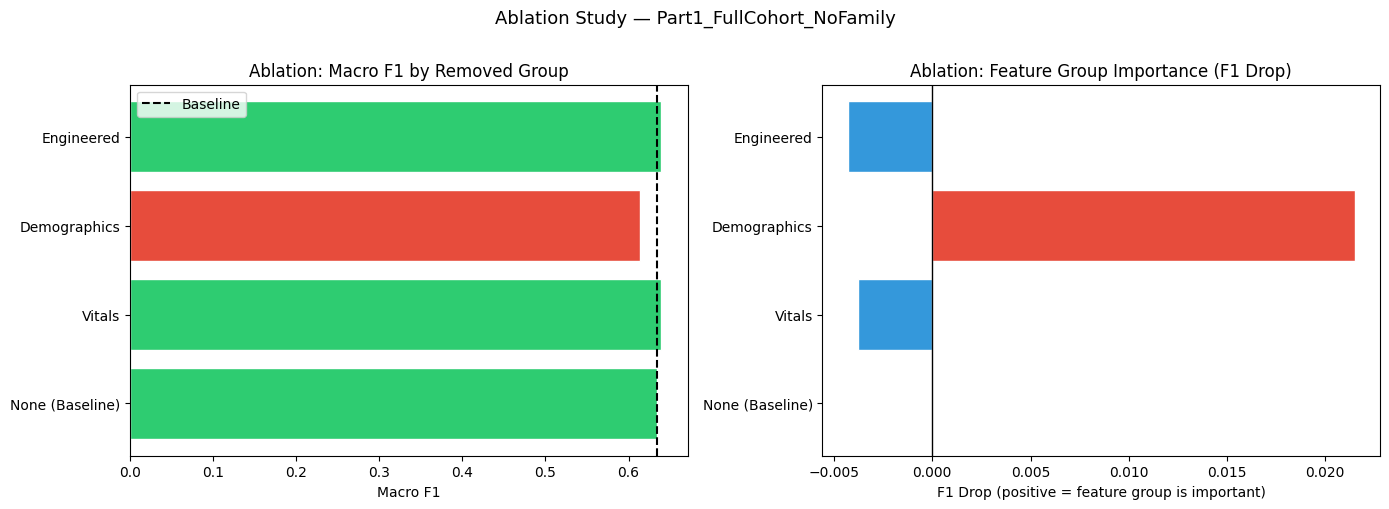

  Ablation figure saved → /kaggle/working/figures/Part1_FullCohort_NoFamily/ablation_study.png
  Removed Group  Features Removed  Macro_F1    AUC  F1 Drop
None (Baseline)                 0    0.6347 0.8147   0.0000
         Vitals                 1    0.6385 0.8144  -0.0038
   Demographics                 4    0.6132 0.7985   0.0215
     Engineered                 7    0.6390 0.8131  -0.0043


In [42]:
def run_ablation_study(X_raw, y, le, experiment_name, fig_dir, exp_dir,
                       best_model_params=None):
    """
    Ablation study: train the best model (XGBoost by default) with
    one feature group removed at a time. Reports drop in Macro-F1.
    """
    print(f"\n{'='*70}")
    print(f"  ABLATION STUDY — {experiment_name}")
    print(f"{'='*70}")

    # Define feature groups
    feature_groups = {
        "Vitals":       ["Weight", "Blood_Pressure_Systolic", "Blood_Pressure_Diastolic",
                         "Pulse", "Respiratory_Rate", "Height"],
        "Demographics": ["Age", "Sex", "Race", "Ethnicity"],
        "Family Hist":  FAMILY_COLS,
        "Engineered":   ["BMI", "Pulse_Pressure", "Weight_Declining"] +
                         [c for c in X_raw.columns if c.endswith("_observed")],
    }

    num_cols = X_raw.select_dtypes(include=["int64","float64"]).columns.tolist()
    cat_cols = X_raw.select_dtypes(include=["object","bool","category"]).columns.tolist()

    # ── Baseline: all features ────────────────────────────────────────────
    prep_all = build_preprocessor(num_cols, cat_cols)
    X_all    = prep_all.fit_transform(X_raw)
    folds_all = apply_smote_cv(X_raw, np.array(y), num_cols, cat_cols, cv_splits=5)

    if best_model_params:
        base_factory = lambda: XGBClassifier(
            **best_model_params, objective="multi:softprob",
            num_class=3, random_state=42, verbosity=0)
        res_base = evaluate_folds(folds_all, base_factory, label_encoder=le)
    else:
        res_base = evaluate_folds(folds_all,
            lambda: RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                           random_state=42, n_jobs=-1))
    baseline_f1  = res_base["Macro_F1"][0]
    baseline_auc = res_base["Macro_AUC"][0]
    print(f"  Baseline  Macro_F1={baseline_f1:.4f}  Macro_AUC={baseline_auc:.4f}")

    rows = [{"Removed Group": "None (Baseline)",
             "Features Removed": 0,
             "Macro_F1": round(baseline_f1, 4),
             "AUC": round(baseline_auc, 4),
             "F1 Drop": 0.0}]

    for group_name, cols_to_drop in feature_groups.items():
        cols_present = [c for c in cols_to_drop if c in X_raw.columns]
        if not cols_present:
            print(f"  {group_name}: no columns present — skipped")
            continue

        X_ablated = X_raw.drop(columns=cols_present, errors="ignore")
        num_ab = X_ablated.select_dtypes(include=["int64","float64"]).columns.tolist()
        cat_ab = X_ablated.select_dtypes(include=["object","bool","category"]).columns.tolist()

        if X_ablated.shape[1] == 0:
            print(f"  {group_name}: all columns removed — skipped")
            continue

        folds_ab = apply_smote_cv(X_ablated, np.array(y), num_ab, cat_ab, cv_splits=5)
        if best_model_params:
            res_ab = evaluate_folds(folds_ab, base_factory, label_encoder=le)
        else:
            res_ab = evaluate_folds(folds_ab,
                lambda: RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                               random_state=42, n_jobs=-1))

        ab_f1  = res_ab["Macro_F1"][0]
        ab_auc = res_ab["Macro_AUC"][0]
        drop   = baseline_f1 - ab_f1
        rows.append({"Removed Group": group_name,
                     "Features Removed": len(cols_present),
                     "Macro_F1": round(ab_f1, 4),
                     "AUC": round(ab_auc, 4),
                     "F1 Drop": round(drop, 4)})
        print(f"  w/o {group_name:<15} F1={ab_f1:.4f}  AUC={ab_auc:.4f}  DROP={drop:+.4f}")

    ablation_df = pd.DataFrame(rows)
    ablation_df.to_csv(f"{exp_dir}/ablation_study.csv", index=False)

    # ── Plot ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = ["#2ECC71" if d <= 0 else "#E74C3C" for d in ablation_df["F1 Drop"]]
    axes[0].barh(ablation_df["Removed Group"], ablation_df["Macro_F1"],
                 color=colors, edgecolor="white")
    axes[0].axvline(baseline_f1, color="black", linestyle="--", lw=1.5, label="Baseline")
    axes[0].set_xlabel("Macro F1"); axes[0].set_title("Ablation: Macro F1 by Removed Group")
    axes[0].legend()

    axes[1].barh(ablation_df["Removed Group"], ablation_df["F1 Drop"],
                 color=["#E74C3C" if d > 0 else "#3498DB" for d in ablation_df["F1 Drop"]],
                 edgecolor="white")
    axes[1].axvline(0, color="black", lw=1)
    axes[1].set_xlabel("F1 Drop (positive = feature group is important)")
    axes[1].set_title("Ablation: Feature Group Importance (F1 Drop)")

    plt.suptitle(f"Ablation Study — {experiment_name}", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/ablation_study.png", dpi=300)
    plt.show()
    print(f"  Ablation figure saved → {fig_dir}/ablation_study.png")
    return ablation_df

# Run ablation on Part 1
ablation_df_p1 = run_ablation_study(
    X_full_raw, y_full, le_p1,
    "Part1_FullCohort_NoFamily",
    f"{FIGURE_DIR}/Part1_FullCohort_NoFamily",
    f"{REPORT_DIR}/Part1_FullCohort_NoFamily",
    best_model_params=xgb_p1
)
print(ablation_df_p1.to_string(index=False))

## 13. SHAP MODEL INTERPRETATION
SHAP (SHapley Additive exPlanations) provides theoretically grounded feature attributions.
We compute:
- **Global**: SHAP summary plot (beeswarm) and bar chart of mean |SHAP|
- **Local**: Waterfall plot for individual patients (correct + misclassified)
- **Class-specific**: SHAP values per survival class



  SHAP ANALYSIS — Part1_FullCohort_NoFamily
  Hold-out  Acc=0.6676  Macro_F1=0.6656
  SHAP: n_features=46, fn=46, n_classes=3


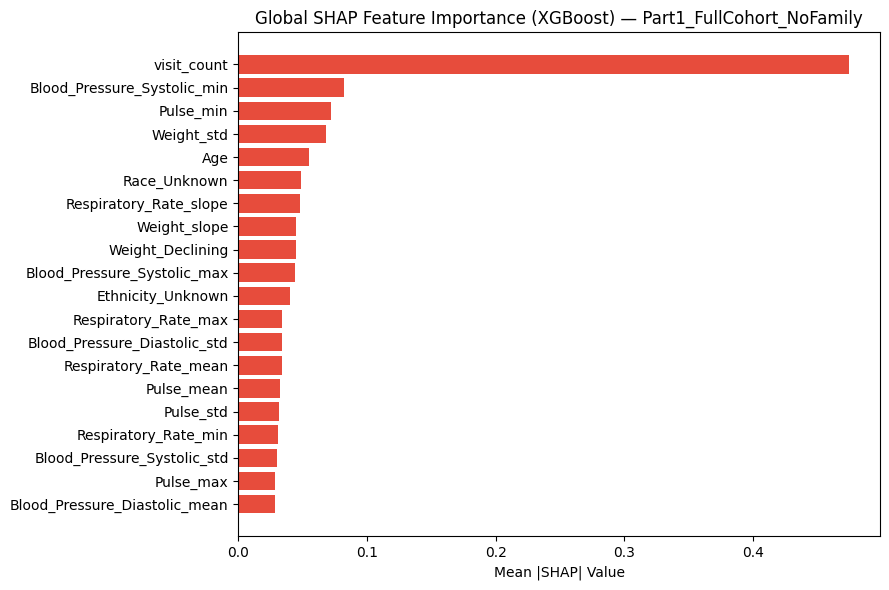

  Global SHAP bar chart saved.


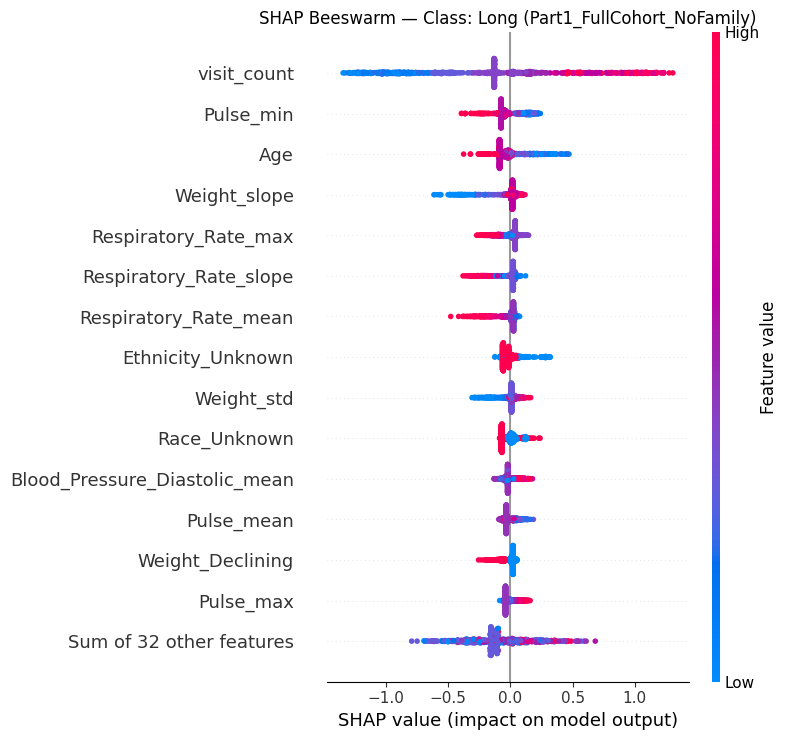

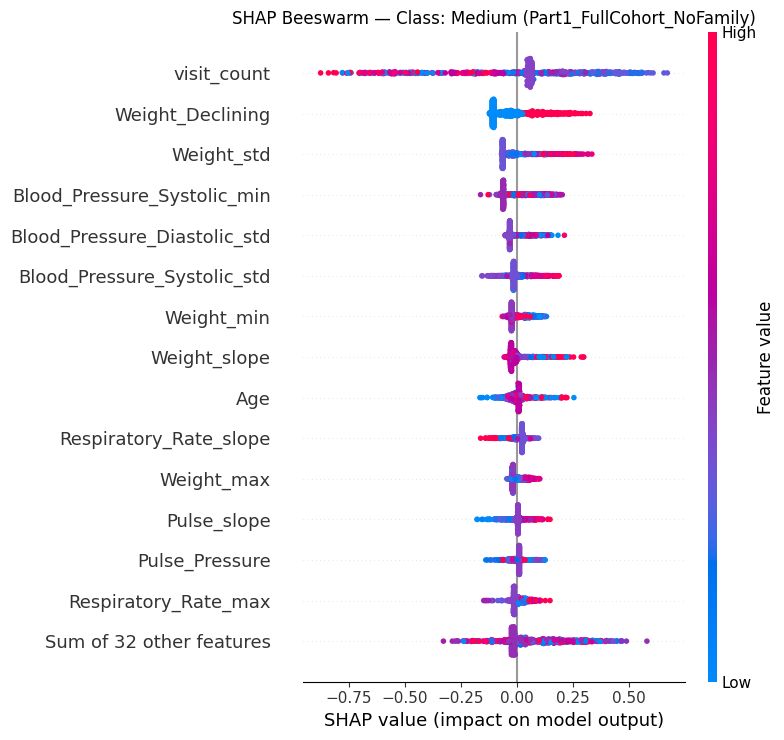

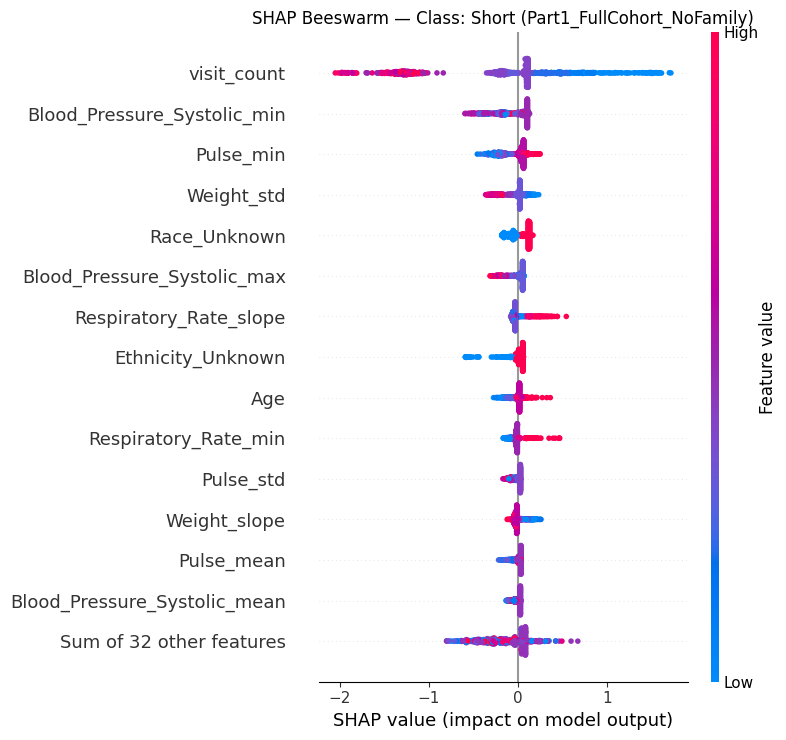

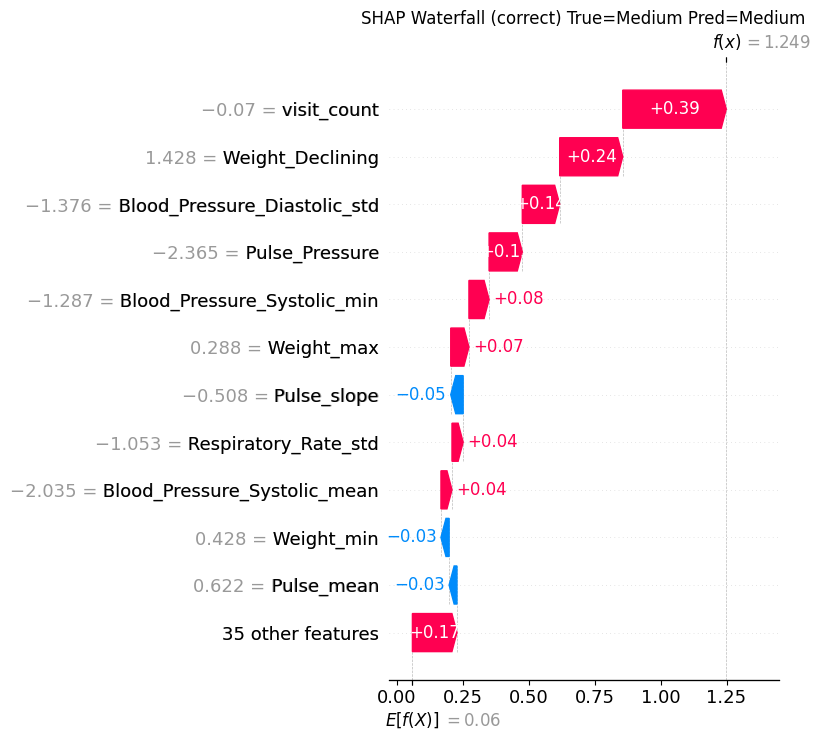

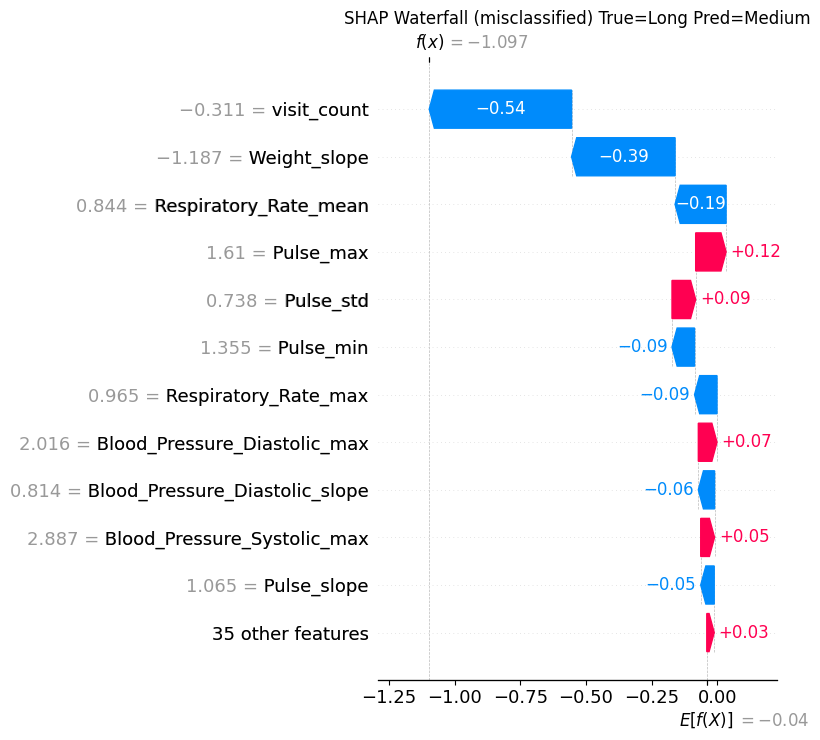

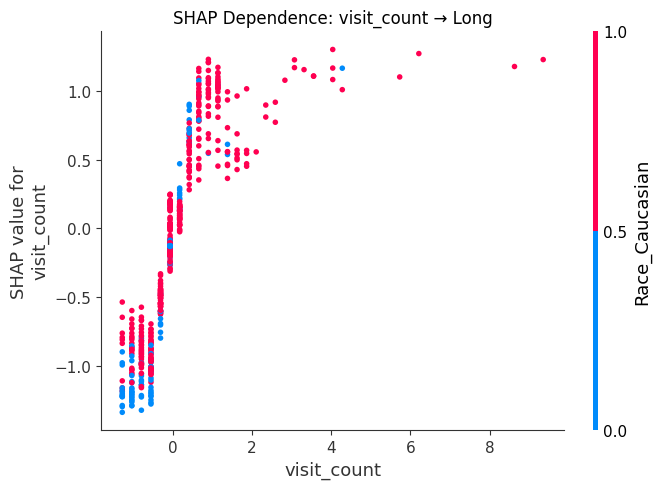

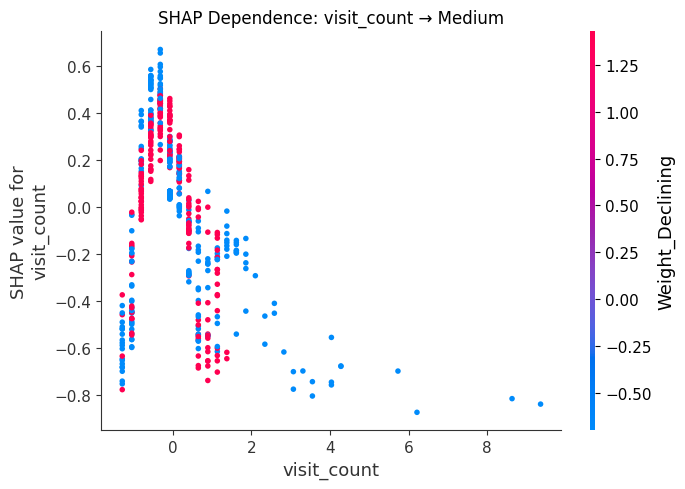

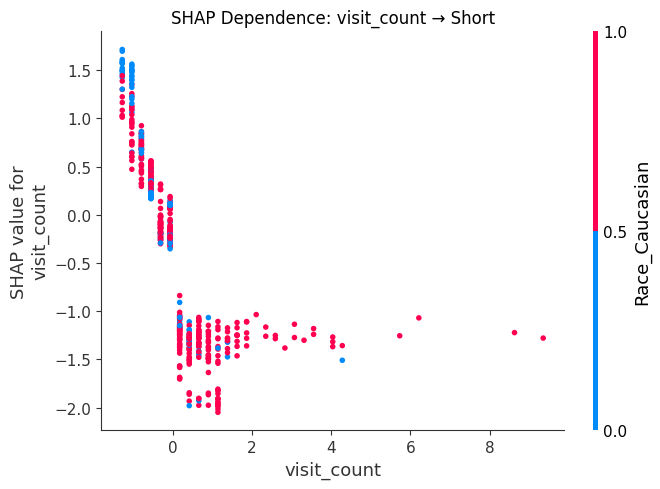

  All SHAP figures saved → /kaggle/working/figures/Part1_FullCohort_NoFamily

Top 10 features by SHAP:
                    Feature  Mean |SHAP|
                visit_count     0.475150
Blood_Pressure_Systolic_min     0.082445
                  Pulse_min     0.072242
                 Weight_std     0.068157
                        Age     0.054798
               Race_Unknown     0.048728
     Respiratory_Rate_slope     0.048037
               Weight_slope     0.045183
           Weight_Declining     0.044457
Blood_Pressure_Systolic_max     0.043764


In [43]:
def run_shap_analysis(X_raw, y, le, feature_names_full, xgb_params,
                      experiment_name, fig_dir, exp_dir):
    print(f"\n{'='*70}")
    print(f"  SHAP ANALYSIS — {experiment_name}")
    print(f"{'='*70}")

    num_cols = X_raw.select_dtypes(include=["int64","float64"]).columns.tolist()
    cat_cols = X_raw.select_dtypes(include=["object","bool","category"]).columns.tolist()

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    tr_idx, te_idx = next(sss.split(X_raw, y))

    prep = build_preprocessor(num_cols, cat_cols)
    Xtr  = prep.fit_transform(X_raw.iloc[tr_idx])
    Xte  = prep.transform(X_raw.iloc[te_idx])
    ytr  = np.array(y)[tr_idx]
    yte  = np.array(y)[te_idx]

    k_nn = min(4, min(Counter(ytr).values()) - 1)
    smote = SMOTE(random_state=42, k_neighbors=k_nn)
    Xtr_r, ytr_r = smote.fit_resample(Xtr, ytr)

    ytr_enc = le.transform(ytr_r)
    yte_enc = le.transform(yte)

    xgb_model = XGBClassifier(**xgb_params, objective="multi:softprob",
                               num_class=3, random_state=42, verbosity=0)
    xgb_model.fit(Xtr_r, ytr_enc)
    ypred_enc = xgb_model.predict(Xte)
    ypred = le.inverse_transform(ypred_enc)

    test_f1  = f1_score(yte, ypred, average="macro", zero_division=0)
    test_acc = accuracy_score(yte, ypred)
    print(f"  Hold-out  Acc={test_acc:.4f}  Macro_F1={test_f1:.4f}")

    # ── SHAP TreeExplainer ────────────────────────────────────────────────
    explainer = shap.TreeExplainer(xgb_model)
    shap_values_raw = explainer.shap_values(Xte)

    # Normalise to list of 2D arrays regardless of SHAP/XGBoost version
    if isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
        shap_values = [shap_values_raw[:, :, c] for c in range(shap_values_raw.shape[2])]
    elif isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 2:
        shap_values = [shap_values_raw]
    else:
        shap_values = shap_values_raw

    # expected_value: list in older SHAP, scalar in newer — normalise
    ev = explainer.expected_value
    def get_ev(c):
        return ev[c] if hasattr(ev, "__len__") else float(ev)

    classes_sorted = list(le.classes_)
    n_features = Xte.shape[1]
    fn = feature_names_full[:n_features]
    print(f"  SHAP: n_features={n_features}, fn={len(fn)}, n_classes={len(shap_values)}")

    # ── 13.1  Global bar chart ────────────────────────────────────────────
    shap_stack    = np.stack([np.abs(sv) for sv in shap_values], axis=0)
    mean_abs_shap = shap_stack.mean(axis=(0, 1))
    assert len(fn) == len(mean_abs_shap), f"Mismatch: {len(fn)} vs {len(mean_abs_shap)}"

    shap_df = (pd.DataFrame({"Feature": fn, "Mean |SHAP|": mean_abs_shap})
               .sort_values("Mean |SHAP|", ascending=False))
    shap_df.to_csv(f"{exp_dir}/shap_global_importance.csv", index=False)

    fig, ax = plt.subplots(figsize=(9, 6))
    top20 = shap_df.head(20)
    ax.barh(top20["Feature"][::-1], top20["Mean |SHAP|"][::-1], color="#E74C3C")
    ax.set_xlabel("Mean |SHAP| Value")
    ax.set_title(f"Global SHAP Feature Importance (XGBoost) — {experiment_name}")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/shap_global_bar.png", dpi=300)
    plt.show()
    print("  Global SHAP bar chart saved.")

    # ── 13.2  Beeswarm per class ──────────────────────────────────────────
    for c_idx, cls_name in enumerate(classes_sorted):
        sv_cls = shap_values[c_idx]
        expl = shap.Explanation(
            values=sv_cls,
            base_values=np.full(len(Xte), get_ev(c_idx)),
            data=Xte,
            feature_names=fn
        )
        fig, ax = plt.subplots(figsize=(9, 6))
        shap.plots.beeswarm(expl, max_display=15, show=False)
        plt.title(f"SHAP Beeswarm — Class: {cls_name} ({experiment_name})")
        plt.tight_layout()
        plt.savefig(f"{fig_dir}/shap_beeswarm_{cls_name}.png", dpi=300)
        plt.show()

    # ── 13.3  Waterfall: correct + misclassified ──────────────────────────
    correct_idx       = np.where(ypred == yte)[0]
    misclassified_idx = np.where(ypred != yte)[0]

    for label, idx_arr in [("correct", correct_idx), ("misclassified", misclassified_idx)]:
        if len(idx_arr) == 0:
            continue
        sample_idx = idx_arr[0]
        true_cls   = yte[sample_idx]
        pred_cls   = ypred[sample_idx]
        c_idx      = le.transform([true_cls])[0]

        expl_sample = shap.Explanation(
            values=shap_values[c_idx][sample_idx],
            base_values=get_ev(c_idx),
            data=Xte[sample_idx],
            feature_names=fn
        )
        fig, ax = plt.subplots(figsize=(8, 5))
        shap.plots.waterfall(expl_sample, max_display=12, show=False)
        plt.title(f"SHAP Waterfall ({label}) True={true_cls} Pred={pred_cls}")
        plt.tight_layout()
        plt.savefig(f"{fig_dir}/shap_waterfall_{label}.png", dpi=300)
        plt.show()

    # ── 13.4  Dependence plot for top feature ─────────────────────────────
    top_feat_idx = np.argmax(mean_abs_shap)
    for c_idx, cls_name in enumerate(classes_sorted):
        fig, ax = plt.subplots(figsize=(7, 5))
        shap.dependence_plot(top_feat_idx, shap_values[c_idx], Xte,
                             feature_names=fn, ax=ax, show=False)
        ax.set_title(f"SHAP Dependence: {fn[top_feat_idx]} → {cls_name}")
        plt.tight_layout()
        plt.savefig(f"{fig_dir}/shap_dependence_{cls_name}_{fn[top_feat_idx]}.png", dpi=300)
        plt.show()

    print(f"  All SHAP figures saved → {fig_dir}")
    return shap_df, shap_values, Xte, yte, ypred

shap_df_p1, shap_vals_p1, Xte_p1, yte_p1, ypred_p1 = run_shap_analysis(
    X_full_raw, y_full, le_p1, feat_p1, xgb_p1,
    "Part1_FullCohort_NoFamily",
    f"{FIGURE_DIR}/Part1_FullCohort_NoFamily",
    f"{REPORT_DIR}/Part1_FullCohort_NoFamily"
)
print("\nTop 10 features by SHAP:")
print(shap_df_p1.head(10).to_string(index=False))

## 14. PERMUTATION FEATURE IMPORTANCE (Model-Agnostic Cross-Validation)
Permutation importance is model-agnostic and cross-validates SHAP findings.
Each feature's importance is measured by the drop in Macro-F1 when that feature is shuffled.



── Permutation Importance — Part1_FullCohort_NoFamily ──


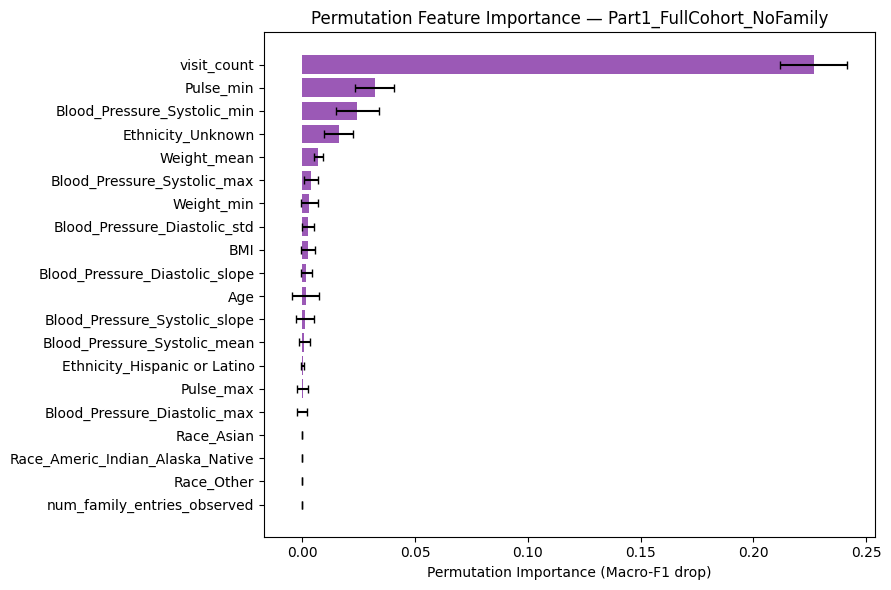

                       Feature  Importance      Std
                   visit_count    0.226872 0.014893
                     Pulse_min    0.032064 0.008715
   Blood_Pressure_Systolic_min    0.024336 0.009505
             Ethnicity_Unknown    0.016125 0.006289
                   Weight_mean    0.007146 0.001882
   Blood_Pressure_Systolic_max    0.003951 0.003159
                    Weight_min    0.003190 0.003645
  Blood_Pressure_Diastolic_std    0.002492 0.002718
                           BMI    0.002422 0.003039
Blood_Pressure_Diastolic_slope    0.001852 0.002648


In [44]:
from sklearn.inspection import permutation_importance

def run_permutation_importance(X_raw, y, le, xgb_params,
                               experiment_name, fig_dir, exp_dir):
    print(f"\n── Permutation Importance — {experiment_name} ──")
    num_cols = X_raw.select_dtypes(include=["int64","float64"]).columns.tolist()
    cat_cols = X_raw.select_dtypes(include=["object","bool","category"]).columns.tolist()

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    tr_idx, te_idx = next(sss.split(X_raw, y))
    prep = build_preprocessor(num_cols, cat_cols)
    Xtr  = prep.fit_transform(X_raw.iloc[tr_idx])
    Xte  = prep.transform(X_raw.iloc[te_idx])
    fn   = get_feature_names(prep, num_cols, cat_cols)

    k_nn = min(4, min(Counter(np.array(y)[tr_idx]).values()) - 1)
    smote = SMOTE(random_state=42, k_neighbors=k_nn)
    Xtr_r, ytr_r = smote.fit_resample(Xtr, np.array(y)[tr_idx])
    ytr_enc = le.transform(ytr_r)
    yte     = np.array(y)[te_idx]
    yte_enc = le.transform(yte)

    model = XGBClassifier(**xgb_params, objective="multi:softprob",
                          num_class=3, random_state=42, verbosity=0)
    model.fit(Xtr_r, ytr_enc)

    perm = permutation_importance(model, Xte, yte_enc,
                                  scoring="f1_macro", n_repeats=30,
                                  random_state=42, n_jobs=-1)
    perm_df = (pd.DataFrame({"Feature": fn,
                              "Importance": perm.importances_mean,
                              "Std": perm.importances_std})
               .sort_values("Importance", ascending=False))
    perm_df.to_csv(f"{exp_dir}/permutation_importance.csv", index=False)

    fig, ax = plt.subplots(figsize=(9, 6))
    top = perm_df.head(20)
    ax.barh(top["Feature"][::-1], top["Importance"][::-1],
            xerr=top["Std"][::-1], color="#9B59B6", capsize=3)
    ax.set_xlabel("Permutation Importance (Macro-F1 drop)")
    ax.set_title(f"Permutation Feature Importance — {experiment_name}")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/permutation_importance.png", dpi=300)
    plt.show()
    return perm_df

perm_df_p1 = run_permutation_importance(
    X_full_raw, y_full, le_p1, xgb_p1,
    "Part1_FullCohort_NoFamily",
    f"{FIGURE_DIR}/Part1_FullCohort_NoFamily",
    f"{REPORT_DIR}/Part1_FullCohort_NoFamily"
)
print(perm_df_p1.head(10).to_string(index=False))


  SENSITIVITY ANALYSIS — visit_count Impact
  Experiment: Part1_FullCohort_NoFamily

  Target column for removal: 'visit_count'
  Full feature set: 38 columns
  Reduced feature set: 37 columns

  Testing XGBoost...
    F1: 0.6347 → 0.5596  (drop=+0.0752)
    AUC: 0.8147 → 0.7477  (drop=+0.0670)
    → Large drop → visit_count is genuine predictor

  Testing Random Forest...
    F1: 0.6279 → 0.5517  (drop=+0.0762)
    AUC: 0.7982 → 0.7341  (drop=+0.0641)
    → Large drop → visit_count is genuine predictor

  Testing LightGBM...
    F1: 0.6328 → 0.5604  (drop=+0.0725)
    AUC: 0.8126 → 0.7476  (drop=+0.0649)
    → Large drop → visit_count is genuine predictor



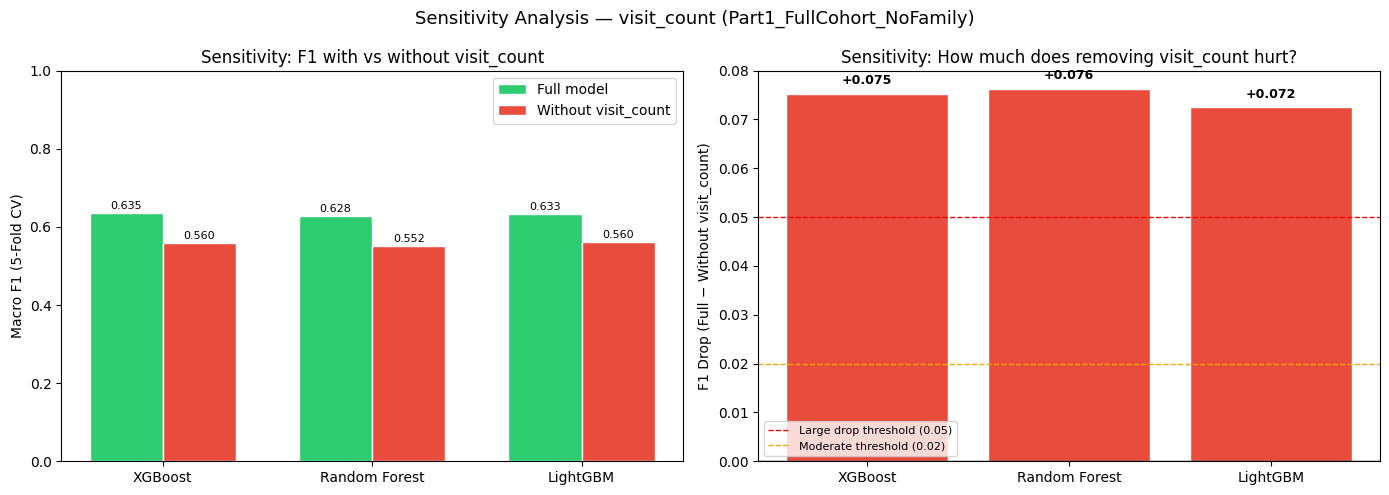


  Running SHAP on visit_count-excluded model...

  SHAP ANALYSIS — Part1_FullCohort_NoFamily_NoVisitCount
  Hold-out  Acc=0.5969  Macro_F1=0.5908
  SHAP: n_features=45, fn=45, n_classes=3


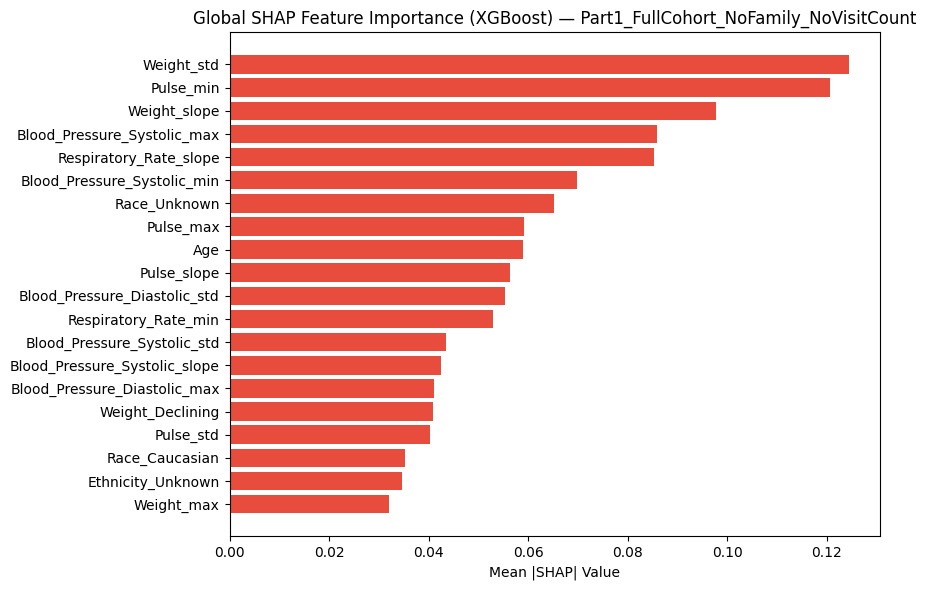

  Global SHAP bar chart saved.


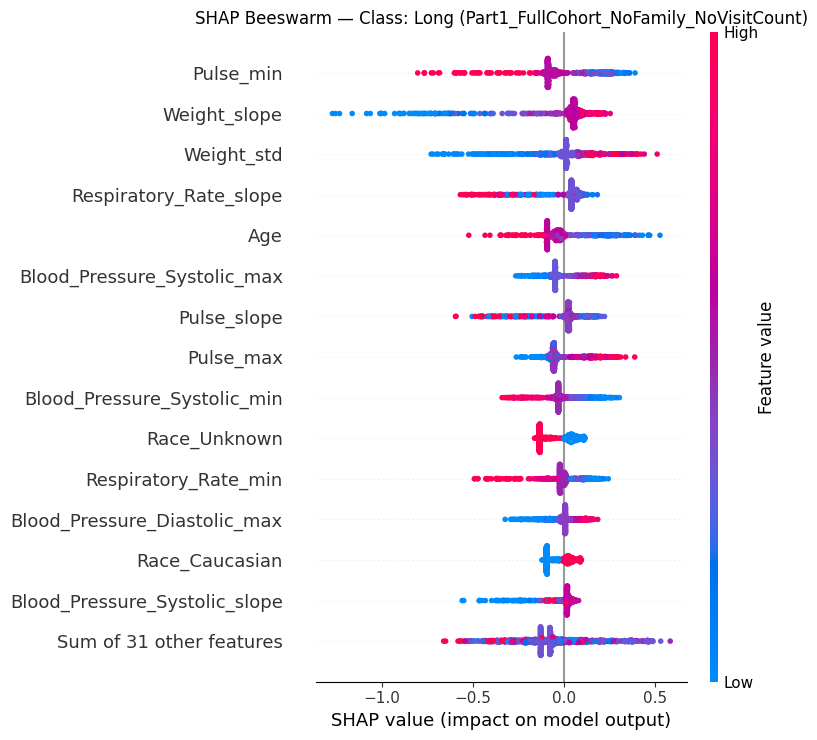

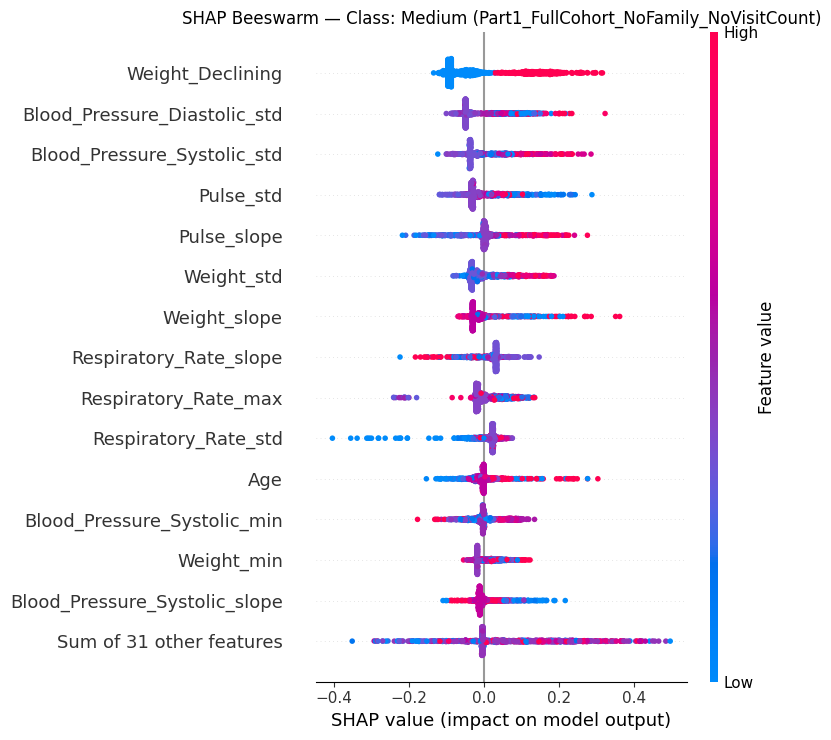

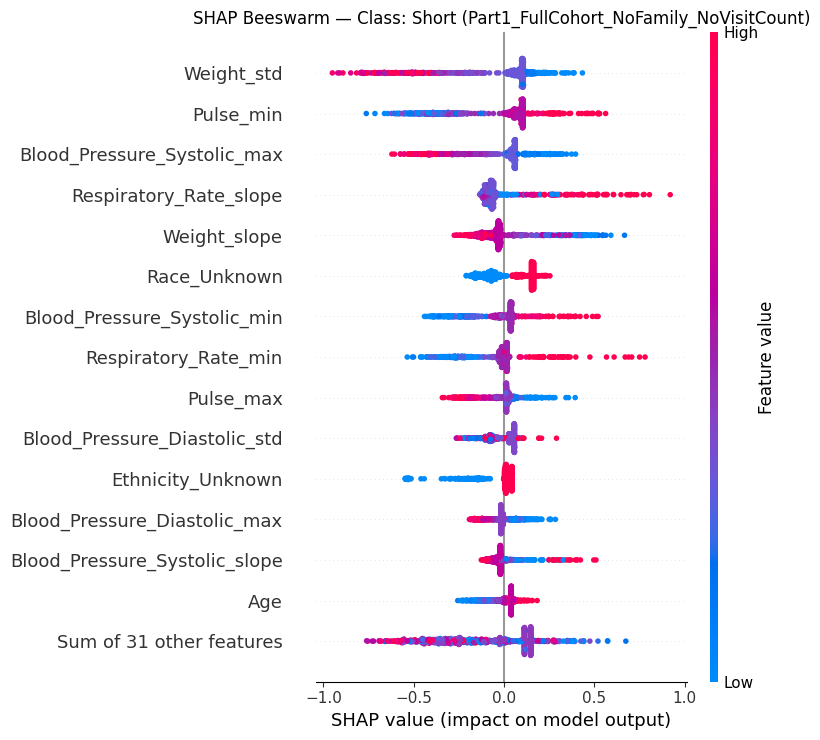

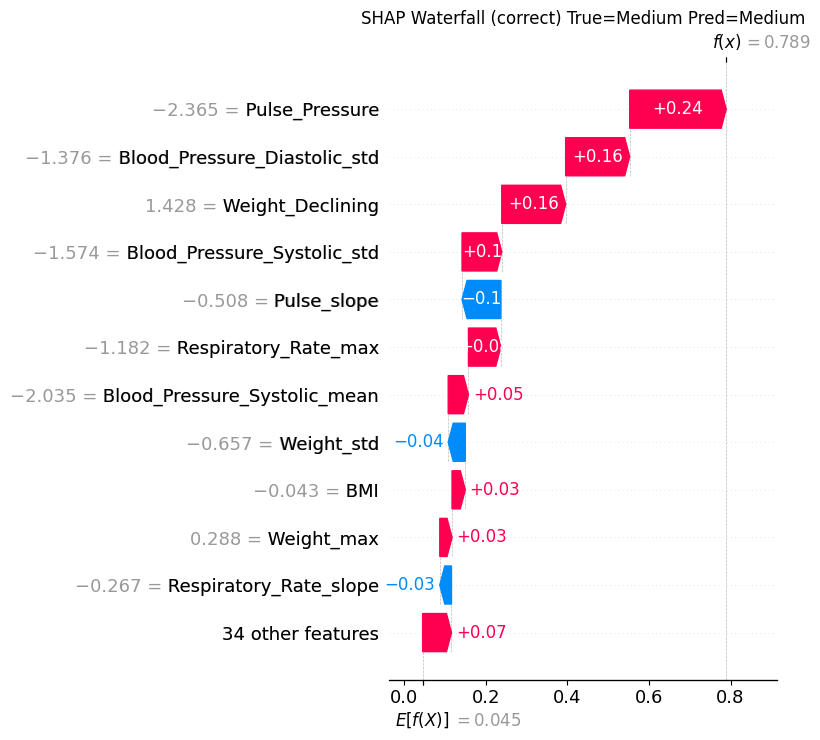

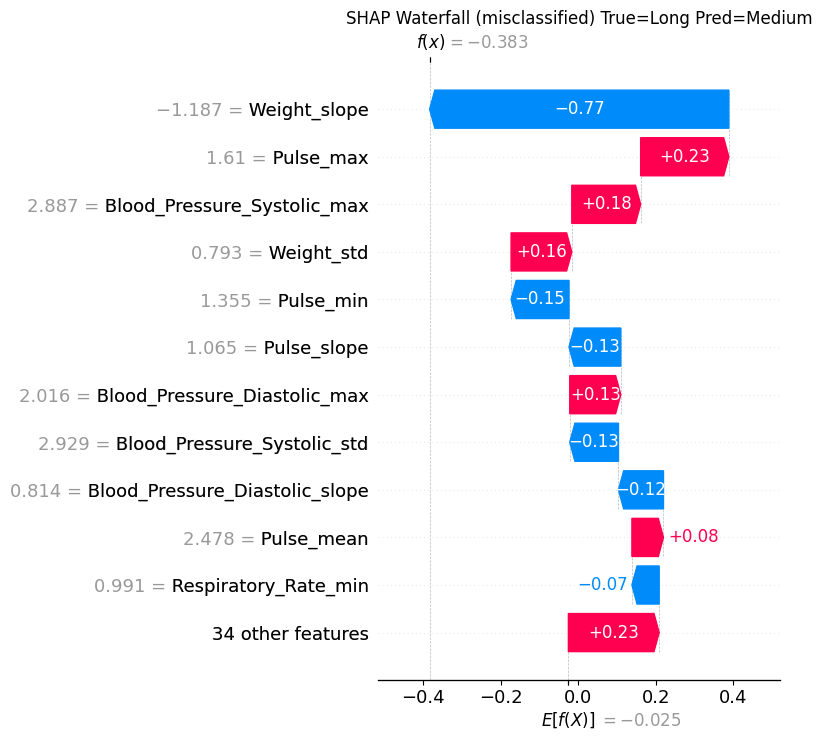

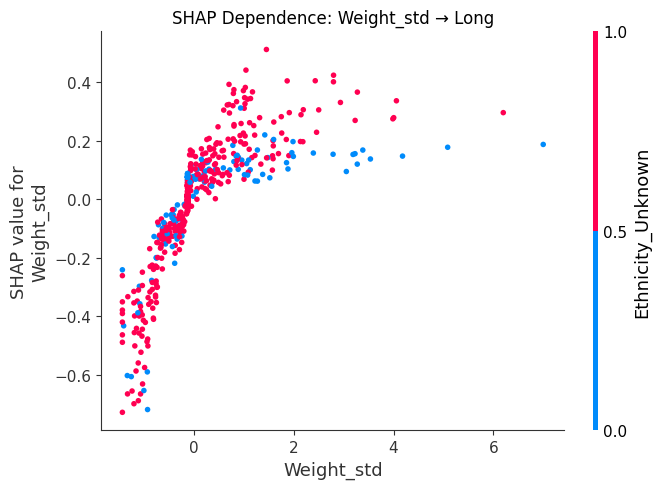

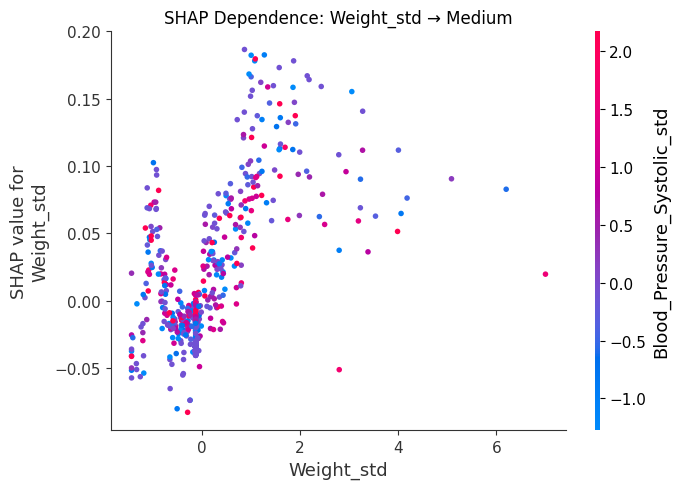

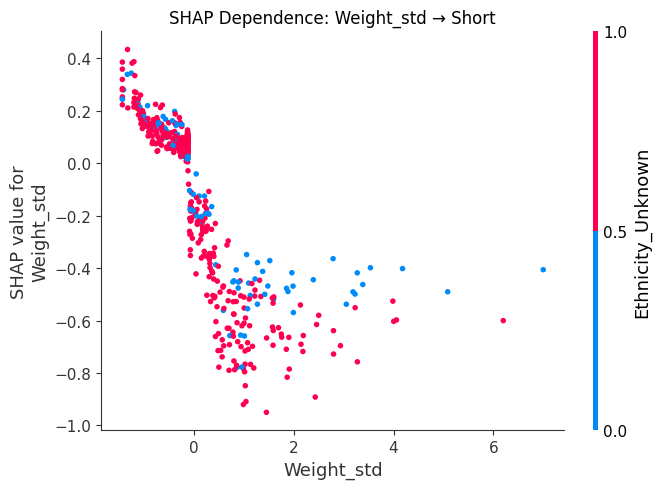

  All SHAP figures saved → /kaggle/working/figures/Part1_FullCohort_NoFamily/sensitivity

  Top 5 features WITHOUT visit_count:
                    Feature  Mean |SHAP|
                 Weight_std     0.124493
                  Pulse_min     0.120627
               Weight_slope     0.097728
Blood_Pressure_Systolic_max     0.085977
     Respiratory_Rate_slope     0.085230

────────────────────────────────────────────────────────────
  SENSITIVITY ANALYSIS CONCLUSION
────────────────────────────────────────────────────────────
  Average F1 drop across models: +0.0746
  → visit_count carries GENUINE predictive signal beyond survivorship.
    The model degrades significantly without it.
    Clinical interpretation: visit frequency reflects disease engagement.
────────────────────────────────────────────────────────────
  Results saved → /kaggle/working/model_reports/Part1_FullCohort_NoFamily/sensitivity


In [45]:
def run_sensitivity_analysis(X_raw, y, le, xgb_params, rf_params, lgbm_params,
                              experiment_name, fig_dir, exp_dir):
    """
    Sensitivity analysis: evaluate whether visit_count is a survivorship
    artifact or genuine predictor by comparing full vs. visit_count-excluded models.

    Tests:
      1. Full model vs visit_count-excluded (XGB, RF, LightGBM)
      2. SHAP re-analysis without visit_count — does feature ranking change?
      3. Calibration comparison: does removing visit_count hurt probability quality?
    """
    print(f"\n{'='*70}")
    print(f"  SENSITIVITY ANALYSIS — visit_count Impact")
    print(f"  Experiment: {experiment_name}")
    print(f"{'='*70}")

    sens_dir = f"{exp_dir}/sensitivity"
    sens_fig = f"{fig_dir}/sensitivity"
    os.makedirs(sens_dir, exist_ok=True)
    os.makedirs(sens_fig, exist_ok=True)

    num_cols = X_raw.select_dtypes(include=["int64","float64"]).columns.tolist()
    cat_cols = X_raw.select_dtypes(include=["object","bool","category"]).columns.tolist()

    # ── Check if visit_count exists ───────────────────────────────────────
    vc_col = None
    for candidate in ["visit_count", "Visit_Count", "num_visits", "visit_num"]:
        if candidate in X_raw.columns:
            vc_col = candidate
            break

    if vc_col is None:
        # visit_count may be embedded as a numeric column — find it by correlation
        # with survival_days from the parent corpus
        print("  NOTE: 'visit_count' not found as a direct column name.")
        print("  Checking numeric columns for a visit-count proxy...")
        # List top candidate columns
        num_df = X_raw.select_dtypes(include=["int64","float64"])
        candidates = [c for c in num_df.columns
                      if any(k in c.lower() for k in ["visit","count","num_"])]
        print(f"  Candidate columns: {candidates}")
        if candidates:
            vc_col = candidates[0]
            print(f"  Using '{vc_col}' as visit_count proxy.")
        else:
            print("  No visit_count column found. Skipping sensitivity analysis.")
            return None

    print(f"\n  Target column for removal: '{vc_col}'")
    print(f"  Full feature set: {X_raw.shape[1]} columns")

    X_no_vc = X_raw.drop(columns=[vc_col])
    print(f"  Reduced feature set: {X_no_vc.shape[1]} columns\n")

    # ── Build folds for both versions ────────────────────────────────────
    folds_full = apply_smote_cv(X_raw,    np.array(y), num_cols, cat_cols, cv_splits=5)
    num_no = X_no_vc.select_dtypes(include=["int64","float64"]).columns.tolist()
    cat_no = X_no_vc.select_dtypes(include=["object","bool","category"]).columns.tolist()
    folds_no_vc = apply_smote_cv(X_no_vc, np.array(y), num_no, cat_no, cv_splits=5)

    models_to_test = {
        "XGBoost":  (
            lambda: XGBClassifier(**xgb_params, objective="multi:softprob",
                                   num_class=3, random_state=42, verbosity=0),
            le
        ),
        "Random Forest": (
            lambda: RandomForestClassifier(**rf_params, class_weight="balanced",
                                            random_state=42, n_jobs=-1),
            None
        ),
        "LightGBM": (
            lambda: lgb.LGBMClassifier(**lgbm_params, objective="multiclass",
                                        num_class=3, random_state=42, verbose=-1),
            le
        ),
    }

    sensitivity_rows = []

    for mname, (factory, enc) in models_to_test.items():
        print(f"  Testing {mname}...")
        res_full  = evaluate_folds(folds_full,  factory, label_encoder=enc)
        res_no_vc = evaluate_folds(folds_no_vc, factory, label_encoder=enc)

        f1_full    = res_full["Macro_F1"][0]
        f1_no_vc   = res_no_vc["Macro_F1"][0]
        auc_full   = res_full["Macro_AUC"][0]
        auc_no_vc  = res_no_vc["Macro_AUC"][0]
        f1_drop    = f1_full - f1_no_vc
        auc_drop   = auc_full - auc_no_vc

        row = {
            "Model":          mname,
            "F1_Full":        round(f1_full,   4),
            "F1_No_VisitCnt": round(f1_no_vc,  4),
            "F1_Drop":        round(f1_drop,   4),
            "AUC_Full":       round(auc_full,  4),
            "AUC_No_VisitCnt":round(auc_no_vc, 4),
            "AUC_Drop":       round(auc_drop,  4),
            "Interpretation": (
                "Large drop → visit_count is genuine predictor" if f1_drop > 0.05
                else "Moderate drop → partial survivorship artifact" if f1_drop > 0.02
                else "Minimal drop → likely survivorship artifact"
            )
        }
        sensitivity_rows.append(row)
        print(f"    F1: {f1_full:.4f} → {f1_no_vc:.4f}  (drop={f1_drop:+.4f})")
        print(f"    AUC: {auc_full:.4f} → {auc_no_vc:.4f}  (drop={auc_drop:+.4f})")
        print(f"    → {row['Interpretation']}\n")

    sens_df = pd.DataFrame(sensitivity_rows)
    sens_df.to_csv(f"{sens_dir}/sensitivity_visit_count.csv", index=False)

    # ── Plot 1: F1 grouped bar — with vs without visit_count ─────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(sens_df)); w = 0.35

    axes[0].bar(x - w/2, sens_df["F1_Full"],        w, label="Full model",
                color="#2ECC71", edgecolor="white")
    axes[0].bar(x + w/2, sens_df["F1_No_VisitCnt"], w, label="Without visit_count",
                color="#E74C3C", edgecolor="white")
    axes[0].set_xticks(x); axes[0].set_xticklabels(sens_df["Model"])
    axes[0].set_ylabel("Macro F1 (5-Fold CV)")
    axes[0].set_title(f"Sensitivity: F1 with vs without visit_count")
    axes[0].legend(); axes[0].set_ylim(0, 1)
    for xi, (vf, vn) in enumerate(zip(sens_df["F1_Full"], sens_df["F1_No_VisitCnt"])):
        axes[0].text(xi - w/2, vf + 0.01, f"{vf:.3f}", ha="center", fontsize=8)
        axes[0].text(xi + w/2, vn + 0.01, f"{vn:.3f}", ha="center", fontsize=8)

    # Plot 2: F1 Drop bar
    drop_colors = ["#E74C3C" if d > 0.05 else "#EF9F27" if d > 0.02 else "#2ECC71"
                   for d in sens_df["F1_Drop"]]
    bars = axes[1].bar(sens_df["Model"], sens_df["F1_Drop"],
                        color=drop_colors, edgecolor="white")
    axes[1].axhline(0, color="black", lw=1)
    axes[1].axhline(0.05, color="red",   linestyle="--", lw=1, label="Large drop threshold (0.05)")
    axes[1].axhline(0.02, color="orange",linestyle="--", lw=1, label="Moderate threshold (0.02)")
    axes[1].set_ylabel("F1 Drop (Full − Without visit_count)")
    axes[1].set_title("Sensitivity: How much does removing visit_count hurt?")
    axes[1].legend(fontsize=8)
    for bar, val in zip(bars, sens_df["F1_Drop"]):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.002, f"{val:+.3f}",
                     ha="center", fontsize=9, fontweight="bold")

    plt.suptitle(f"Sensitivity Analysis — visit_count ({experiment_name})", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{sens_fig}/sensitivity_visit_count.png", dpi=300)
    plt.show()

    # ── SHAP re-analysis without visit_count (XGBoost only) ──────────────
    print("\n  Running SHAP on visit_count-excluded model...")

    # Rebuild feature names for the reduced dataset (visit_count removed)
    num_no_shap = X_no_vc.select_dtypes(include=["int64","float64"]).columns.tolist()
    cat_no_shap = X_no_vc.select_dtypes(include=["object","bool","category"]).columns.tolist()
    prep_no_shap = build_preprocessor(num_no_shap, cat_no_shap)
    prep_no_shap.fit(X_no_vc)
    feat_names_no_vc = get_feature_names(prep_no_shap, num_no_shap, cat_no_shap)

    shap_df_no_vc, _, _, _, _ = run_shap_analysis(
        X_no_vc, y, le, feat_names_no_vc, xgb_params,
        experiment_name + "_NoVisitCount",
        sens_fig, sens_dir
    )

    print(f"\n  Top 5 features WITHOUT visit_count:")
    print(shap_df_no_vc.head(5).to_string(index=False))

    # ── Summary interpretation ────────────────────────────────────────────
    avg_drop = sens_df["F1_Drop"].mean()
    print(f"\n{'─'*60}")
    print(f"  SENSITIVITY ANALYSIS CONCLUSION")
    print(f"{'─'*60}")
    print(f"  Average F1 drop across models: {avg_drop:+.4f}")
    if avg_drop > 0.05:
        print("  → visit_count carries GENUINE predictive signal beyond survivorship.")
        print("    The model degrades significantly without it.")
        print("    Clinical interpretation: visit frequency reflects disease engagement.")
    elif avg_drop > 0.02:
        print("  → visit_count has MIXED signal — partly clinical, partly survivorship.")
        print("    Models still perform meaningfully without it.")
        print("    Recommend reporting both results in the paper.")
    else:
        print("  → visit_count is likely a SURVIVORSHIP ARTIFACT.")
        print("    Models perform similarly without it.")
        print("    The remaining features are the true clinical predictors.")
    print(f"{'─'*60}")
    print(f"  Results saved → {sens_dir}")

    return sens_df


# ── Run sensitivity analysis on Part 1 ───────────────────────────────────────
sens_df_p1 = run_sensitivity_analysis(
    X_full_raw, y_full, le_p1, xgb_p1, rf_p1, lgbm_p1,
    "Part1_FullCohort_NoFamily",
    f"{FIGURE_DIR}/Part1_FullCohort_NoFamily",
    f"{REPORT_DIR}/Part1_FullCohort_NoFamily"
)

## 14B. SENSITIVITY ANALYSIS — Impact of visit_count Removal
visit_count is the dominant SHAP feature (score = 0.475, ~5x the next feature).
This raises a critical question: is it a genuine clinical predictor or a
survivorship artifact (longer-living patients accumulate more visits)?
We systematically test this by re-running the best model with visit_count excluded.

## 15. ERROR ANALYSIS
Systematic investigation of where models fail:
- **Confusion patterns**: which classes are confused most often
- **Feature profile of misclassified samples**: do misclassified patients differ systematically?
- **Confidence calibration**: does model confidence correlate with accuracy?
- **Hard/easy samples**: identify patients consistently misclassified across folds



  ERROR ANALYSIS — Part1_FullCohort_NoFamily


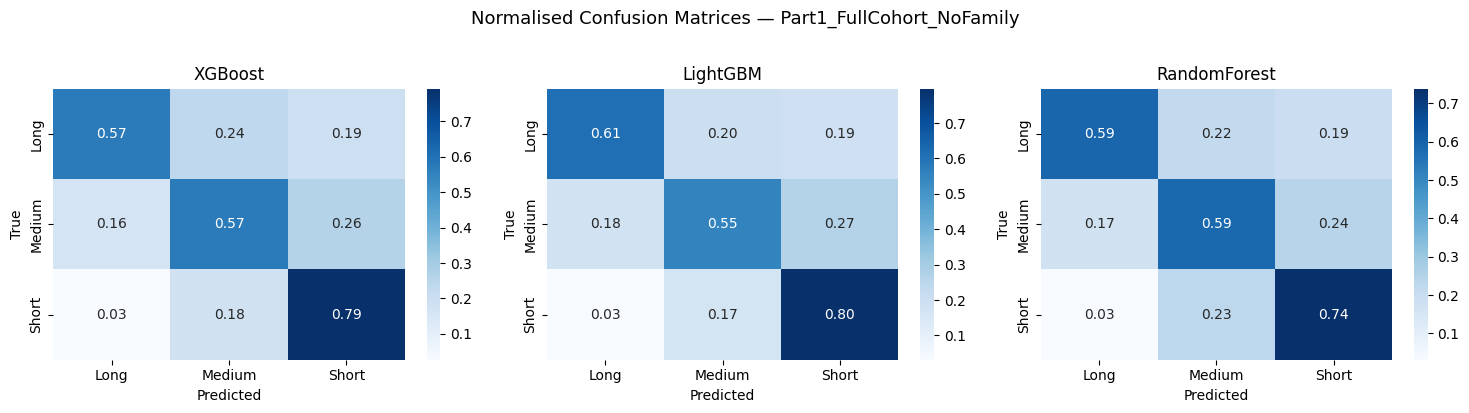

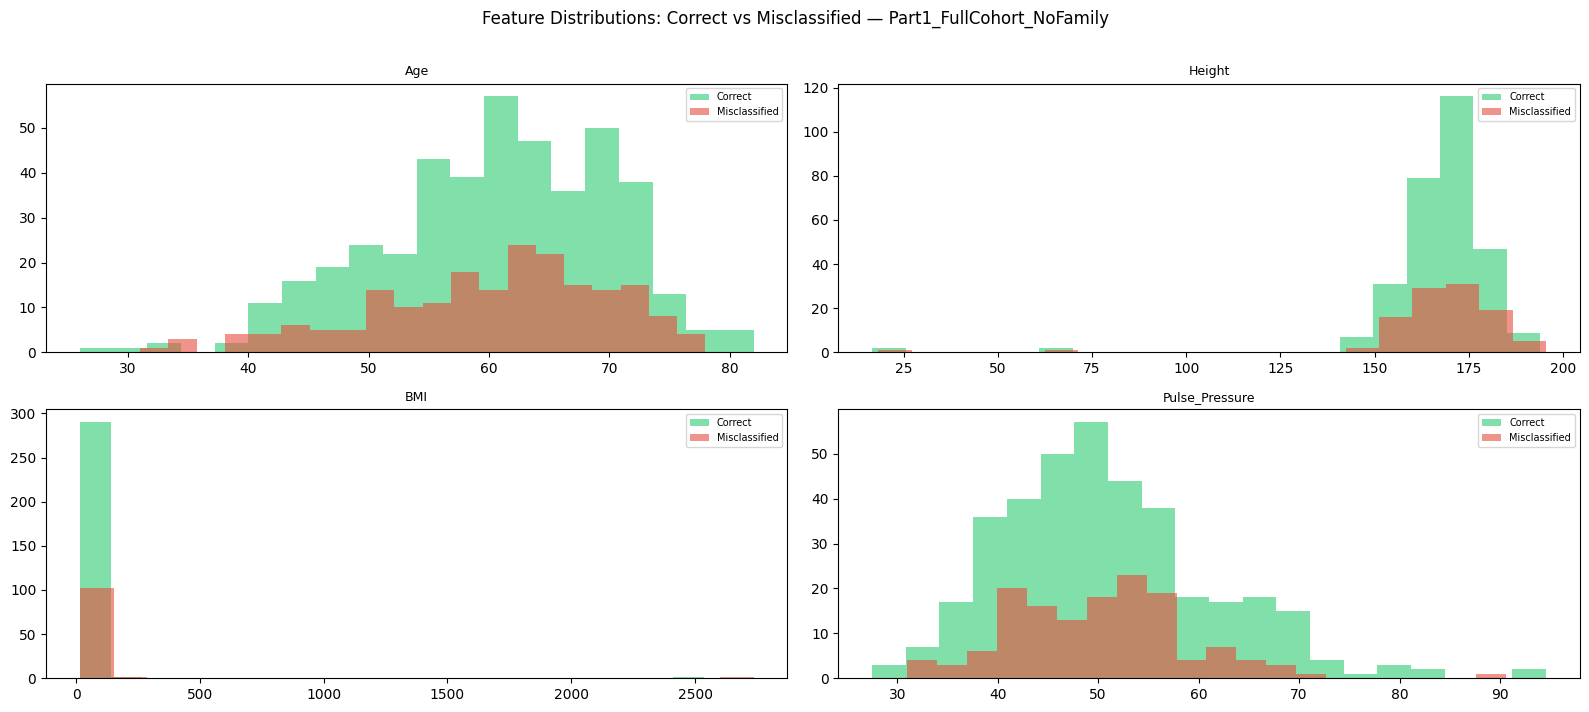

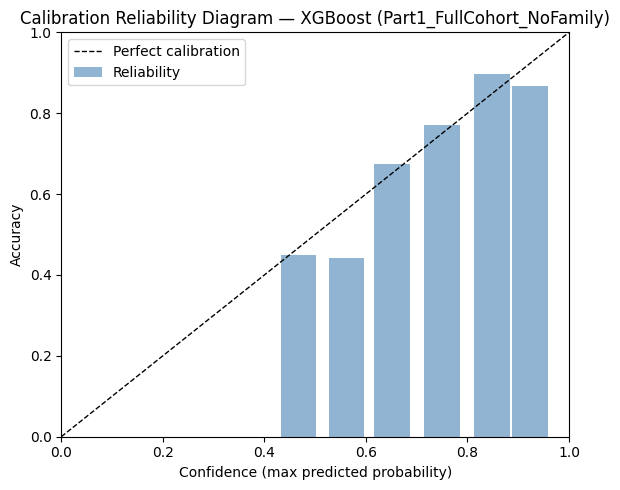


  Misclassification Profile:
True_Class Pred_Class  Count  Mean_Confidence
    Medium      Short    116         0.571473
    Medium       Long     72         0.650274
      Long     Medium     52         0.631439
      Long      Short     42         0.564495
     Short     Medium     40         0.623081
     Short       Long      6         0.483266


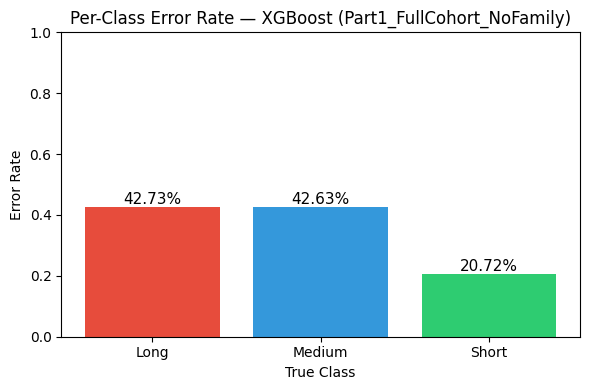

  Error analysis saved → /kaggle/working/figures/Part1_FullCohort_NoFamily


In [46]:
def run_error_analysis(X_raw, y, le, xgb_params, lgbm_params, rf_params,
                       experiment_name, fig_dir, exp_dir):
    """
    Comprehensive error analysis:
      1. Multi-model confusion matrices (normalised)
      2. Feature distributions: correct vs misclassified
      3. Confidence calibration (reliability diagram)
      4. Misclassification profile table
    """
    print(f"\n{'='*70}")
    print(f"  ERROR ANALYSIS — {experiment_name}")
    print(f"{'='*70}")

    num_cols = X_raw.select_dtypes(include=["int64","float64"]).columns.tolist()
    cat_cols = X_raw.select_dtypes(include=["object","bool","category"]).columns.tolist()

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=99)
    tr_idx, te_idx = next(sss.split(X_raw, y))
    prep = build_preprocessor(num_cols, cat_cols)
    Xtr  = prep.fit_transform(X_raw.iloc[tr_idx])
    Xte  = prep.transform(X_raw.iloc[te_idx])
    ytr  = np.array(y)[tr_idx]
    yte  = np.array(y)[te_idx]
    k_nn = min(4, min(Counter(ytr).values()) - 1)
    smote = SMOTE(random_state=42, k_neighbors=k_nn)
    Xtr_r, ytr_r = smote.fit_resample(Xtr, ytr)
    ytr_enc = le.transform(ytr_r)
    yte_enc = le.transform(yte)
    classes_sorted = list(le.classes_)

    # ── Train models ──────────────────────────────────────────────────────
    xgb_m = XGBClassifier(**xgb_params, objective="multi:softprob",
                           num_class=3, random_state=42, verbosity=0)
    xgb_m.fit(Xtr_r, ytr_enc)

    lgbm_m = lgb.LGBMClassifier(**lgbm_params, objective="multiclass",
                                  num_class=3, random_state=42, verbose=-1)
    lgbm_m.fit(Xtr_r, ytr_enc)

    rf_m = RandomForestClassifier(**rf_params, class_weight="balanced",
                                   random_state=42, n_jobs=-1)
    rf_m.fit(Xtr_r, ytr_r)

    # ── 15.1  Normalised confusion matrices side-by-side ─────────────────
    model_preds = {
        "XGBoost":   le.inverse_transform(xgb_m.predict(Xte)),
        "LightGBM":  le.inverse_transform(lgbm_m.predict(Xte)),
        "RandomForest": rf_m.predict(Xte),
    }

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (mname, ypred) in zip(axes, model_preds.items()):
        cm = confusion_matrix(yte, ypred, labels=classes_sorted, normalize="true")
        sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax,
                    xticklabels=classes_sorted, yticklabels=classes_sorted)
        ax.set_title(f"{mname}")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.suptitle(f"Normalised Confusion Matrices — {experiment_name}", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/error_confusion_normalised.png", dpi=300)
    plt.show()

    # ── 15.2  Feature distribution: correct vs misclassified (XGB) ────────
    xgb_pred = model_preds["XGBoost"]
    is_correct = (xgb_pred == yte)

    # Use raw numeric features from the original test set
    Xte_raw_df = X_raw.iloc[te_idx].reset_index(drop=True).copy()
    Xte_raw_df["Correct"]    = is_correct.values if hasattr(is_correct, "values") else is_correct
    Xte_raw_df["True_Class"] = list(yte)
    Xte_raw_df["Pred_Class"] = list(xgb_pred)

    key_num_feats = [c for c in ["Age", "Weight", "Blood_Pressure_Systolic",
                                  "Pulse", "Respiratory_Rate", "Height",
                                  "BMI", "Pulse_Pressure"]
                     if c in Xte_raw_df.columns]

    if key_num_feats:
        fig, axes = plt.subplots(2, max(1, len(key_num_feats)//2 + len(key_num_feats)%2),
                                  figsize=(16, 7))
        axes = axes.flatten()
        for i, feat in enumerate(key_num_feats[:len(axes)]):
            for grp, color, label in [(True, "#2ECC71", "Correct"),
                                       (False, "#E74C3C", "Misclassified")]:
                vals = Xte_raw_df.loc[Xte_raw_df["Correct"]==grp, feat].dropna()
                axes[i].hist(vals, bins=20, alpha=0.6, color=color, label=label)
            axes[i].set_title(feat, fontsize=9)
            axes[i].legend(fontsize=7)
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)
        plt.suptitle(f"Feature Distributions: Correct vs Misclassified — {experiment_name}",
                      fontsize=12, y=1.01)
        plt.tight_layout()
        plt.savefig(f"{fig_dir}/error_feature_distributions.png", dpi=300)
        plt.show()

    # ── 15.3  Confidence calibration (reliability diagram) ────────────────
    xgb_proba = xgb_m.predict_proba(Xte)
    max_conf   = xgb_proba.max(axis=1)   # model confidence for predicted class

    from sklearn.calibration import calibration_curve
    yte_binary = (xgb_pred == yte).astype(int)    # 1=correct, 0=wrong

    fig, ax = plt.subplots(figsize=(6, 5))
    n_bins = 10
    bin_edges = np.linspace(0, 1, n_bins+1)
    bin_acc, bin_conf, bin_count = [], [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (max_conf >= lo) & (max_conf < hi)
        if mask.sum() == 0: continue
        bin_acc.append(yte_binary[mask].mean())
        bin_conf.append(max_conf[mask].mean())
        bin_count.append(mask.sum())
    ax.plot([0,1],[0,1], "k--", lw=1, label="Perfect calibration")
    ax.bar(bin_conf, bin_acc, width=0.07, alpha=0.6, color="steelblue", label="Reliability")
    ax.set_xlabel("Confidence (max predicted probability)")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Calibration Reliability Diagram — XGBoost ({experiment_name})")
    ax.legend(); ax.set_xlim([0,1]); ax.set_ylim([0,1])
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/error_calibration_diagram.png", dpi=300)
    plt.show()

    # ── 15.4  Misclassification profile table ─────────────────────────────
    misc_df = Xte_raw_df[~Xte_raw_df["Correct"]].copy()
    misc_df["Confidence"] = max_conf[~is_correct]
    profile = (misc_df.groupby(["True_Class", "Pred_Class"])
               .agg(Count=("Confidence","count"),
                    Mean_Confidence=("Confidence","mean"))
               .reset_index()
               .sort_values("Count", ascending=False))
    profile.to_csv(f"{exp_dir}/error_misclassification_profile.csv", index=False)
    print("\n  Misclassification Profile:")
    print(profile.to_string(index=False))

    # ── 15.5  Per-class error rate bar chart ──────────────────────────────
    err_rates = {}
    for cls in classes_sorted:
        mask_cls = (yte == cls)
        if mask_cls.sum() == 0: continue
        err_rates[cls] = 1 - accuracy_score(yte[mask_cls], xgb_pred[mask_cls])

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(list(err_rates.keys()), list(err_rates.values()),
           color=["#E74C3C","#3498DB","#2ECC71"])
    ax.set_ylabel("Error Rate"); ax.set_xlabel("True Class")
    ax.set_title(f"Per-Class Error Rate — XGBoost ({experiment_name})")
    ax.set_ylim(0, 1)
    for i, (cls, er) in enumerate(err_rates.items()):
        ax.text(i, er + 0.01, f"{er:.2%}", ha="center", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/error_per_class_rate.png", dpi=300)
    plt.show()

    print(f"  Error analysis saved → {fig_dir}")
    return profile

error_profile_p1 = run_error_analysis(
    X_full_raw, y_full, le_p1, xgb_p1, lgbm_p1, rf_p1,
    "Part1_FullCohort_NoFamily",
    f"{FIGURE_DIR}/Part1_FullCohort_NoFamily",
    f"{REPORT_DIR}/Part1_FullCohort_NoFamily"
)

## 16. COMPREHENSIVE MODEL COMPARISON — ALL MODELS INCL. QUANTUM & TFT


  MASTER MODEL COMPARISON — Part 1 (Full Cohort)
              Model  Macro_F1  F1_Std  Macro_AUC  Accuracy
           LightGBM    0.6336  0.0280     0.8157    0.6361
            XGBoost    0.6289  0.0294     0.8158    0.6332
      Random Forest    0.6245  0.0281     0.8008    0.6276
  Gradient Boosting    0.6233  0.0325     0.8077    0.6273
               FFNN    0.5779  0.0281     0.7836    0.5743
Logistic Regression    0.5751  0.0249     0.7727    0.5695
       TFT (Custom)    0.5681  0.0229     0.7727    0.5633
                SVM    0.5673  0.0184     0.7510    0.5653
             BiLSTM    0.5510  0.0222     0.7517    0.5474
     QSVC [Quantum]    0.4540  0.0236        NaN    0.0000
      VQC [Quantum]    0.2500  0.0168     0.4745    0.0000


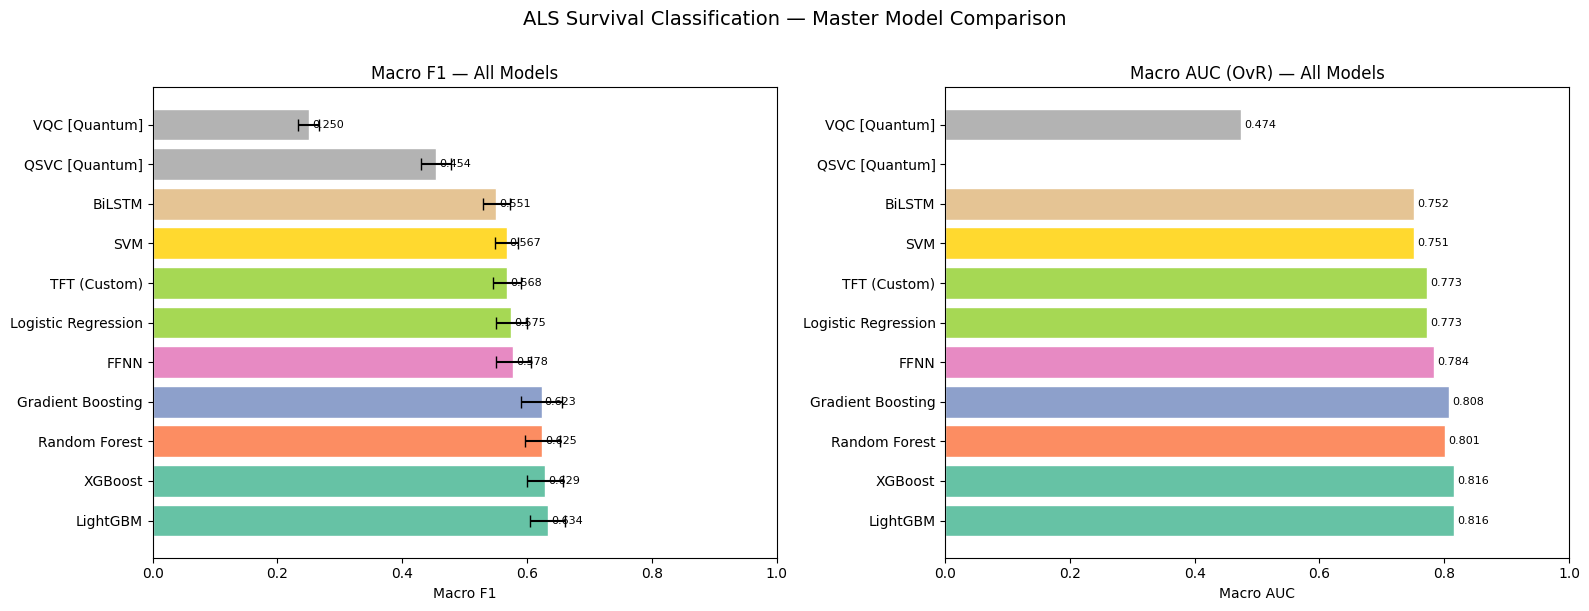

In [47]:
def build_master_comparison(res_dict_p1, quantum_results, tft_result, le, fig_dir):
    """
    Unified comparison table and plot for ALL models across Part 1 (full cohort):
    Classical + Quantum + TFT.
    """
    all_models = {}
    all_models.update(res_dict_p1)
    if quantum_results:
        all_models.update(quantum_results)
    if tft_result and not np.isnan(tft_result["Macro_F1"][0]):
        all_models["TFT (Custom)"] = tft_result

    rows = []
    for mname, metrics in all_models.items():
        if mname.startswith("_"): continue
        rows.append({
            "Model":       mname,
            "Macro_F1":   round(metrics["Macro_F1"][0], 4),
            "F1_Std":     round(metrics["Macro_F1"][1], 4),
            "Macro_AUC":  round(metrics["Macro_AUC"][0], 4)
                          if not np.isnan(metrics["Macro_AUC"][0]) else np.nan,
            "Accuracy":   round(metrics["Accuracy"][0], 4)
                          if "Accuracy" in metrics and not np.isnan(metrics["Accuracy"][0]) else 0.0,
        })

    master_df = pd.DataFrame(rows).sort_values("Macro_F1", ascending=False)
    master_df.to_csv(f"{REPORT_DIR}/MASTER_MODEL_COMPARISON.csv", index=False)

    print("\n" + "="*70)
    print("  MASTER MODEL COMPARISON — Part 1 (Full Cohort)")
    print("="*70)
    print(master_df.to_string(index=False))

    # ── Plot: F1 + AUC side by side ───────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    colors = plt.cm.Set2(np.linspace(0, 1, len(master_df)))

    # F1
    bars = axes[0].barh(master_df["Model"], master_df["Macro_F1"],
                         xerr=master_df["F1_Std"], color=colors,
                         edgecolor="white", capsize=4)
    axes[0].set_xlabel("Macro F1"); axes[0].set_title("Macro F1 — All Models")
    axes[0].set_xlim(0, 1)
    for bar, val in zip(bars, master_df["Macro_F1"]):
        axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                     f"{val:.3f}", va="center", fontsize=8)

    # AUC
    bars2 = axes[1].barh(master_df["Model"], master_df["Macro_AUC"],
                          color=colors, edgecolor="white")
    axes[1].set_xlabel("Macro AUC"); axes[1].set_title("Macro AUC (OvR) — All Models")
    axes[1].set_xlim(0, 1)
    for bar, val in zip(bars2, master_df["Macro_AUC"]):
        axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                     f"{val:.3f}", va="center", fontsize=8)

    plt.suptitle("ALS Survival Classification — Master Model Comparison",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/MASTER_model_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()
    return master_df

master_df = build_master_comparison(
    res1, quantum_results_p1,
    res_tft_p1 if TORCH_AVAILABLE else None,
    le_p1, FIGURE_DIR
)

## 17. FINAL SUMMARY TABLE — ALL THREE EXPERIMENTS

In [48]:
print("\n" + "="*70)
print("  FINAL SUMMARY ACROSS ALL EXPERIMENTS")
print("="*70)

# ── Classical models across 3 experiments ─────────────────────────────────
all_results = {
    "Part1_Full":       res1,
    "Part2A_Baseline":  res2a,
    "Part2B_+Family":   res2b,
}

summary_rows = []
for exp_name, res in all_results.items():
    for model_name, metrics in res.items():
        if model_name.startswith("_"): continue
        summary_rows.append({
            "Experiment":  exp_name,
            "Model":       model_name,
            "Accuracy":    f"{metrics['Accuracy'][0]:.4f} ± {metrics['Accuracy'][1]:.4f}",
            "Macro_F1":    f"{metrics['Macro_F1'][0]:.4f} ± {metrics['Macro_F1'][1]:.4f}",
            "Weighted_F1": f"{metrics['Weighted_F1'][0]:.4f} ± {metrics['Weighted_F1'][1]:.4f}",
            "Macro_AUC":   f"{metrics['Macro_AUC'][0]:.4f} ± {metrics['Macro_AUC'][1]:.4f}",
        })

# ── TFT ───────────────────────────────────────────────────────────────────
if TORCH_AVAILABLE and not np.isnan(res_tft_p1["Macro_F1"][0]):
    summary_rows.append({
        "Experiment":  "Part1_Full",
        "Model":       "TFT (Custom)",
        "Accuracy":    f"{res_tft_p1['Accuracy'][0]:.4f} ± {res_tft_p1['Accuracy'][1]:.4f}",
        "Macro_F1":    f"{res_tft_p1['Macro_F1'][0]:.4f} ± {res_tft_p1['Macro_F1'][1]:.4f}",
        "Weighted_F1": f"{res_tft_p1['Weighted_F1'][0]:.4f} ± {res_tft_p1['Weighted_F1'][1]:.4f}",
        "Macro_AUC":   f"{res_tft_p1['Macro_AUC'][0]:.4f} ± {res_tft_p1['Macro_AUC'][1]:.4f}",
    })

# ── Quantum — Part 1 ──────────────────────────────────────────────────────
for q_model_key, q_res in quantum_results_p1.items():
    if q_model_key.startswith("_"): continue
    summary_rows.append({
        "Experiment":  "Part1_Full (450 balanced samples)",
        "Model":       q_model_key,
        "Accuracy":    "—",
        "Macro_F1":    f"{q_res['Macro_F1'][0]:.4f} ± {q_res['Macro_F1'][1]:.4f}",
        "Weighted_F1": "—",
        "Macro_AUC":   f"{q_res['Macro_AUC'][0]:.4f}" if not np.isnan(q_res['Macro_AUC'][0]) else "—",
    })

# ── Quantum — Family history ───────────────────────────────────────────────
mode_lbl = "Quantum" if QUANTUM_AVAILABLE else "Classical Poly-SVM (Fallback)"
for short_name in ["QSVC", "VQC"]:
    key = f"{short_name} [{mode_lbl}]"
    for exp_lbl, q_res in [("Part2A_Quantum", q_res_fam_2a),
                            ("Part2B_Quantum (+FamilyHist)", q_res_fam_2b)]:
        if key not in q_res: continue
        r = q_res[key]
        summary_rows.append({
            "Experiment":  exp_lbl,
            "Model":       key,
            "Accuracy":    "—",
            "Macro_F1":    f"{r['Macro_F1'][0]:.4f} ± {r['Macro_F1'][1]:.4f}",
            "Weighted_F1": "—",
            "Macro_AUC":   f"{r['Macro_AUC'][0]:.4f}" if not np.isnan(r['Macro_AUC'][0]) else "—",
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(f"{REPORT_DIR}/FINAL_SUMMARY.csv", index=False)
print(summary_df.to_string(index=False))

print(f"\n✓ All results saved to {REPORT_DIR}")
print(f"✓ All figures saved to {FIGURE_DIR}")
print("\nDone.")


  FINAL SUMMARY ACROSS ALL EXPERIMENTS
                       Experiment               Model        Accuracy        Macro_F1     Weighted_F1       Macro_AUC
                       Part1_Full Logistic Regression 0.5695 ± 0.0247 0.5751 ± 0.0249 0.5635 ± 0.0242 0.7727 ± 0.0163
                       Part1_Full       Random Forest 0.6276 ± 0.0281 0.6245 ± 0.0281 0.6288 ± 0.0275 0.8008 ± 0.0139
                       Part1_Full   Gradient Boosting 0.6273 ± 0.0339 0.6233 ± 0.0325 0.6274 ± 0.0336 0.8077 ± 0.0158
                       Part1_Full             XGBoost 0.6332 ± 0.0290 0.6289 ± 0.0294 0.6336 ± 0.0282 0.8158 ± 0.0176
                       Part1_Full            LightGBM 0.6361 ± 0.0292 0.6336 ± 0.0280 0.6364 ± 0.0289 0.8157 ± 0.0170
                       Part1_Full                 SVM 0.5653 ± 0.0191 0.5673 ± 0.0184 0.5627 ± 0.0185 0.7510 ± 0.0150
                       Part1_Full                FFNN 0.5743 ± 0.0286 0.5779 ± 0.0281 0.5635 ± 0.0311 0.7836 ± 0.0168
                


## 18. BIOMARKER ANALYSIS, CORRELATION STUDY & STATISTICAL HYPOTHESIS TESTING


  SECTION 18: BIOMARKER ANALYSIS & STATISTICAL HYPOTHESIS TESTING

  Top 5 Biomarkers (by SHAP + Permutation combined rank):
                     Feature  SHAP_Rank  Perm_Rank  Combined_Score
 Blood_Pressure_Systolic_min          2          3               5
                   Pulse_min          3          2               5
 Blood_Pressure_Systolic_max         10          6              16
Blood_Pressure_Diastolic_std         13          8              21
                  Weight_std          4        999            1003

  Encoded names: ['Blood_Pressure_Systolic_min', 'Pulse_min', 'Blood_Pressure_Systolic_max', 'Blood_Pressure_Diastolic_std', 'Weight_std']

  Raw column names in dataset: ['Blood_Pressure_Systolic_min', 'Pulse_min', 'Blood_Pressure_Systolic_max', 'Blood_Pressure_Diastolic_std', 'Weight_std']

──────────────────────────────────────────────────────────────────────
  STATISTICAL HYPOTHESIS TESTS
──────────────────────────────────────────────────────────────────────

  Hy

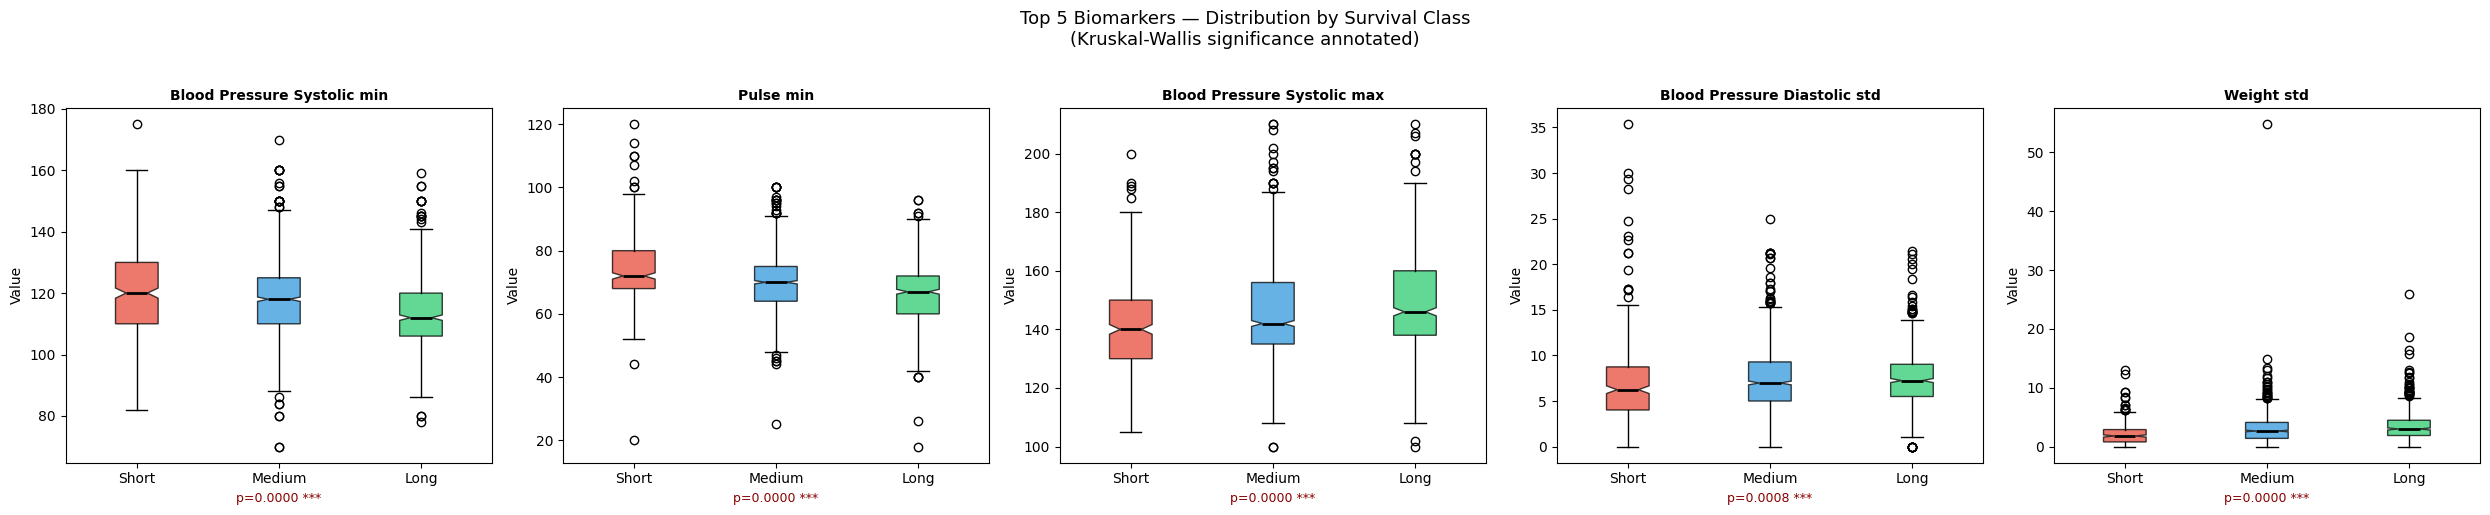

  ✓ Box plots saved (300 DPI)


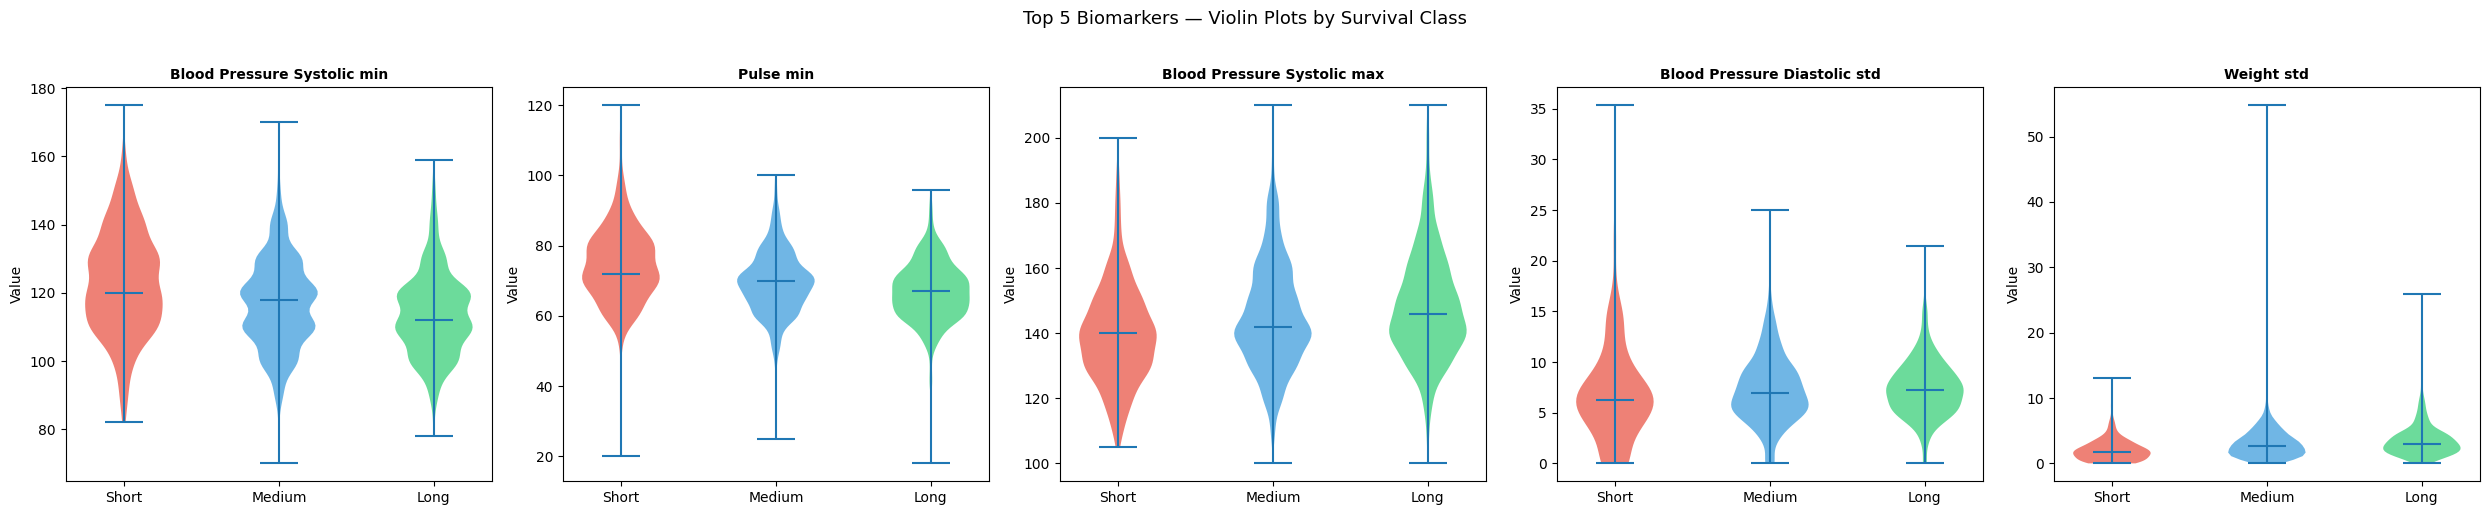

  ✓ Violin plots saved (300 DPI)


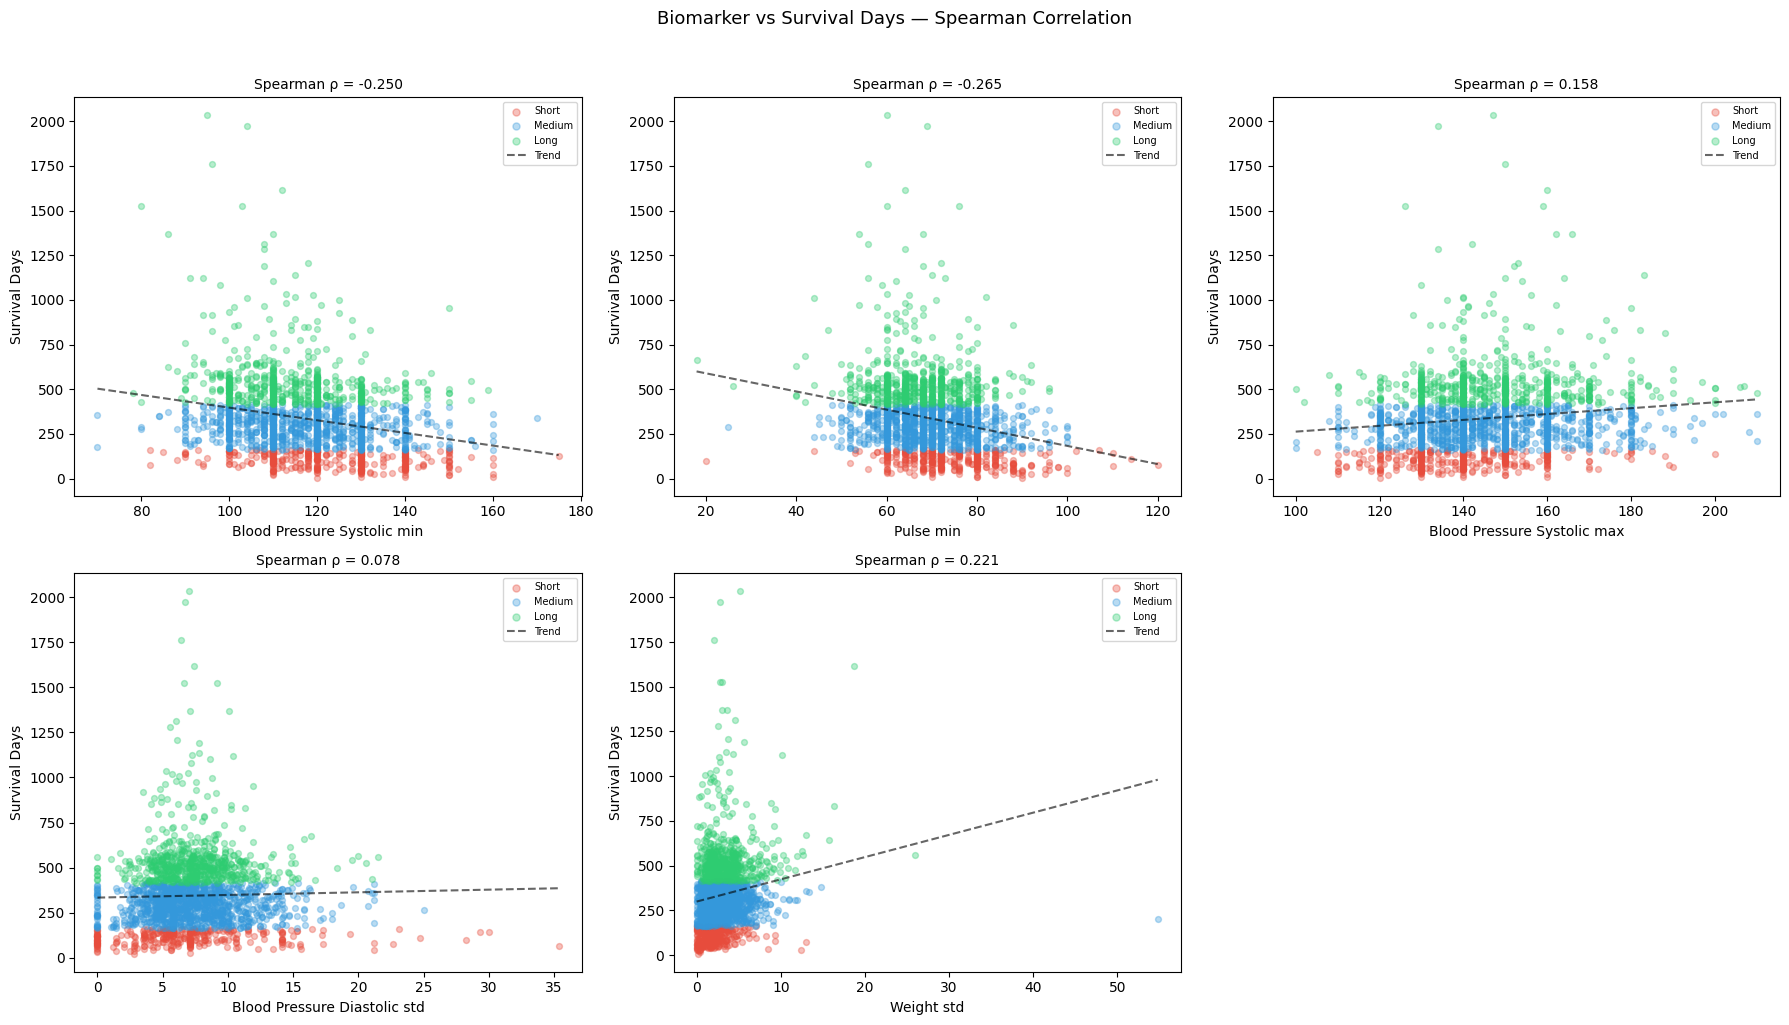

  ✓ Scatter plots saved (300 DPI)


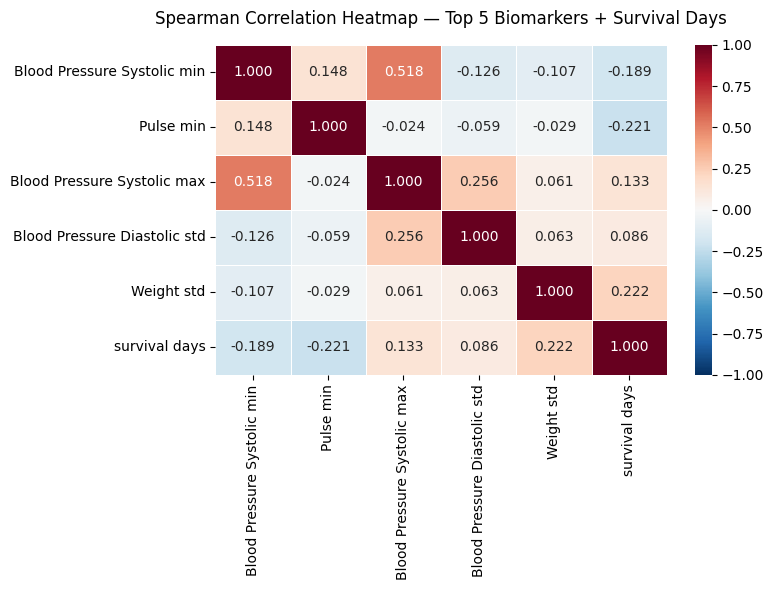

  ✓ Correlation heatmap saved (300 DPI)


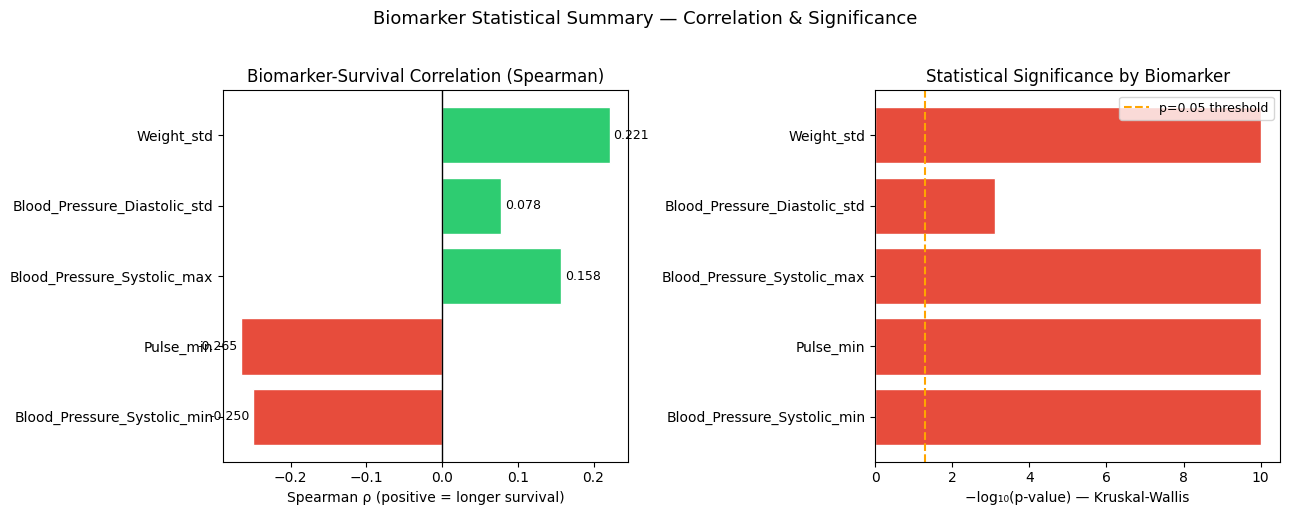

  ✓ Statistical summary plot saved (300 DPI)

  BIOMARKER REPORT — TOP 5 ALS SURVIVAL BIOMARKERS

  Biomarker 1: Blood_Pressure_Systolic_min
    Kruskal-Wallis p = 0.00000  ✓ SIGNIFICANT
    Spearman ρ       = -0.2497  ↓ lower in Long
    Effect size η²   = 0.0461
    Short vs Long    = p=0.0
    SHAP importance  = 0.0824
    Perm. importance = 0.0243

  Biomarker 2: Pulse_min
    Kruskal-Wallis p = 0.00000  ✓ SIGNIFICANT
    Spearman ρ       = -0.2651  ↓ lower in Long
    Effect size η²   = 0.0650
    Short vs Long    = p=0.0
    SHAP importance  = 0.0722
    Perm. importance = 0.0321

  Biomarker 3: Blood_Pressure_Systolic_max
    Kruskal-Wallis p = 0.00000  ✓ SIGNIFICANT
    Spearman ρ       = 0.1577  ↑ higher in Long
    Effect size η²   = 0.0276
    Short vs Long    = p=0.0
    SHAP importance  = 0.0438
    Perm. importance = 0.0040

  Biomarker 4: Blood_Pressure_Diastolic_std
    Kruskal-Wallis p = 0.00078  ✓ SIGNIFICANT
    Spearman ρ       = 0.0782  ↑ higher in Long
    Effect 

In [49]:
from scipy.stats import kruskal, spearmanr, mannwhitneyu, chi2_contingency
from scipy.stats import pointbiserialr
import warnings
warnings.filterwarnings("ignore")

print("="*70)
print("  SECTION 18: BIOMARKER ANALYSIS & STATISTICAL HYPOTHESIS TESTING")
print("="*70)

BIOMARKER_DIR = f"{FIGURE_DIR}/biomarker_analysis"
BIOMARKER_REP = f"{REPORT_DIR}/biomarker_analysis"
os.makedirs(BIOMARKER_DIR, exist_ok=True)
os.makedirs(BIOMARKER_REP, exist_ok=True)

# ── Step 1: Identify top 5 biomarkers from SHAP + Permutation ────────────
# Using results already computed — cross-validate both methods
# SHAP top features (from shap_df_p1) × Permutation top features (from perm_df_p1)

shap_top = shap_df_p1["Feature"].head(15).tolist()
perm_top = perm_df_p1["Feature"].head(15).tolist()

# Vitals-only candidates (exclude visit_count — it's structural, not a biomarker)
# and exclude one-hot encoded categorical dummies
vital_keywords = [
    "Blood_Pressure_Systolic", "Blood_Pressure_Diastolic",
    "Weight", "Pulse", "Respiratory_Rate", "Height", "BMI", "Pulse_Pressure"
]

def is_vital_biomarker(feat_name):
    return (any(kw.lower() in feat_name.lower() for kw in vital_keywords)
            and feat_name != "visit_count"
            and "_Unknown" not in feat_name
            and "_Female" not in feat_name
            and "_observed" not in feat_name)

# Score = SHAP rank + Permutation rank (lower = better)
all_candidates = list(set(shap_top + perm_top))
scored = []
for feat in all_candidates:
    if not is_vital_biomarker(feat):
        continue
    shap_rank = shap_top.index(feat) + 1 if feat in shap_top else 999
    perm_rank = perm_top.index(feat) + 1 if feat in perm_top else 999
    scored.append({"Feature": feat, "SHAP_Rank": shap_rank,
                   "Perm_Rank": perm_rank, "Combined_Score": shap_rank + perm_rank})

biomarker_rank_df = (pd.DataFrame(scored)
                     .sort_values("Combined_Score")
                     .reset_index(drop=True))

# Select top 5
TOP_BIOMARKERS_ENCODED = biomarker_rank_df["Feature"].head(5).tolist()
print(f"\n  Top 5 Biomarkers (by SHAP + Permutation combined rank):")
print(biomarker_rank_df.head(5).to_string(index=False))

# Map encoded feature names back to raw column names
def encoded_to_raw(enc_name):
    """Strip aggregation suffixes to get the raw column name."""
    for suffix in ["_mean","_min","_max","_std","_slope","_count"]:
        if enc_name.endswith(suffix):
            return enc_name
    return enc_name

TOP_BIOMARKERS_ENCODED = biomarker_rank_df["Feature"].head(5).tolist()
print(f"\n  Encoded names: {TOP_BIOMARKERS_ENCODED}")

# ── Step 2: Map to columns present in model_df ────────────────────────────
# model_df has the original (pre-OHE) columns
available_raw = []
for feat in TOP_BIOMARKERS_ENCODED:
    if feat in model_df.columns:
        available_raw.append(feat)
    else:
        # Try partial match
        matches = [c for c in model_df.columns
                   if feat.lower() in c.lower() or c.lower() in feat.lower()]
        if matches:
            available_raw.append(matches[0])

# Deduplicate while preserving order
seen = set()
TOP_5_RAW = []
for col in available_raw:
    if col not in seen:
        seen.add(col)
        TOP_5_RAW.append(col)
TOP_5_RAW = TOP_5_RAW[:5]

print(f"\n  Raw column names in dataset: {TOP_5_RAW}")

# ── Step 3: Statistical Hypothesis Tests ─────────────────────────────────
print("\n" + "─"*70)
print("  STATISTICAL HYPOTHESIS TESTS")
print("─"*70)
print("\n  Hypotheses:")
print("  H0: The biomarker distribution does not differ across survival classes")
print("  H1: The biomarker distribution significantly differs across classes")
print("  Test: Kruskal-Wallis (non-parametric, α=0.05)\n")

analysis_df = model_df[TOP_5_RAW + ["survival_class", "survival_days"]].copy()
classes = ["Short", "Medium", "Long"]

stat_rows = []
for col in TOP_5_RAW:
    groups = [analysis_df.loc[analysis_df["survival_class"]==cls, col].dropna().values
              for cls in classes]
    groups = [g for g in groups if len(g) > 0]

    if len(groups) < 2:
        continue

    # Kruskal-Wallis
    stat_kw, p_kw = kruskal(*groups)

    # Spearman correlation with survival_days
    valid = analysis_df[[col, "survival_days"]].dropna()
    rho, p_sp = spearmanr(valid[col], valid["survival_days"])

    # Effect size (eta-squared approximation)
    n_total = sum(len(g) for g in groups)
    eta_sq = (stat_kw - len(groups) + 1) / (n_total - len(groups))
    eta_sq = max(0, eta_sq)

    # Pairwise Mann-Whitney between Short and Long (most clinically relevant)
    g_short = analysis_df.loc[analysis_df["survival_class"]=="Short", col].dropna()
    g_long  = analysis_df.loc[analysis_df["survival_class"]=="Long",  col].dropna()
    if len(g_short) > 0 and len(g_long) > 0:
        mw_stat, mw_p = mannwhitneyu(g_short, g_long, alternative="two-sided")
    else:
        mw_p = np.nan

    sig = "✓ SIGNIFICANT" if p_kw < 0.05 else "✗ not significant"
    direction = "↑ higher in Long" if rho > 0 else "↓ lower in Long"

    stat_rows.append({
        "Biomarker":          col,
        "KW_statistic":       round(stat_kw, 3),
        "KW_p_value":         round(p_kw, 5),
        "Significant":        sig,
        "Spearman_rho":       round(rho, 4),
        "Spearman_p":         round(p_sp, 5),
        "Direction":          direction,
        "Eta_squared":        round(eta_sq, 4),
        "ShortVsLong_MW_p":   round(mw_p, 5) if not np.isnan(mw_p) else "—",
    })

    print(f"  {col}")
    print(f"    Kruskal-Wallis: H={stat_kw:.3f}, p={p_kw:.5f}  {sig}")
    print(f"    Spearman ρ with survival_days: {rho:.4f} (p={p_sp:.5f})  {direction}")
    print(f"    Effect size η²: {eta_sq:.4f}")
    print(f"    Short vs Long (Mann-Whitney): p={mw_p:.5f}")
    print()

stat_df = pd.DataFrame(stat_rows)
stat_df.to_csv(f"{BIOMARKER_REP}/statistical_tests.csv", index=False)
print("\n  Statistical test results saved.")

# ── Step 4: Hypothesis summary matching experimental findings ─────────────
print("\n" + "─"*70)
print("  HYPOTHESIS vs EXPERIMENTAL OBSERVATION ALIGNMENT")
print("─"*70)
for _, row in stat_df.iterrows():
    in_shap_top5 = row["Biomarker"] in TOP_5_RAW
    stat_sig = row["KW_p_value"] < 0.05
    match = "✓ ALIGNED" if stat_sig else "⚠ MISMATCH"
    print(f"  {row['Biomarker'][:45]:<45} | Stat: {'SIG' if stat_sig else 'n.s.':3} | "
          f"SHAP top-5: {'Yes' if in_shap_top5 else 'No':3} | {match}")

# ── Step 5: Biomarker visualisation ──────────────────────────────────────
print("\n  Generating biomarker visualisations...")

PALETTE = {"Short": "#E74C3C", "Medium": "#3498DB", "Long": "#2ECC71"}
ORDER    = ["Short", "Medium", "Long"]

# ── 5A: Box plots per class for each biomarker ────────────────────────────
fig, axes = plt.subplots(1, len(TOP_5_RAW), figsize=(5*len(TOP_5_RAW), 5))
if len(TOP_5_RAW) == 1:
    axes = [axes]
for ax, col in zip(axes, TOP_5_RAW):
    data_by_class = [analysis_df.loc[analysis_df["survival_class"]==cls, col].dropna()
                     for cls in ORDER]
    bp = ax.boxplot(data_by_class, patch_artist=True, notch=True,
                    medianprops=dict(color="black", lw=2))
    for patch, cls in zip(bp["boxes"], ORDER):
        patch.set_facecolor(PALETTE[cls])
        patch.set_alpha(0.75)
    ax.set_xticklabels(ORDER, fontsize=10)
    ax.set_title(col.replace("_"," "), fontsize=10, fontweight="bold")
    ax.set_ylabel("Value")
    # Add significance annotation
    row_data = stat_df[stat_df["Biomarker"]==col]
    if not row_data.empty:
        p_val = row_data["KW_p_value"].values[0]
        stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
        ax.set_xlabel(f"p={p_val:.4f} {stars}", fontsize=9, color="darkred")

plt.suptitle("Top 5 Biomarkers — Distribution by Survival Class\n(Kruskal-Wallis significance annotated)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{BIOMARKER_DIR}/biomarker_boxplots.png", dpi=300, format="PNG",
            bbox_inches="tight")
plt.show()
print("  ✓ Box plots saved (300 DPI)")

# ── 5B: Violin plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(TOP_5_RAW), figsize=(5*len(TOP_5_RAW), 5))
if len(TOP_5_RAW) == 1:
    axes = [axes]
for ax, col in zip(axes, TOP_5_RAW):
    data_by_class = [analysis_df.loc[analysis_df["survival_class"]==cls, col].dropna().values
                     for cls in ORDER]
    parts = ax.violinplot(data_by_class, positions=range(len(ORDER)),
                          showmedians=True, showmeans=False)
    for i, (pc, cls) in enumerate(zip(parts["bodies"], ORDER)):
        pc.set_facecolor(PALETTE[cls])
        pc.set_alpha(0.7)
    ax.set_xticks(range(len(ORDER)))
    ax.set_xticklabels(ORDER, fontsize=10)
    ax.set_title(col.replace("_"," "), fontsize=10, fontweight="bold")
    ax.set_ylabel("Value")

plt.suptitle("Top 5 Biomarkers — Violin Plots by Survival Class",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{BIOMARKER_DIR}/biomarker_violins.png", dpi=300, format="PNG",
            bbox_inches="tight")
plt.show()
print("  ✓ Violin plots saved (300 DPI)")

# ── 5C: Scatter plot — each biomarker vs survival_days (coloured by class) ─
n_cols = min(3, len(TOP_5_RAW))
n_rows = (len(TOP_5_RAW) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = np.array(axes).flatten()

for i, col in enumerate(TOP_5_RAW):
    ax = axes[i]
    for cls in ORDER:
        mask = analysis_df["survival_class"] == cls
        ax.scatter(analysis_df.loc[mask, col],
                   analysis_df.loc[mask, "survival_days"],
                   color=PALETTE[cls], alpha=0.35, s=18, label=cls)
    # Trend line
    valid = analysis_df[[col, "survival_days"]].dropna()
    if len(valid) > 10:
        z = np.polyfit(valid[col], valid["survival_days"], 1)
        p_line = np.poly1d(z)
        x_range = np.linspace(valid[col].min(), valid[col].max(), 100)
        ax.plot(x_range, p_line(x_range), "k--", lw=1.5, alpha=0.6, label="Trend")
    row_data = stat_df[stat_df["Biomarker"]==col]
    rho_val = row_data["Spearman_rho"].values[0] if not row_data.empty else 0
    ax.set_xlabel(col.replace("_"," "), fontsize=10)
    ax.set_ylabel("Survival Days")
    ax.set_title(f"Spearman ρ = {rho_val:.3f}", fontsize=10)
    ax.legend(fontsize=7, markerscale=1.2)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Biomarker vs Survival Days — Spearman Correlation",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{BIOMARKER_DIR}/biomarker_scatter_survival.png", dpi=300, format="PNG",
            bbox_inches="tight")
plt.show()
print("  ✓ Scatter plots saved (300 DPI)")

# ── 5D: Correlation heatmap (Spearman) among biomarkers + survival_days ───
cols_for_heatmap = TOP_5_RAW + ["survival_days"]
corr_data = analysis_df[cols_for_heatmap].dropna()
spearman_matrix = corr_data.corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(spearman_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True   # show full matrix for biomarkers
import seaborn as sns
sns.heatmap(spearman_matrix, annot=True, fmt=".3f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=[c.replace("_"," ") for c in cols_for_heatmap],
            yticklabels=[c.replace("_"," ") for c in cols_for_heatmap],
            linewidths=0.5)
ax.set_title("Spearman Correlation Heatmap — Top 5 Biomarkers + Survival Days",
             fontsize=12, pad=15)
plt.tight_layout()
plt.savefig(f"{BIOMARKER_DIR}/biomarker_correlation_heatmap.png", dpi=300, format="PNG",
            bbox_inches="tight")
plt.show()
print("  ✓ Correlation heatmap saved (300 DPI)")

# ── 5E: Summary bar — Spearman rho and significance ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Spearman rho
rho_vals = stat_df["Spearman_rho"].values
bar_colors = ["#2ECC71" if r > 0 else "#E74C3C" for r in rho_vals]
bars = axes[0].barh(stat_df["Biomarker"], rho_vals, color=bar_colors, edgecolor="white")
axes[0].axvline(0, color="black", lw=1)
axes[0].set_xlabel("Spearman ρ (positive = longer survival)")
axes[0].set_title("Biomarker-Survival Correlation (Spearman)")
for bar, val in zip(bars, rho_vals):
    axes[0].text(val + (0.005 if val >= 0 else -0.005),
                 bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center",
                 ha="left" if val >= 0 else "right", fontsize=9)

# Right: KW p-value (−log10 scale for readability)
log_p = [-np.log10(max(p, 1e-10)) for p in stat_df["KW_p_value"].values]
sig_colors = ["#E74C3C" if p < 0.05 else "#95A5A6" for p in stat_df["KW_p_value"].values]
axes[1].barh(stat_df["Biomarker"], log_p, color=sig_colors, edgecolor="white")
axes[1].axvline(-np.log10(0.05), color="orange", linestyle="--", lw=1.5,
               label="p=0.05 threshold")
axes[1].set_xlabel("−log₁₀(p-value) — Kruskal-Wallis")
axes[1].set_title("Statistical Significance by Biomarker")
axes[1].legend(fontsize=9)

plt.suptitle("Biomarker Statistical Summary — Correlation & Significance",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{BIOMARKER_DIR}/biomarker_statistical_summary.png", dpi=300, format="PNG",
            bbox_inches="tight")
plt.show()
print("  ✓ Statistical summary plot saved (300 DPI)")

# ── Step 6: Print final biomarker report ─────────────────────────────────
print("\n" + "="*70)
print("  BIOMARKER REPORT — TOP 5 ALS SURVIVAL BIOMARKERS")
print("="*70)
for i, row in stat_df.iterrows():
    print(f"\n  Biomarker {i+1}: {row['Biomarker']}")
    print(f"    Kruskal-Wallis p = {row['KW_p_value']:.5f}  {row['Significant']}")
    print(f"    Spearman ρ       = {row['Spearman_rho']:.4f}  {row['Direction']}")
    print(f"    Effect size η²   = {row['Eta_squared']:.4f}")
    print(f"    Short vs Long    = p={row['ShortVsLong_MW_p']}")
    shap_row = shap_df_p1[shap_df_p1["Feature"] == row["Biomarker"]]
    if not shap_row.empty:
        print(f"    SHAP importance  = {shap_row['Mean |SHAP|'].values[0]:.4f}")
    perm_row = perm_df_p1[perm_df_p1["Feature"] == row["Biomarker"]]
    if not perm_row.empty:
        print(f"    Perm. importance = {perm_row['Importance'].values[0]:.4f}")

stat_df.to_csv(f"{BIOMARKER_REP}/biomarker_report.csv", index=False)
biomarker_rank_df.to_csv(f"{BIOMARKER_REP}/biomarker_ranking.csv", index=False)
print(f"\n  ✓ Reports saved → {BIOMARKER_REP}")


## 19. ZIP ALL FIGURES FOR DOWNLOAD

In [50]:
import zipfile
import glob
import os

print("  SECTION 19: PACKAGING COMPLETE OUTPUT FOR DOWNLOAD")

ZIP_PATH = "/kaggle/working/ALS_Complete_Output.zip"

# Collect everything from /kaggle/working/ EXCEPT the zip itself
all_files = []
for root, dirs, files in os.walk("/kaggle/working"):
    # Skip the zip file itself if it already exists from a previous run
    dirs[:] = [d for d in dirs if d != "__pycache__"]
    for fname in files:
        fpath = os.path.join(root, fname)
        if fpath == ZIP_PATH:
            continue
        if fname.endswith(".ipynb"):
            continue   # skip notebook file — too large and not needed
        all_files.append(fpath)

print(f"\n  Files to be zipped: {len(all_files)}")

# Show breakdown by type
csv_files = [f for f in all_files if f.endswith(".csv")]
png_files = [f for f in all_files if f.endswith(".png")]
txt_files = [f for f in all_files if f.endswith(".txt")]
print(f"  ├── PNG figures  : {len(png_files)}")
print(f"  ├── CSV reports  : {len(csv_files)}")
print(f"  ├── TXT reports  : {len(txt_files)}")
print(f"  └── Other files  : {len(all_files) - len(png_files) - len(csv_files) - len(txt_files)}")

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for fpath in sorted(all_files):
        # Store relative path inside zip (strip /kaggle/working/)
        arcname = fpath.replace("/kaggle/working/", "")
        zf.write(fpath, arcname)

zip_size_mb = os.path.getsize(ZIP_PATH) / (1024 * 1024)
print(f"\n  ✓ ZIP created : {ZIP_PATH}")
print(f"  ✓ ZIP size    : {zip_size_mb:.2f} MB")
print(f"  ✓ Total files : {len(all_files)}")

  SECTION 19: PACKAGING COMPLETE OUTPUT FOR DOWNLOAD

  Files to be zipped: 109
  ├── PNG figures  : 65
  ├── CSV reports  : 23
  ├── TXT reports  : 21
  └── Other files  : 0

  ✓ ZIP created : /kaggle/working/ALS_Complete_Output.zip
  ✓ ZIP size    : 12.20 MB
  ✓ Total files : 109
